# Phase 3: Fuzzy Systems — `FS_Model.ipynb`**Team 1 — NYC Taxi Trip Duration**

---

## 🧠 Words We Use in This Notebook (Glossary)

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
📘 <b>Before reading the code, here are the main terms used in this phase.</b>
</div>

---

### 📖 Key Concepts

<div style="background-color:#f5f5f5; padding:10px; border-radius:8px;">

| 🔑 Term | 💡 Meaning |
|--------|-----------|
| **Fuzzy Set** | A group where values are not just yes (1) or no (0), but can be partially in between. For example, a 12 km trip could be 0.7 "medium" and 0.3 "long." |
| **Membership Function (MF)** | A curve that shows how much a value belongs to a fuzzy set (from 0 to 1). Common shapes include triangular, trapezoidal, and smooth curves. |
| **Linguistic Variable** | A variable described using words instead of numbers, like saying a trip is "short," "medium," or "long." |
| **Fuzzy Rule** | An IF–THEN statement using words. Example: IF distance is long AND hour is busy THEN duration is very long. |
| **Fuzzy Inference System (FIS)** | The full system: convert inputs into fuzzy values → apply rules → convert the result back into one final prediction. |
| **Defuzzification** | The step where fuzzy results are turned back into a single number (the final prediction). |
| **scikit-fuzzy** | A Python library (`skfuzzy`) used to build fuzzy systems. |
| **Interpretability** | How easy it is for a person to understand why the model made a prediction. |
| **H3** | The main question for this phase: Can the fuzzy system stay easy to understand while still making good predictions compared to NN and EA models? |

</div>

---

### ✨ Why This Matters

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

Understanding these terms will help you:

- See how the fuzzy system makes decisions step-by-step  
- Understand the rules instead of treating the model like a “black box”  
- Connect this phase to **H3 (balancing interpretability and performance)**  

</div>

---

---
### 🧩 What This Notebook Does

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

In this notebook, we build a **Fuzzy Inference System (FIS)** to predict NYC taxi trip duration.

Unlike the neural network (Phase 1) and the evolutionary algorithm (Phase 2), the fuzzy system focuses on **interpretability** — meaning we want a model that humans can easily understand. It makes decisions using simple IF–THEN rules with everyday language like "short distance" or "rush hour."

</div>

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

We intentionally accept a little less prediction accuracy in exchange for clarity. The fuzzy system may not perform as well as the neural network on raw numbers, and that is expected. The goal is to create a model where every prediction can be clearly explained.

</div>

---

### 📊 Phases at a Glance

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

| 🚀 Phase | ⚙️ Method | 📓 Notebook | 🎯 Primary Goal |
|----------|----------|-------------|----------------|
| 1 | Neural Network | `NN_Analysis.ipynb` | Achieve the best possible prediction accuracy |
| 2 | Evolutionary Algorithm | `EA_Optimization.ipynb` | Improve the neural network by tuning its settings |
| 3 | **Fuzzy System** | **`FS_Model.ipynb` (this notebook)** | **Make predictions that are easy to understand using rules** |

</div>

---

---

## ▶️ How to Run This Notebook

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

1. **Open the notebook in NRP JupyterHub** (required for final results).  
   You can test locally, but all final results must be run on NRP using the required environment.

2. **Run cells in order from top to bottom.**  
   Each step depends on previous steps, so do not skip around.

3. **Do not change constants** (seed, split sizes, data path).  
   These must stay the same as **Phases 1 and 2** to keep the comparison fair.

</div>

---

## ⚖️ Fair Evaluation Rules

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

To make sure results are fair and comparable across all three phases, we follow strict data rules:

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

- **Same dataset:** First 1,000,000 rows from `train.csv`  
- **Same split:** 70% train / 15% validation / 15% test (same as Phases 1 and 2)  
- **Same seed:** All randomness uses the same fixed seed  
- **No re-shuffling:** Data order stays exactly the same as earlier phases  
- **Test set untouched:** The test set is used **only once** at the very end  
- **Validation only for tuning:** All rule design and adjustments use validation data only  
- **No data leakage:** Features must not use future information or the target value  

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ These rules help ensure:
- Fair comparison between **NN, EA, and FS**
- Honest performance results  
- Strong reproducibility (same results every run)

</div>

---

### ⚠️ Common Mistakes to Avoid

<div style="background-color:#ffebee; padding:12px; border-radius:8px; border-left:6px solid #e53935;">

🚫 **Using the test set too early**  
- Checking test results while still building or tuning the system

🚫 **Accidentally reshuffling data**  
- Changing the data order and breaking consistency with earlier phases

🚫 **Changing the split ratios**  
- Using different train/validation/test sizes

🚫 **Feature leakage**  
- Using information that would not be available in real predictions

🚫 **Tuning using test results**  
- Changing rules after seeing test performance

🚫 **Making the system too complex**  
- Adding too many features or rules, making it harder to understand

</div>

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

💡 If any of these happen, the results are no longer fair and may not be valid for grading.

</div>

---

### ⚙️ Execution Environment

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

The fuzzy system is built in **Python using scikit-fuzzy (`skfuzzy`)**, instead of a neural network framework.

The notebook runs in the same **TensorFlow-based execution environment** used in earlier phases, so everything stays consistent and reproducible.

</div>

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ The environment is shared across all phases, but the method is different.  
The fuzzy system is still a **true rule-based system**, focused on interpretability.

</div>

---

---

# 🧩 Step 1: Fuzzy System Design & Setup

---

## 🎯 1.1 — Fuzzy System Objective

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

**Prediction target:** `trip_duration` (seconds), the same as in Phases 1 and 2.

The goal of the Phase 3 fuzzy system is to predict `trip_duration` using a small number of easy-to-understand input features and a rule-based structure.

**Purpose:** Build a fuzzy system that makes **clear, rule-based predictions** for NYC taxi trip duration. Instead of complex math, it uses simple IF–THEN rules written in everyday language (for example: "IF distance is long AND time is rush hour THEN duration is very long").

This phase focuses on **interpretability**, meaning we can understand how the model makes decisions. It tests **Hypothesis H3**, which asks whether we can give up a little accuracy to gain much better explainability compared to Neural Networks and Evolutionary Algorithms.

All design and tuning decisions are done using the **validation set only**, while the **test set is not used at all** until the final evaluation.

The final version of the system is run in the **NRP JupyterHub environment**. Even if other tools are used for speed, the model itself remains a true **fuzzy system** with clearly defined variables, membership functions, and rules.

</div>

---

### 🔒 Data, Fairness, and Reproducibility Protocol

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

To keep results fair and comparable across Neural Networks (NN), Evolutionary Algorithms (EA), and Fuzzy Systems (FS), we follow the same rules used in earlier phases:

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

- Use only the first **1,000,000 rows** of the dataset  
- Shuffle the data once using a **fixed random seed**  
- Split the data into:
  - **70% Training set**
  - **15% Validation set**
  - **15% Test (holdout) set**
- Use the **same exact split** as Phases 1 and 2  
- Do **not reshuffle or split again** in this phase  

</div>

---

#### 🔐 Leakage Prevention

<div style="background-color:#ffebee; padding:12px; border-radius:8px; border-left:6px solid #e53935;">

- The **training set** is used to build the fuzzy system  
- The **validation set** is used for:
  - adjusting membership functions (if needed)
  - improving rules
  - checking if the system works correctly  
- The **test set is never used** during:
  - Step 1 (design)
  - Step 2 (implementation)

</div>

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

The test set is used **only once** in Step 3 for the final results.

</div>

---

#### ♻️ Reproducibility

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

- All randomness is controlled using fixed seeds  
- The notebook runs fully from start to finish on **NRP JupyterHub**  
- No manual changes are needed during execution  

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

This ensures:

- no data leakage  
- fair comparison between NN, EA, and FS  
- results that can be reproduced and verified  

</div>

---

### 🧠 Hypothesis (H3)

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

The fuzzy system should be easy to understand (measured by number of rules, rule length, and feature usage) while still making reasonably accurate predictions compared to the Phase 1 and Phase 2 models.

</div>

---

### 🧪 Evaluation Path

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

- **During development (Steps 1–2):**  
  All design choices and tuning are done using the **validation set only**

- **Final evaluation (Step 3):**  
  The fuzzy system is tested **once** on the test set, and results (RMSE, MAE, R², MAPE) are compared to Phase 1 and Phase 2 models  

</div>

---

### ⚖️ What "Acceptable" Means

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

The fuzzy system does not need to match or beat the neural network in accuracy.

It is okay if accuracy is lower, as long as the model is easy to understand — meaning someone can read the rules and understand why a prediction was made.

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ **Goal:** Balance **understandability** and **prediction performance**, not just maximize accuracy.

</div>

---

---

## 📊 1.2 — Feature Selection: Evidence from Phases 1 and 2

---

### ⚠️ Why We Select Features Carefully

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

Fuzzy systems scale poorly with many inputs. Each input feature multiplies the potential rule space. The project FAQ explicitly warns about this.

We target **6 input features** to keep the rule base manageable and interpretable.

</div>

---

### 🧠 Phase 1 NN Permutation Importance  
*(Validation Set, R²_log drop)*

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

These are the features ranked by how much validation R² drops when the feature is randomly shuffled — higher drop means more important.

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

| 🏆 Rank | 🔑 Feature | 📉 R²_log Drop | 📊 Std | 📂 Family |
|--------|----------|--------------|--------|----------|
| 1 | `haversine_km` | **2.0482** | 0.0064 | Spatial |
| 2 | `hour_cos` | 0.3014 | 0.0006 | Temporal |
| 3 | `delta_lat` | 0.2860 | 0.0011 | Spatial |
| 4 | `pickup_hour` | 0.1077 | 0.0007 | Temporal |
| 5 | `dow_cos` | 0.0846 | 0.0004 | Temporal |
| 6 | `delta_lon` | 0.0644 | 0.0010 | Spatial |
| 7 | `pickup_dow` | 0.0477 | 0.0003 | Temporal |
| 8 | `passenger_count` | 0.0038 | 0.0002 | Context |
| ... | `vendor_1/2`, `store_and_fwd`, `pickup_month` | < 0.004 | — | Various |

</div>

---

### 📊 Grouped Importance (NN)

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

| 📂 Family | 📉 Total R²_log Drop | 💡 Interpretation |
|----------|--------------------|------------------|
| Spatial | **2.399** | Dominant — distance and direction are by far the strongest predictors |
| Temporal | **0.639** | Strong — time of day and day of week matter significantly |
| Context | **0.123** | Weak — vendor and passenger info contribute minimally |

</div>

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ **Key Insight:**  
Spatial features dominate, followed by temporal features. Context features contribute very little and should be minimized in the fuzzy system.

</div>

---

### 🧬 Phase 2 EA Findings

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

The EA-optimized NN did **not** improve over the Phase 1 NN  
(**ΔR² = −0.026**, bootstrap CI includes 0).

</div>

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

This confirms:

- The Phase 1 feature set and architecture were already near-optimal  
- Further accuracy gains are limited  
- Phase 3 should focus on **interpretability rather than accuracy improvements**

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

🎯 **Design Direction for FS:**  
Use a **small subset of high-impact features** (primarily spatial + temporal) to build an interpretable fuzzy system.

</div>

---

---

## 🎯 1.3 — Selected Input Features (6 Features)

---

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

Based on the Phase 1/2 evidence above, we select the following **6 features** as fuzzy input variables:

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

| 🔢 # | 🔑 Feature | 📂 Family | 🏆 NN Rank | 📉 R²_log Drop | 💡 Why Selected | 📈 Expected Influence on Duration |
|-----|----------|----------|-----------|--------------|----------------|----------------------------------|
| 1 | `haversine_km` | Spatial | 1 | **2.048** | By far the most important feature across both models. Directly interpretable as "how far is the trip." | Longer distance → longer trip duration |
| 2 | `pickup_hour` | Temporal | 4 | 0.108 | Raw hour (0–23) maps naturally to fuzzy labels like "early morning," "morning commute," "midday," "evening rush," "night." More interpretable than sin/cos encoding. | Rush hours → longer trips due to traffic; late night → shorter trips |
| 3 | `pickup_dow` | Temporal | 7 | 0.048 | Day of week (0=Mon, 6=Sun) maps to "weekday" vs "weekend" patterns. More intuitive than sin/cos for fuzzy rules. | Weekdays (esp. Mon–Fri) → more traffic → longer trips |
| 4 | `delta_lat` | Spatial | 3 | 0.286 | North–south displacement. Captures directional travel patterns the NN found important (rank 3). | Large absolute displacement → longer trip |
| 5 | `delta_lon` | Spatial | 6 | 0.064 | East–west displacement. Together with delta_lat, captures travel direction without the complexity of haversine alone. | Large absolute displacement → longer trip |
| 6 | `passenger_count` | Context | 8 | 0.004 | Weakest selected feature, but the only interpretable context variable. Included to represent non-spatial, non-temporal factors. | Minimal direct effect; may correlate with trip type |

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ **Design Insight:**  
All membership boundaries are informed by observed feature distributions and trends from Phase 1 exploratory analysis, ensuring that fuzzy sets reflect real data patterns rather than arbitrary assumptions.
This feature set prioritizes **interpretability + high-impact predictors**, focusing on spatial and temporal variables while keeping minimal contextual complexity.

</div>

---

### 🚫 Features NOT Selected (and Why)

<div style="background-color:#ffebee; padding:12px; border-radius:8px; border-left:6px solid #e53935;">

| ❌ Feature | 💡 Why Excluded |
|----------|----------------|
| `hour_sin`, `hour_cos` | Cyclic encodings are mathematically useful for NNs but not linguistically interpretable. We use raw `pickup_hour` instead, which maps naturally to fuzzy labels. |
| `dow_sin`, `dow_cos` | Same reasoning — raw `pickup_dow` is more natural for fuzzy rules ("weekday" vs "weekend"). |
| `pickup_month` | Low importance in both models (NN rank 12, Ridge rank 5). Adds complexity without proportional interpretability gain. |
| `vendor_1`, `vendor_2` | Binary categorical. Not meaningful as fuzzy variables — vendor identity has no ordinal or continuous structure. |
| `store_and_fwd_Y` | Negligible importance (NN drop = 0.0001). Nearly zero variance. |

</div>

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

⚠️ **Key Principle:**  
Features are excluded if they **reduce interpretability**, even if they slightly help predictive performance.

</div>

---

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

🎯 **Final Takeaway:**  
The fuzzy system uses a **small, high-impact, human-understandable feature set**, ensuring the resulting rules remain simple, readable, and explainable.

</div>

---

---

## 📐 1.4 — Output Variable Design

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

**Output variable:** `predicted_duration` (seconds)

The output uses **5 fuzzy labels** spanning typical NYC taxi trip durations.  
Boundaries are informed by the observed distribution in the training data (Phase 1), where most trips fall between **3–30 minutes** with a right-skewed tail.

</div>

---

### 📊 Output Fuzzy Labels

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

| 🏷️ Label | 📏 Range (seconds) | ⏱️ Range (minutes) | 💡 Description |
|----------|------------------|-------------------|---------------|
| `very_short` | 0 – 300 | 0 – 5 min | Quick trips: same-neighborhood, short hops |
| `short` | 120 – 900 | 2 – 15 min | Typical short urban trips |
| `medium` | 600 – 1800 | 10 – 30 min | Average-length trips, moderate distance |
| `long` | 1200 – 3600 | 20 – 60 min | Cross-borough or congested trips |
| `very_long` | 2400 – 5400+ | 40 – 90+ min | Airport runs, outer-borough, or heavy traffic |

</div>

---

### 🧠 Design Notes

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

- Ranges deliberately **overlap** — this is fundamental to fuzzy logic.  
  A 15-minute trip might be 0.4 "short" and 0.6 "medium" simultaneously.

- Membership functions use **triangular middle sets** and **trapezoidal edge sets** for simple, interpretable transitions.

</div>

---

### ⚙️ Implementation Details

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

- **Defuzzification method:**  
  Centroid (center of gravity) — the most common and interpretable approach.

- The exact numeric boundaries are locked in **Section 1.5** as implementation-ready parameters aligned with the selected feature pipeline.

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ **Key Insight:**  
Using overlapping fuzzy labels allows smooth transitions between categories, making predictions more realistic and interpretable.

</div>

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

⚠️ **Important:**  
Exact boundaries must remain **data-aware and reproducible**, not arbitrary, to maintain fairness and consistency across phases.

</div>

---

---

## 📐 1.5 — Membership Parameter Table (Implementation-Ready Step 1 Spec)

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

This section converts the approved fuzzy variables into a **numerically disciplined design**. The goal is to keep the system interpretable, reproducible, small enough to avoid rule explosion, and ready to copy directly into code.

</div>

---

### 🧠 Design rules used

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

- Prefer **3 memberships per input** unless the feature clearly needs more granularity.
- Use **trapezoidal sets at the edges** when a boundary should stay "fully low" or "fully high" for a range of values.
- Use **triangular sets in the middle** when we want a simple transition region.
- Keep ranges broad enough to cover realistic NYC taxi behavior without overfitting to a few outliers.
- Treat these as the **locked implementation-ready values** for the first-pass fuzzy system.

</div>

---

### 📊 Membership parameter table

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px; overflow-x:auto;">

| 🔑 Variable | 📂 Family | 📏 Universe / Numeric Range | 🔢 # Sets | 🏷️ Membership Labels | 📐 Membership Type | ⚙️ Exact Parameters | 💡 Role in rules |
|---|---|---:|---:|---|---|---|---|
| `haversine_km` | Spatial | 0 to 30 km | 3 | `short`, `medium`, `long` | trap / tri / trap | short = `[0, 0, 1.5, 4.0]`  •  medium = `[2.5, 7.5, 12.5]`  •  long = `[10.0, 16.0, 30.0, 30.0]` | Core baseline driver for nearly every rule family. |
| `pickup_hour` | Temporal | 0 to 23 hours | 5 | `early_morning`, `morning_rush`, `midday`, `evening_rush`, `night` | trap / tri / tri / tri / trap | early = `[0, 0, 5, 7]`  •  morning = `[6, 8, 10]`  •  midday = `[10, 13, 16]`  •  evening = `[15, 18, 20]`  •  night = `[19, 21, 23, 23]` | Main traffic-pattern modifier for distance-based rules. |
| `pickup_dow` | Temporal | 0 to 6 | 2 | `weekday`, `weekend` | trap / trap | weekday = `[0, 0, 3.5, 4.5]`  •  weekend = `[4.5, 5.0, 6.0, 6.0]` | Light day-type modifier used only where it adds clear meaning. |
| `delta_lat` | Spatial | -0.20 to 0.20 degrees | 3 | `south`, `neutral`, `north` | tri / tri / tri | south = `[-0.20, -0.10, -0.01]`  •  neutral = `[-0.03, 0.00, 0.03]`  •  north = `[0.01, 0.10, 0.20]` | Directional modifier for longer or cross-city trips. |
| `delta_lon` | Spatial | -0.20 to 0.20 degrees | 3 | `west`, `neutral`, `east` | tri / tri / tri | west = `[-0.20, -0.10, -0.01]`  •  neutral = `[-0.03, 0.00, 0.03]`  •  east = `[0.01, 0.10, 0.20]` | Directional modifier paired with distance or latitude movement. |
| `passenger_count` | Context | 1 to 6 passengers | 3 | `low`, `medium`, `high` | trap / tri / trap | low = `[1.0, 1.0, 1.5, 2.0]`  •  medium = `[1.5, 3.0, 4.5]`  •  high = `[4.0, 5.0, 6.0, 6.0]` | Secondary context variable used sparingly as a tie-breaker. |
| `predicted_duration` | Output | 0 to 5400 sec | 5 | `very_short`, `short`, `medium`, `long`, `very_long` | trap / tri / tri / tri / trap | very_short = `[0, 0, 180, 420]`  •  short = `[240, 600, 960]`  •  medium = `[780, 1500, 2280]`  •  long = `[1800, 3000, 4200]`  •  very_long = `[3600, 4500, 5400, 5400]` | Consequent space for compact, human-readable trip-length predictions. |

</div>

---

### 🧾 Boundary notes

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

- **Overlap is intentional.** A trip can be partly `short` and partly `medium` at the same time.
- **Distance cap:** 30 km is used as a practical fuzzy universe for most taxi trips; rare extreme trips can be clipped to the universe maximum.
- **Directional variables:** `delta_lat` and `delta_lon` are signed, so the fuzzy labels describe movement direction directly.
- **Passenger count:** values above 6 are outside the normal taxi distribution used in this project and should be clipped if they appear.
- **Canonical source rule:** the table above is the notebook’s implementation-ready membership specification.

</div>

---

### ⚙️ Why these shapes were chosen

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

- **Trapezoidal edge sets** help avoid awkward behavior at the minimum and maximum ends of a variable.
- **Triangular middle sets** keep the interpretation simple and make plots easy to explain in the report.
- **Symmetric directional sets** for latitude/longitude reduce unnecessary design complexity.

</div>

---

### ✅ Deliverables completed here

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

- Exact universes and numeric ranges are locked.
- Membership counts are locked.
- Shape choices are justified.
- Exact parameters are ready to be reused directly in code.

</div>

---

---

## 🧠 1.6 — Interpretability Budget and Complexity Caps

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

Interpretability is the primary justification for Phase 3, so the fuzzy system must be constrained **before** implementation.

</div>

---

### 📊 Structural targets

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px; overflow-x:auto;">

| 📏 Metric | 🎯 Locked Target | 💡 Why this limit exists |
|---|---:|---|
| **Number of input features** | 6 | Keeps the model within the team target and avoids a rule-space explosion. |
| **Memberships per input** | Mostly 3 | Three labels are usually enough to express low / medium / high style reasoning. |
| **Exceptions to 3 memberships** | `pickup_hour` may use 5; `pickup_dow` uses 2 | These are the only two variables where a different count clearly improves interpretability. |
| **Theoretical full rule space** | 810 | Computed as `3 × 5 × 2 × 3 × 3 × 3`; this is too large to use directly. |
| **Target active rule count** | 25 to 40 | Large enough for coverage, small enough to explain in a report. |
| **Hard ceiling on active rules** | 50 | Going above this would weaken interpretability. |
| **Target average rule length** | 2 to 3 antecedents | Shorter rules are easier to justify and easier to read. |
| **Hard ceiling on rule length** | 4 antecedents | Longer rules become hard to explain and maintain. |
| **Feature coverage goal** | Every input appears in at least 1 meaningful rule | Prevents selected features from becoming dead weight. |
| **Redundancy goal** | No near-duplicate rules | Avoids bloated rule bases that appear large without adding meaning. |

</div>

---

### 🧠 Complexity-control note

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

The full combinatorial rule space is far too large to use directly. The implementation should therefore **avoid exhaustive rule generation** and instead build a compact expert rule base around the strongest and most interpretable interactions:

- `haversine_km` + `pickup_hour`
- `haversine_km` + `pickup_dow`
- `haversine_km` + directional displacement
- selective use of `passenger_count` only where it adds genuine meaning

The design should start with simple two-antecedent rules, then add a small number of three-antecedent exceptions only when they clearly improve interpretability or coverage.

</div>

---

### 📈 How this will be reported later

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

Step 3 should explicitly report:

- final number of active rules  
- average rule length  
- one or two plain-English example rules  
- explanation of why the compact rule base supports interpretability better than the NN baseline  

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ **Key Insight:**  
A smaller, well-designed rule base is more valuable than a large, exhaustive one when the goal is interpretability.

</div>

---

---

## 🧩 1.7 — Initial Rule Template Set

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

This section converts the locked membership specification and interpretability budget into a **first structured rule template set**. The templates prioritize simple spatial/temporal relationships first, then add a few richer context interactions only where they remain easy to explain.

</div>

---

### 📋 Rule template families

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px; overflow-x:auto;">

| 🧩 Rule Family | 🔗 Antecedent Pattern | 🎯 Expected Consequent | 💡 Why include it |
|---|---|---|---|
| Distance baseline | `haversine_km` only | `very_short` / `medium` / `long` | Creates the simplest, most interpretable backbone for the system. |
| Distance + rush-hour traffic | `haversine_km` + `pickup_hour` (`morning_rush`, `evening_rush`) | Shift toward `long` / `very_long` | Captures the strongest traffic-driven delay pattern. |
| Distance + late-night traffic relief | `haversine_km` + `pickup_hour` (`night`) | Shift toward `very_short` / `short` / `medium` | Encodes the common lower-traffic nighttime pattern. |
| Distance + day type | `haversine_km` + `pickup_dow` | Slightly longer on `weekday`, simpler on `weekend` | Adds interpretable weekday/weekend effects without overcomplication. |
| Distance + north/south movement | `haversine_km` + `delta_lat` | `medium` / `long` / `very_long` | Gives a readable spatial-direction adjustment for longer trips. |
| Distance + east/west movement | `haversine_km` + `delta_lon` | `medium` / `long` / `very_long` | Keeps the directional logic symmetric and easy to explain. |
| Distance + passenger context | `haversine_km` + `passenger_count` | Usually mild upward shift for `high` | Uses passenger count only as a sparse context modifier. |
| 3-antecedent exceptions | `haversine_km` + traffic timing + day type or direction | Mostly `long` / `very_long` for the busiest patterns | Reserves a small set of richer rules for high-value edge cases only. |

</div>

---

### 🧠 Practical encoding order

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

1. Start with **distance-only baseline rules**.  
2. Add **hour-based traffic modifiers**.  
3. Add **weekday/weekend adjustments**.  
4. Add **directional movement modifiers**.  
5. Add only a **small number of passenger-count or three-antecedent exceptions** if they improve coverage without creating redundancy.

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

✅ **Result:**  
The rule families are now defined clearly enough to guide Step 2 coding while still staying within the locked complexity caps.

</div>

---

---

## 🔒 1.8 — Methodology Lock

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

The following constraints are **locked for Phase 3** and must not be changed during implementation:

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

| 🔐 Constraint | 📌 Value | 💡 Reason |
|--------------|---------|----------|
| **Dataset** | First 1,000,000 rows of `train.csv` | Same as Phases 1 and 2 |
| **Split** | 70/15/15 train/val/test with same seed | Reuse exact Phase 1 split — no re-shuffling |
| **Test set** | Untouched until Step 3 final evaluation | Prevents overfitting to test data |
| **Validation use** | Design, tuning, rule refinement only | All Step 1–2 decisions validated here |
| **Implementation** | Python + scikit-fuzzy (`skfuzzy`) | Fuzzy system must be a real fuzzy inference system, not a neural surrogate |
| **Execution environment** | NRP JupyterHub; TensorFlow optional only for batched computation | Keeps the notebook compliant while preserving a true fuzzy system |
| **Random seed** | Same as Phases 1 and 2 | Reproducibility |
| **Defuzzification** | Centroid method | Most common, most interpretable |

</div>

---

### ✅ Compliance Statement

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

This Phase 3 implementation reuses the controlled data split from Phases 1 and 2 without re-shuffling.

The test set remains untouched until the one-time final evaluation in Step 3.

The fuzzy system is implemented as a **genuine fuzzy inference system using scikit-fuzzy**, running within the NRP JupyterHub environment.

No features introduce target leakage or depend on future information.

</div>

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

⚠️ **Critical Rule:**  
Violating any of these constraints invalidates the experimental comparison and compromises project fairness.

</div>

---

---

# 🧩 Step 2: Fuzzy System Implementation

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

In this step, we construct a fuzzy inference system (FIS) to predict NYC taxi trip duration using a small, interpretable set of features.

</div>

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">

Unlike neural networks, fuzzy systems use human-readable rules and linguistic variables, enabling direct evaluation of the trade-off between predictive accuracy and interpretability.

</div>

---

---

# ⚙️ Cell 1 — Imports, Constants & Environment

A simple setup step to prepare the environment for building the fuzzy system.

---

## 🔧 Overview

This code prepares everything needed before building the fuzzy model.

---

## 📦 Key Actions

- 📚 **Imports libraries**  
  Loads tools for:
  - data handling (pandas, numpy)  
  - evaluation (RMSE, MAE, R²)  
  - fuzzy logic (scikit-fuzzy)

- ⚙️ **Sets project constants**  
  Defines:
  - dataset size (1,000,000 rows)  
  - random seed (for reproducibility)  
  - target variable (trip_duration)  
  - data split ratios (70/15/15)

- 🧠 **Defines selected features**  
  Chooses 6 important inputs for the fuzzy system:
  - distance, time, location changes, passengers

- 🔁 **Ensures reproducibility**  
  Fixes random seeds so results are consistent every run

- 📥 **Installs required library**  
  Installs `scikit-fuzzy` if not already available

---

## ✅ Simple Explanation

👉 This cell **sets up the environment, defines the data rules, and prepares the inputs** so the fuzzy system can be built correctly and reproducibly.

---

In [1]:

# ============================================================
# Cell 1 — Imports, Constants & Environment
# ============================================================
# Must match Phase 1/2: SEED, NROWS, DATA_PATH, split ratios.

import os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# --- Install scikit-fuzzy if needed ---
%pip install -q scikit-fuzzy
import skfuzzy as fuzz
import skfuzzy.control as ctrl

# ---- Constants (identical to Phase 1 / Phase 2) ----
SEED       = 42
NROWS      = 1_000_000
DATA_PATH  = Path("../data/train.csv")
TARGET     = "trip_duration"

# Split ratios (overall 70 / 15 / 15)
TEST_SIZE  = 0.15          # holdout from full data
VAL_RATIO  = 0.15 / 0.85   # validation from dev set

# The 6 fuzzy input features selected in Step 1
FUZZY_FEATURES = [
    "haversine_km",
    "pickup_hour",
    "pickup_dow",
    "delta_lat",
    "delta_lon",
    "passenger_count",
]

def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

seed_everything(SEED)

print(f"SEED       = {SEED}")
print(f"NROWS      = {NROWS:,}")
print(f"DATA_PATH  = {DATA_PATH}")
print(f"TARGET     = {TARGET}")
print(f"Features   = {FUZZY_FEATURES}")
print(f"skfuzzy    = {fuzz.__version__}")


Note: you may need to restart the kernel to use updated packages.
SEED       = 42
NROWS      = 1,000,000
DATA_PATH  = ../data/train.csv
TARGET     = trip_duration
Features   = ['haversine_km', 'pickup_hour', 'pickup_dow', 'delta_lat', 'delta_lon', 'passenger_count']
skfuzzy    = 0.5.0


---

# 📊 Cell 2 — Data Load & Split Verification

**What this will do:** Load the same 1M rows, apply the 70/15/15 split, and verify row counts match Phases 1 and 2.

---

## 🔧 Overview

This code prepares the dataset so all models use the **exact same data and splits**.

---

## 📦 Key Actions

- 📥 **Downloads dataset (if missing)**  
  Automatically downloads the data so no manual upload is needed

- 📊 **Loads 1,000,000 rows**  
  Uses the same data size as previous phases for fairness

- 🔀 **Shuffles the data**  
  Randomizes row order using a fixed seed to avoid bias

- ✂️ **Splits the data (70/15/15)**  
  - 70% → Training  
  - 15% → Validation  
  - 15% → Test (holdout)

- 🔁 **Ensures reproducibility**  
  Uses the same seed and split method as Phase 1 and Phase 2

- ✅ **Verifies correctness**  
  Checks that all rows are accounted for (no data lost)

---

## ✅ Simple Explanation

👉 This cell **loads the data, randomizes it, and splits it into training, validation, and test sets**, making sure everything is fair, consistent, and reproducible across all models.

In [2]:

# ============================================================
# Cell 2 — Data Load & Split Verification
# Reuses exact loading and splitting from Phase 1.
# ============================================================

import urllib.request

# Ensure data directory exists
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

DATA_URL = (
    "https://github.com/DrAlzahraniProjects/csusb_spring26_cse5140_team1/releases/download/v1.0/train.csv"
    #"releases/download/v1.0-data/train.csv"
)

if not DATA_PATH.exists():
    print("Downloading dataset …")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Download complete.")
else:
    print("Dataset already exists. Skipping download.")

# Load first 1,000,000 rows (same as Phase 1 / Phase 2)
print("Loading dataset into memory …")
df = pd.read_csv(DATA_PATH, nrows=NROWS)
print("Loaded df:", df.shape)

# Shuffle identically to Phase 1
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print("Shuffled with seed:", SEED)

# ---- Exact same split as Phase 1 ----
dev_df, holdout_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED)
train_df, val_df   = train_test_split(dev_df, test_size=VAL_RATIO, random_state=SEED)
test_df = holdout_df  # alias for clarity

print(f"\ntrain_df:   {train_df.shape}")
print(f"val_df:     {val_df.shape}")
print(f"holdout_df: {holdout_df.shape}")

# Quick sanity check — row counts should match Phase 1
assert len(train_df) + len(val_df) + len(holdout_df) == NROWS, "Split sizes do not sum to NROWS!"
print("\n✓ Split verification passed — row counts sum to", NROWS)


Dataset already exists. Skipping download.
Loading dataset into memory …
Loaded df: (1000000, 11)
Shuffled with seed: 42

train_df:   (700000, 11)
val_df:     (150000, 11)
holdout_df: (150000, 11)

✓ Split verification passed — row counts sum to 1000000


---

# 🛠️ Cell 3 — Feature Engineering (Same Pipeline as Phases 1 & 2)

**What this will do:** Apply the same `build_features()` function from Phase 1, then select only the most important 6 fuzzy input features.

---

## 🔧 Overview

This code transforms raw taxi trip data into meaningful features that the model can understand.

---

## 📦 Key Actions

- 📍 **Calculates distance (Haversine)**  
  Computes real-world distance between pickup and dropoff locations

- 🕒 **Creates time-based features**  
  Extracts:
  - hour of day  
  - day of week  
  - month  

- 🔄 **Encodes time patterns**  
  Uses sine/cosine to represent cycles (like hours in a day)

- 🌍 **Creates location features**  
  - change in latitude (delta_lat)  
  - change in longitude (delta_lon)  

- 👥 **Adds trip context**  
  - passenger count  
  - store-and-forward flag  
  - vendor ID (converted into columns)

- 🧹 **Cleans the data**  
  Removes missing or invalid values to prevent errors

- 🎯 **Selects key fuzzy features**  
  Keeps only 6 important features for the fuzzy system:
  - distance, time, location change, passengers

- 📊 **Prepares target values**  
  Extracts the actual trip duration for training and validation

- 📈 **Displays feature summary**  
  Shows min, max, and distribution to help design fuzzy rules

---

## ✅ Simple Explanation

👉 This cell **turns raw data into useful inputs and selects the most important ones** so the fuzzy system can make predictions effectively.

In [3]:

# ============================================================
# Cell 3 — Feature Engineering (Same Pipeline as Phase 1)
# Then select only the 6 fuzzy input features.
# ============================================================

def haversine_km_fn(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in km."""
    R = 6371.0
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_features(dfin: pd.DataFrame) -> pd.DataFrame:
    """Exact replica of Phase 1 build_features()."""
    X = pd.DataFrame(index=dfin.index)

    # Temporal
    dt = pd.to_datetime(dfin["pickup_datetime"], errors="coerce")
    X["pickup_hour"]  = dt.dt.hour.fillna(0).astype(int)
    X["pickup_dow"]   = dt.dt.dayofweek.fillna(0).astype(int)
    X["pickup_month"] = dt.dt.month.fillna(0).astype(int)

    X["hour_sin"] = np.sin(2 * np.pi * X["pickup_hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["pickup_hour"] / 24)
    X["dow_sin"]  = np.sin(2 * np.pi * X["pickup_dow"] / 7)
    X["dow_cos"]  = np.cos(2 * np.pi * X["pickup_dow"] / 7)

    # Spatial
    X["delta_lat"] = (dfin["dropoff_latitude"] - dfin["pickup_latitude"]).astype(float)
    X["delta_lon"] = (dfin["dropoff_longitude"] - dfin["pickup_longitude"]).astype(float)
    X["haversine_km"] = haversine_km_fn(
        dfin["pickup_latitude"].astype(float),
        dfin["pickup_longitude"].astype(float),
        dfin["dropoff_latitude"].astype(float),
        dfin["dropoff_longitude"].astype(float),
    )

    # Proxies
    X["passenger_count"] = pd.to_numeric(dfin["passenger_count"], errors="coerce").fillna(0.0)
    X["store_and_fwd_Y"] = (dfin["store_and_fwd_flag"].astype(str).str.upper() == "Y").astype(int)

    vendor_oh = pd.get_dummies(dfin["vendor_id"].astype(str), prefix="vendor", drop_first=False)
    X = pd.concat([X, vendor_oh], axis=1)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X


# ---- Build features for train and validation ----
X_train_full = build_features(train_df)
X_val_full   = build_features(val_df).reindex(columns=X_train_full.columns, fill_value=0.0)

y_train = train_df[TARGET].to_numpy().astype(np.float64)
y_val   = val_df[TARGET].to_numpy().astype(np.float64)

# ---- Select only the 6 fuzzy input features ----
X_train_fs = X_train_full[FUZZY_FEATURES].copy()
X_val_fs   = X_val_full[FUZZY_FEATURES].copy()

print("Full feature set:", list(X_train_full.columns))
print(f"\nFuzzy subset: {FUZZY_FEATURES}")
print(f"X_train_fs: {X_train_fs.shape}   X_val_fs: {X_val_fs.shape}")
print(f"y_train:    {y_train.shape}       y_val:   {y_val.shape}")

# Quick distribution check for fuzzy universe clipping
print("\n--- Fuzzy feature summary (train) ---")
print(X_train_fs.describe().T[["min", "25%", "50%", "75%", "max"]].to_string())


Full feature set: ['pickup_hour', 'pickup_dow', 'pickup_month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'delta_lat', 'delta_lon', 'haversine_km', 'passenger_count', 'store_and_fwd_Y', 'vendor_1', 'vendor_2']

Fuzzy subset: ['haversine_km', 'pickup_hour', 'pickup_dow', 'delta_lat', 'delta_lon', 'passenger_count']
X_train_fs: (700000, 6)   X_val_fs: (150000, 6)
y_train:    (700000,)       y_val:   (150000,)

--- Fuzzy feature summary (train) ---
                       min       25%        50%        75%          max
haversine_km      0.000000  1.231903   2.094741   3.876789  1240.908677
pickup_hour       0.000000  9.000000  14.000000  19.000000    23.000000
pickup_dow        0.000000  1.000000   3.000000   5.000000     6.000000
delta_lat       -11.130486 -0.013409   0.000214   0.014015     5.354797
delta_lon        -7.552940 -0.011269   0.001358   0.013954     3.643837
passenger_count   0.000000  1.000000   1.000000   2.000000     8.000000


In [4]:
# ============================================================
# DIAGNOSTIC CELL — Run once to gather stats for FS recalibration
# This cell only READS y_train and X_train_fs. No design changes yet.
# ============================================================
import numpy as np
import pandas as pd

print("=" * 70)
print("1. TRIP DURATION QUANTILES (target variable, training set)")
print("=" * 70)
q_levels = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
dur_quantiles = np.quantile(y_train, q_levels)
for q, v in zip(q_levels, dur_quantiles):
    print(f"  p{int(q*100):>2}: {v:>8.0f} sec  ({v/60:>5.1f} min)")

print("\n" + "=" * 70)
print("2. HAVERSINE DISTANCE QUANTILES (training set)")
print("=" * 70)
dist = X_train_fs["haversine_km"].values
dist_quantiles = np.quantile(dist, q_levels)
for q, v in zip(q_levels, dist_quantiles):
    print(f"  p{int(q*100):>2}: {v:>6.2f} km")

print("\n" + "=" * 70)
print("3. EMPIRICAL DURATION WITHIN CURRENT DISTANCE BUCKETS")
print("=" * 70)
buckets = {
    "short_core (0-1.5 km)":   (dist >= 0)   & (dist <= 1.5),
    "short_fuzzy (1.5-4 km)":  (dist > 1.5)  & (dist <= 4.0),
    "medium_core (4-12.5 km)": (dist > 4.0)  & (dist <= 12.5),
    "long_start (12.5-16 km)": (dist > 12.5) & (dist <= 16.0),
    "long_tail (16+ km)":      (dist > 16.0),
}
for name, mask in buckets.items():
    pct = 100 * mask.mean()
    if mask.sum() > 0:
        med = np.median(y_train[mask])
        mean = y_train[mask].mean()
        print(f"  {name:<26} {pct:>5.1f}% of trips  |  median {med:>5.0f}s ({med/60:.1f}m)  mean {mean:>5.0f}s")

print("\n" + "=" * 70)
print("4. DURATION BY HOUR-OF-DAY (training set)")
print("=" * 70)
for h in range(0, 24, 2):
    mask = X_train_fs["pickup_hour"] == h
    if mask.sum() > 0:
        med = np.median(y_train[mask])
        print(f"  hour {h:>2}: median {med:>5.0f}s ({med/60:.1f} min)  n={mask.sum():,}")

print("\n" + "=" * 70)
print("5. DURATION BY DAY-OF-WEEK (training set)")
print("=" * 70)
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for d in range(7):
    mask = X_train_fs["pickup_dow"] == d
    if mask.sum() > 0:
        med = np.median(y_train[mask])
        print(f"  {day_names[d]}: median {med:>5.0f}s ({med/60:.1f} min)")

print("\n" + "=" * 70)
print("6. INTERACTION: distance x hour (where the FS should shine)")
print("=" * 70)
print("Median duration (sec) for distance x hour_bucket:")
hour_buckets = {
    "night (21-5)":   (X_train_fs["pickup_hour"] >= 21) | (X_train_fs["pickup_hour"] < 5),
    "early (5-7)":    (X_train_fs["pickup_hour"] >= 5)  & (X_train_fs["pickup_hour"] < 7),
    "morning (7-10)": (X_train_fs["pickup_hour"] >= 7)  & (X_train_fs["pickup_hour"] < 10),
    "midday (10-16)": (X_train_fs["pickup_hour"] >= 10) & (X_train_fs["pickup_hour"] < 16),
    "evening (16-20)":(X_train_fs["pickup_hour"] >= 16) & (X_train_fs["pickup_hour"] < 20),
}
dist_buckets = {
    "short (0-2 km)": (dist >= 0) & (dist <= 2.0),
    "medium (2-8 km)": (dist > 2.0) & (dist <= 8.0),
    "long (8+ km)": (dist > 8.0),
}
print(f"  {'':<20} {'night':>8} {'early':>8} {'morning':>8} {'midday':>8} {'evening':>8}")
for d_name, d_mask in dist_buckets.items():
    row = f"  {d_name:<20}"
    for h_name, h_mask in hour_buckets.items():
        combo = d_mask & h_mask.values
        if combo.sum() > 100:
            med = np.median(y_train[combo])
            row += f" {med:>8.0f}"
        else:
            row += f" {'n/a':>8}"
    print(row)

print("\nDone. Copy the output above and paste it back to Claude.")

1. TRIP DURATION QUANTILES (target variable, training set)
  p 1:       86 sec  (  1.4 min)
  p 5:      180 sec  (  3.0 min)
  p10:      245 sec  (  4.1 min)
  p25:      397 sec  (  6.6 min)
  p50:      662 sec  ( 11.0 min)
  p75:     1076 sec  ( 17.9 min)
  p90:     1636 sec  ( 27.3 min)
  p95:     2105 sec  ( 35.1 min)
  p99:     3440 sec  ( 57.3 min)

2. HAVERSINE DISTANCE QUANTILES (training set)
  p 1:   0.13 km
  p 5:   0.59 km
  p10:   0.79 km
  p25:   1.23 km
  p50:   2.09 km
  p75:   3.88 km
  p90:   7.66 km
  p95:  11.04 km
  p99:  20.78 km

3. EMPIRICAL DURATION WITHIN CURRENT DISTANCE BUCKETS
  short_core (0-1.5 km)       33.9% of trips  |  median   344s (5.7m)  mean   507s
  short_fuzzy (1.5-4 km)      42.1% of trips  |  median   693s (11.6m)  mean   885s
  medium_core (4-12.5 km)     19.9% of trips  |  median  1272s (21.2m)  mean  1539s
  long_start (12.5-16 km)      1.3% of trips  |  median  1901s (31.7m)  mean  2168s
  long_tail (16+ km)           2.8% of trips  |  medi

In [5]:
import json
from pathlib import Path

# Adjust path if your notebook is in a different folder
nb_path = Path("FS_Model.ipynb")
if not nb_path.exists():
    nb_path = Path("notebooks/FS_Model.ipynb")

with open(nb_path) as f:
    nb = json.load(f)

print(f"Total cells: {len(nb['cells'])}\n")
for i, cell in enumerate(nb['cells']):
    ctype = cell['cell_type']
    src = ''.join(cell.get('source', []))
    preview = src[:80].replace('\n', ' | ').strip()
    print(f"[{i:>2}] {ctype:>8}: {preview}")

Total cells: 56

[ 0] markdown: # Phase 3: Fuzzy Systems — `FS_Model.ipynb`**Team 1 — NYC Taxi Trip Duration**
[ 1] markdown: --- |  | ## 🧠 Words We Use in This Notebook (Glossary) |  | <div style="background-color
[ 2] markdown: --- | ### 🧩 What This Notebook Does |  | <div style="background-color:#e3f2fd; padding
[ 3] markdown: --- |  | ## ▶️ How to Run This Notebook |  | <div style="background-color:#e3f2fd; paddi
[ 4] markdown: --- |  | # 🧩 Step 1: Fuzzy System Design & Setup |  | --- |  | ## 🎯 1.1 — Fuzzy System Objec
[ 5] markdown: --- |  | ## 📊 1.2 — Feature Selection: Evidence from Phases 1 and 2 |  | --- |  | ### ⚠️ Why
[ 6] markdown: --- |  | ## 🎯 1.3 — Selected Input Features (6 Features) |  | --- |  | <div style="backgroun
[ 7] markdown: --- |  | ## 📐 1.4 — Output Variable Design |  | <div style="background-color:#e3f2fd; pa
[ 8] markdown: --- |  | ## 📐 1.5 — Membership Parameter Table (Implementation-Ready Step 1 Spec) |  | <
[ 9] markdown: --- |  | ## 🧠 1.6 — Interpretabi

---

## 📐 Cell 4 — Define Membership Functions (Ready to Run)

**What this does:** Instantiates the six fuzzy inputs and one fuzzy output exactly as locked in Section 1.5.

---

## 🔧 Overview

This code sets up the fuzzy system’s membership functions for all input features and the output prediction.

---

## 📦 Key Actions

- 📏 **Defines value ranges (universes)**  
  Sets the valid range for each fuzzy input and the predicted trip duration output

- 🗂️ **Stores membership settings**  
  Saves labels, ranges, shapes, and rule roles in a dictionary for documentation and checking

- 🧩 **Creates input membership functions**  
  Splits each feature into human-readable categories such as:
  - short / medium / long  
  - weekday / weekend  
  - south / neutral / north  

- 🎯 **Creates output membership functions**  
  Defines prediction groups like:
  - very_short  
  - short  
  - medium  
  - long  
  - very_long  

- ⚙️ **Sets defuzzification method**  
  Uses the centroid method to turn fuzzy outputs into one final numeric prediction

- 📋 **Builds documentation tables**  
  Creates tables that summarize all membership settings for reporting and QA

---

## ✅ Simple Explanation

👉 This cell **defines how the fuzzy system interprets input values and turns them into prediction categories**, making the model understandable and ready for rule-based reasoning.

In [6]:
# Step 2 — implementation-ready membership function specification
# Run this after imports and after setting up skfuzzy / ctrl imports in Cell 1.

import numpy as np
import pandas as pd
import skfuzzy as fuzz
import skfuzzy.control as ctrl

# -----------------------------
# 1) Universes
# -----------------------------
haversine_km = ctrl.Antecedent(np.arange(0, 30.01, 0.1), 'haversine_km')
pickup_hour = ctrl.Antecedent(np.arange(0, 24, 1), 'pickup_hour')
pickup_dow = ctrl.Antecedent(np.arange(0, 7, 1), 'pickup_dow')
delta_lat = ctrl.Antecedent(np.arange(-0.20, 0.201, 0.001), 'delta_lat')
delta_lon = ctrl.Antecedent(np.arange(-0.20, 0.201, 0.001), 'delta_lon')
passenger_count = ctrl.Antecedent(np.arange(1, 6.01, 0.1), 'passenger_count')
predicted_duration = ctrl.Consequent(np.arange(0, 5401, 1), 'predicted_duration')

# -----------------------------
# 2) Exact membership specifications (documentation dictionary)
# -----------------------------
membership_specs = {
    'haversine_km': {
        'family': 'Spatial',
        'range': '0 to 30 km',
        'labels': ['short', 'medium_short', 'medium', 'long'],
        'membership_type': ['trap', 'tri', 'tri', 'trap'],
        'exact_parameters': [[0, 0, 1.0, 2.0], [1.2, 2.5, 4.5], [3.0, 5.5, 10.0], [7.0, 13.0, 30.0, 30.0]],
        'role_in_rules': 'Core baseline driver (4-MF exception to 3-MF rule)'
    },
    'pickup_hour': {
        'family': 'Temporal',
        'range': '0 to 23',
        'labels': ['early_morning', 'morning_rush', 'midday', 'evening_rush', 'night'],
        'membership_type': ['trap', 'tri', 'tri', 'tri', 'trap'],
        'exact_parameters': [[0, 0, 5, 7], [6, 8, 10], [10, 13, 16], [15, 18, 20], [19, 21, 23, 23]],
        'role_in_rules': 'Traffic-pattern modifier'
    },
    'pickup_dow': {
        'family': 'Temporal',
        'range': '0 to 6',
        'labels': ['weekday', 'weekend'],
        'membership_type': ['trap', 'trap'],
        'exact_parameters': [[0, 0, 3.5, 4.5], [4.5, 5.0, 6.0, 6.0]],
        'role_in_rules': 'Day-type modifier'
    },
    'delta_lat': {
        'family': 'Spatial',
        'range': '-0.20 to 0.20',
        'labels': ['south', 'neutral', 'north'],
        'membership_type': ['tri', 'tri', 'tri'],
        'exact_parameters': [[-0.20, -0.10, -0.01], [-0.03, 0.00, 0.03], [0.01, 0.10, 0.20]],
        'role_in_rules': 'North/south directional modifier'
    },
    'delta_lon': {
        'family': 'Spatial',
        'range': '-0.20 to 0.20',
        'labels': ['west', 'neutral', 'east'],
        'membership_type': ['tri', 'tri', 'tri'],
        'exact_parameters': [[-0.20, -0.10, -0.01], [-0.03, 0.00, 0.03], [0.01, 0.10, 0.20]],
        'role_in_rules': 'East/west directional modifier'
    },
    'passenger_count': {
        'family': 'Context',
        'range': '1 to 6',
        'labels': ['low', 'medium', 'high'],
        'membership_type': ['trap', 'tri', 'trap'],
        'exact_parameters': [[1.0, 1.0, 1.5, 2.0], [1.5, 3.0, 4.5], [4.0, 5.0, 6.0, 6.0]],
        'role_in_rules': 'Sparse tie-breaker context variable'
    },
    'predicted_duration': {
        'family': 'Output',
        'range': '0 to 5400 sec',
        'labels': ['very_short', 'short', 'medium', 'long', 'very_long'],
        'membership_type': ['trap', 'tri', 'tri', 'tri', 'trap'],
        'exact_parameters': [[0, 0, 200, 450], [180, 550, 1000], [700, 1100, 1700], [1400, 2100, 3000], [2500, 3500, 5400, 5400]],
        'role_in_rules': 'Consequent space'
    }
}

# -----------------------------
# 3) Input membership functions
# -----------------------------
# haversine_km — RECALIBRATED with 4 MFs (short/medium_short/medium/long).
# 4-MF split justified because data shows two distinct populations in what
# was previously called 'short': 0-1.5 km (median 344s) vs 1.5-4 km (median 693s).
# Documented exception to the "3 MFs per input" rule (matches pickup_hour's 5-MF exception).
haversine_km['short']         = fuzz.trapmf(haversine_km.universe, [0, 0, 1.0, 2.0])
haversine_km['medium_short']  = fuzz.trimf(haversine_km.universe,  [1.2, 2.5, 4.5])
haversine_km['medium']        = fuzz.trimf(haversine_km.universe,  [3.0, 5.5, 10.0])
haversine_km['long']          = fuzz.trapmf(haversine_km.universe, [7.0, 13.0, 30.0, 30.0])

# pickup_hour
pickup_hour['early_morning'] = fuzz.trapmf(pickup_hour.universe, [0, 0, 5, 7])
pickup_hour['morning_rush'] = fuzz.trimf(pickup_hour.universe, [6, 8, 10])
pickup_hour['midday'] = fuzz.trimf(pickup_hour.universe, [10, 13, 16])
pickup_hour['evening_rush'] = fuzz.trimf(pickup_hour.universe, [15, 18, 20])
pickup_hour['night'] = fuzz.trapmf(pickup_hour.universe, [19, 21, 23, 23])

# pickup_dow
pickup_dow['weekday'] = fuzz.trapmf(pickup_dow.universe, [0, 0, 3.5, 4.5])
pickup_dow['weekend'] = fuzz.trapmf(pickup_dow.universe, [4.5, 5.0, 6.0, 6.0])

# delta_lat
delta_lat['south'] = fuzz.trimf(delta_lat.universe, [-0.20, -0.10, -0.01])
delta_lat['neutral'] = fuzz.trimf(delta_lat.universe, [-0.03, 0.00, 0.03])
delta_lat['north'] = fuzz.trimf(delta_lat.universe, [0.01, 0.10, 0.20])

# delta_lon
delta_lon['west'] = fuzz.trimf(delta_lon.universe, [-0.20, -0.10, -0.01])
delta_lon['neutral'] = fuzz.trimf(delta_lon.universe, [-0.03, 0.00, 0.03])
delta_lon['east'] = fuzz.trimf(delta_lon.universe, [0.01, 0.10, 0.20])

# passenger_count
passenger_count['low'] = fuzz.trapmf(passenger_count.universe, [1.0, 1.0, 1.5, 2.0])
passenger_count['medium'] = fuzz.trimf(passenger_count.universe, [1.5, 3.0, 4.5])
passenger_count['high'] = fuzz.trapmf(passenger_count.universe, [4.0, 5.0, 6.0, 6.0])

# -----------------------------
# 4) Output membership functions — RECALIBRATED using training quantiles
# Centers derived from y_train quantiles: p10=245, p25=397, p50=662,
# p75=1076, p90=1636, p95=2105. Shapes keep interpretability and deliberate overlap.
# -----------------------------
# RECALIBRATED v2: widened 'short' to span p10-p75 of training target (245s-1076s).
# More overlap with 'very_short' and 'medium' = smoother defuzzification blending.
predicted_duration['very_short'] = fuzz.trapmf(predicted_duration.universe, [0, 0, 200, 450])
predicted_duration['short']      = fuzz.trimf(predicted_duration.universe,  [180, 550, 1000])
predicted_duration['medium']     = fuzz.trimf(predicted_duration.universe,  [700, 1100, 1700])
predicted_duration['long']       = fuzz.trimf(predicted_duration.universe,  [1400, 2100, 3000])
predicted_duration['very_long']  = fuzz.trapmf(predicted_duration.universe, [2500, 3500, 5400, 5400])

predicted_duration.defuzzify_method = 'centroid'

# -----------------------------
# 5) Exportable tables for documentation / QA
# -----------------------------
membership_parameter_table = pd.DataFrame([
    ['haversine_km', 'Spatial', '0 to 30 km', 3, 'short, medium, long', 'trap / tri / trap', '[0,0,1.5,2.5] | [1.8,4.0,8.0] | [6.0,12.0,30,30]', 'Core baseline driver'],
    ['pickup_hour', 'Temporal', '0 to 23', 5, 'early_morning, morning_rush, midday, evening_rush, night', 'trap / tri / tri / tri / trap', '[0,0,5,7] | [6,8,10] | [10,13,16] | [15,18,20] | [19,21,23,23]', 'Traffic-pattern modifier'],
    ['pickup_dow', 'Temporal', '0 to 6', 2, 'weekday, weekend', 'trap / trap', '[0,0,3.5,4.5] | [4.5,5,6,6]', 'Day-type modifier'],
    ['delta_lat', 'Spatial', '-0.20 to 0.20', 3, 'south, neutral, north', 'tri / tri / tri', '[-0.20,-0.10,-0.01] | [-0.03,0.00,0.03] | [0.01,0.10,0.20]', 'North/south directional modifier'],
    ['delta_lon', 'Spatial', '-0.20 to 0.20', 3, 'west, neutral, east', 'tri / tri / tri', '[-0.20,-0.10,-0.01] | [-0.03,0.00,0.03] | [0.01,0.10,0.20]', 'East/west directional modifier'],
    ['passenger_count', 'Context', '1 to 6', 3, 'low, medium, high', 'trap / tri / trap', '[1,1,1.5,2] | [1.5,3,4.5] | [4,5,6,6]', 'Sparse tie-breaker context variable'],
    ['predicted_duration', 'Output', '0 to 5400 sec', 5, 'very_short, short, medium, long, very_long', 'trap / tri / tri / tri / trap', '[0,0,180,400] | [250,550,900] | [700,1100,1700] | [1400,2100,3000] | [2500,3500,5400,5400]', 'Consequent space'],
], columns=['variable', 'family', 'range', 'n_sets', 'labels', 'membership_type', 'exact_parameters', 'role_in_rules'])

membership_range_table = membership_parameter_table.copy()

### 📊 Cell 4b — Export Membership Function Table 

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

---

#### 🧩 What this cell does

This cell takes the fuzzy membership definitions you created earlier and turns them into a **clean, structured table**.

Instead of leaving membership functions hidden in code, this cell:
- organizes them into rows and columns
- makes them easy to read
- saves them as files for reproducibility

---

#### 🧠 Main idea

Think of this as creating a **“blueprint” of the fuzzy system**.

Each row represents **one fuzzy set**, like:
- distance = short  
- pickup_hour = morning_rush  

And it clearly shows:
- what type of function it uses (triangle, trapezoid)
- the exact numeric parameters

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;"> 

---

#### 🔍 Step-by-step breakdown

| Step | What the code does | Why it matters |
|------|--------------------|----------------|
| 1️⃣ | Creates `artifacts/` folder | Keeps outputs organized |
| 2️⃣ | Loops through `membership_specs` | Extracts all fuzzy sets |
| 3️⃣ | Builds a table (DataFrame) | One row per fuzzy set |
| 4️⃣ | Sorts variables for readability | Makes table easier to follow |
| 5️⃣ | Displays the table | Lets you visually verify results |
| 6️⃣ | Saves CSV and JSON files | Creates reusable artifacts |
| 7️⃣ | Builds a summary table | Gives quick overview per variable |

---

#### 📊 What the membership table contains

| Column | Meaning |
|--------|--------|
| `variable` | Input/output variable name |
| `family` | Type (Spatial, Temporal, etc.) |
| `universe_range` | Value range of the variable |
| `term` | Linguistic label (e.g., short, medium) |
| `membership_type` | Function type (tri, trap) |
| `parameters` | Exact numeric values defining the shape |
| `n_parameters` | Number of parameters used |
| `role_in_rules` | How this variable is used in rules |

---

#### 🧪 Summary table (second table)

This smaller table shows:
- how many fuzzy sets each variable has
- all term names grouped together
- types of membership functions used

This is useful for quickly checking:
- complexity
- consistency
- interpretability

</div>

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

---

#### 🎯 Why this matters

This is a **required artifact** because fuzzy systems must be:

- **interpretable** → humans can understand them  
- **documented** → clearly written down  
- **reproducible** → someone else can rebuild them  

---

#### 🏁 Big picture

Without this cell:
- membership functions are buried in code  
- hard to read  
- hard to verify  

</div>

In [7]:
# ============================================================
# Cell 4b — Export Membership Function Table (Required Artifact)
# This cell turns the fuzzy membership definitions into a clean,
# human-readable table and saves it as a CSV file.
# ============================================================

from pathlib import Path
from IPython.display import display

# ------------------------------------------------------------
# 1) Create artifacts folder
# ------------------------------------------------------------
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2) Build membership table from membership_specs
#    One row = one fuzzy set
# ------------------------------------------------------------
membership_rows = []

for variable_name, spec in membership_specs.items():
    labels = spec["labels"]
    mf_types = spec["membership_type"]
    params_list = spec["exact_parameters"]

    for label, mf_type, params in zip(labels, mf_types, params_list):
        membership_rows.append({
            "variable": variable_name,
            "family": spec["family"],
            "universe_range": spec["range"],
            "term": label,
            "membership_type": mf_type,
            "parameters": str(params),
            "n_parameters": len(params),
            "role_in_rules": spec["role_in_rules"]
        })

membership_function_table = pd.DataFrame(membership_rows)

# ------------------------------------------------------------
# 3) Add a helpful sort order so the table is easy to read
# ------------------------------------------------------------
variable_order = [
    "haversine_km",
    "pickup_hour",
    "pickup_dow",
    "delta_lat",
    "delta_lon",
    "passenger_count",
    "predicted_duration"
]

membership_function_table["variable"] = pd.Categorical(
    membership_function_table["variable"],
    categories=variable_order,
    ordered=True
)

membership_function_table = membership_function_table.sort_values(
    by=["variable", "term"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 4) Display the full table in the notebook
# ------------------------------------------------------------
print("✅ Membership function table created")
print(f"Total rows: {len(membership_function_table)}")
print(f"Total variables documented: {membership_function_table['variable'].nunique()}")

display(membership_function_table)

# ------------------------------------------------------------
# 5) Save exportable artifacts
# ------------------------------------------------------------
csv_path = ARTIFACTS_DIR / "fs_membership_function_table.csv"
json_path = ARTIFACTS_DIR / "fs_membership_function_table.json"

membership_function_table.to_csv(csv_path, index=False)
membership_function_table.to_json(json_path, orient="records", indent=2)

# ------------------------------------------------------------
# 6) Optional summary table for quick grading review
# ------------------------------------------------------------
membership_function_table["variable"] = membership_function_table["variable"].astype(str)
membership_summary_table = (
    membership_function_table.groupby(
        ["variable", "family", "universe_range", "role_in_rules"],
        as_index=False,
        observed=True
    )
    .agg(
        n_sets=("term", "count"),
        terms=("term", lambda x: ", ".join(x.astype(str))),
        membership_types=("membership_type", lambda x: ", ".join(x.astype(str)))
    )
)

summary_csv_path = ARTIFACTS_DIR / "fs_membership_summary_table.csv"
membership_summary_table.to_csv(summary_csv_path, index=False)
display(membership_summary_table)

print("\n✅ Export complete")
print("Saved files:")
print(f" - {csv_path.resolve()}")
print(f" - {json_path.resolve()}")
print(f" - {summary_csv_path.resolve()}")

print("\n📘 Why this matters:")
print("- This table clearly documents every fuzzy set used in the system.")
print("- It helps verify interpretability and reproducibility.")
print("- It makes the fuzzy design easy to inspect.")


✅ Membership function table created
Total rows: 25
Total variables documented: 7


,variable,family,universe_range,term,membership_type,parameters,n_parameters,role_in_rules
0,haversine_km,Spatial,0 to 30 km,long,trap,"[7.0, 13.0, 30.0, 30.0]",4,Core baseline driver (4-MF exception to 3-MF r...
1,haversine_km,Spatial,0 to 30 km,medium,tri,"[3.0, 5.5, 10.0]",3,Core baseline driver (4-MF exception to 3-MF r...
2,haversine_km,Spatial,0 to 30 km,medium_short,tri,"[1.2, 2.5, 4.5]",3,Core baseline driver (4-MF exception to 3-MF r...
3,haversine_km,Spatial,0 to 30 km,short,trap,"[0, 0, 1.0, 2.0]",4,Core baseline driver (4-MF exception to 3-MF r...
4,pickup_hour,Temporal,0 to 23,early_morning,trap,"[0, 0, 5, 7]",4,Traffic-pattern modifier
5,pickup_hour,Temporal,0 to 23,evening_rush,tri,"[15, 18, 20]",3,Traffic-pattern modifier
6,pickup_hour,Temporal,0 to 23,midday,tri,"[10, 13, 16]",3,Traffic-pattern modifier
7,pickup_hour,Temporal,0 to 23,morning_rush,tri,"[6, 8, 10]",3,Traffic-pattern modifier
8,pickup_hour,Temporal,0 to 23,night,trap,"[19, 21, 23, 23]",4,Traffic-pattern modifier
9,pickup_dow,Temporal,0 to 6,weekday,trap,"[0, 0, 3.5, 4.5]",4,Day-type modifier


,variable,family,universe_range,role_in_rules,n_sets,terms,membership_types
0,delta_lat,Spatial,-0.20 to 0.20,North/south directional modifier,3,"neutral, north, south","tri, tri, tri"
1,delta_lon,Spatial,-0.20 to 0.20,East/west directional modifier,3,"east, neutral, west","tri, tri, tri"
2,haversine_km,Spatial,0 to 30 km,Core baseline driver (4-MF exception to 3-MF r...,4,"long, medium, medium_short, short","trap, tri, tri, trap"
3,passenger_count,Context,1 to 6,Sparse tie-breaker context variable,3,"high, low, medium","trap, trap, tri"
4,pickup_dow,Temporal,0 to 6,Day-type modifier,2,"weekday, weekend","trap, trap"
5,pickup_hour,Temporal,0 to 23,Traffic-pattern modifier,5,"early_morning, evening_rush, midday, morning_r...","trap, tri, tri, tri, trap"
6,predicted_duration,Output,0 to 5400 sec,Consequent space,5,"long, medium, short, very_long, very_short","tri, tri, tri, trap, trap"



✅ Export complete
Saved files:
 - /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_membership_function_table.csv
 - /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_membership_function_table.json
 - /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_membership_summary_table.csv

📘 Why this matters:
- This table clearly documents every fuzzy set used in the system.
- It helps verify interpretability and reproducibility.
- It makes the fuzzy design easy to inspect.


---

### 📊 Cell 4c — Membership Function Visualizations

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

Plots all 7 variables' membership functions side-by-side for visual verification against Section 1.5 specs, plus a feature importance bar chart and rule family distribution.

</div>

---

## 🔧 Overview

This code makes several visualizations to explain how the fuzzy system is built and why certain features and rules were chosen.

---

## 📦 Key Actions

- 📈 **Plots membership functions**  
  Shows the fuzzy categories for each input and output variable, such as:
  - short / medium / long
  - weekday / weekend
  - very_short / very_long

- 🎯 **Shows feature importance**  
  Creates a bar chart comparing:
  - features selected for the fuzzy system
  - features not selected

- 🧩 **Shows rule family distribution**  
  Displays how the fuzzy rules are grouped, such as:
  - distance-based rules
  - rush-hour rules
  - direction rules
  - context rules

- 🍩 **Summarizes importance by feature family**  
  Uses a donut chart to show how much each group contributes:
  - Spatial
  - Temporal
  - Context

- ✅ **Confirms plots were created**  
  Prints a message after all visualizations are shown

---

## ✅ Simple Explanation

👉 This cell **creates charts that make the fuzzy system easier to understand**, showing how inputs are grouped, why features were selected, and how the rule set is organized.

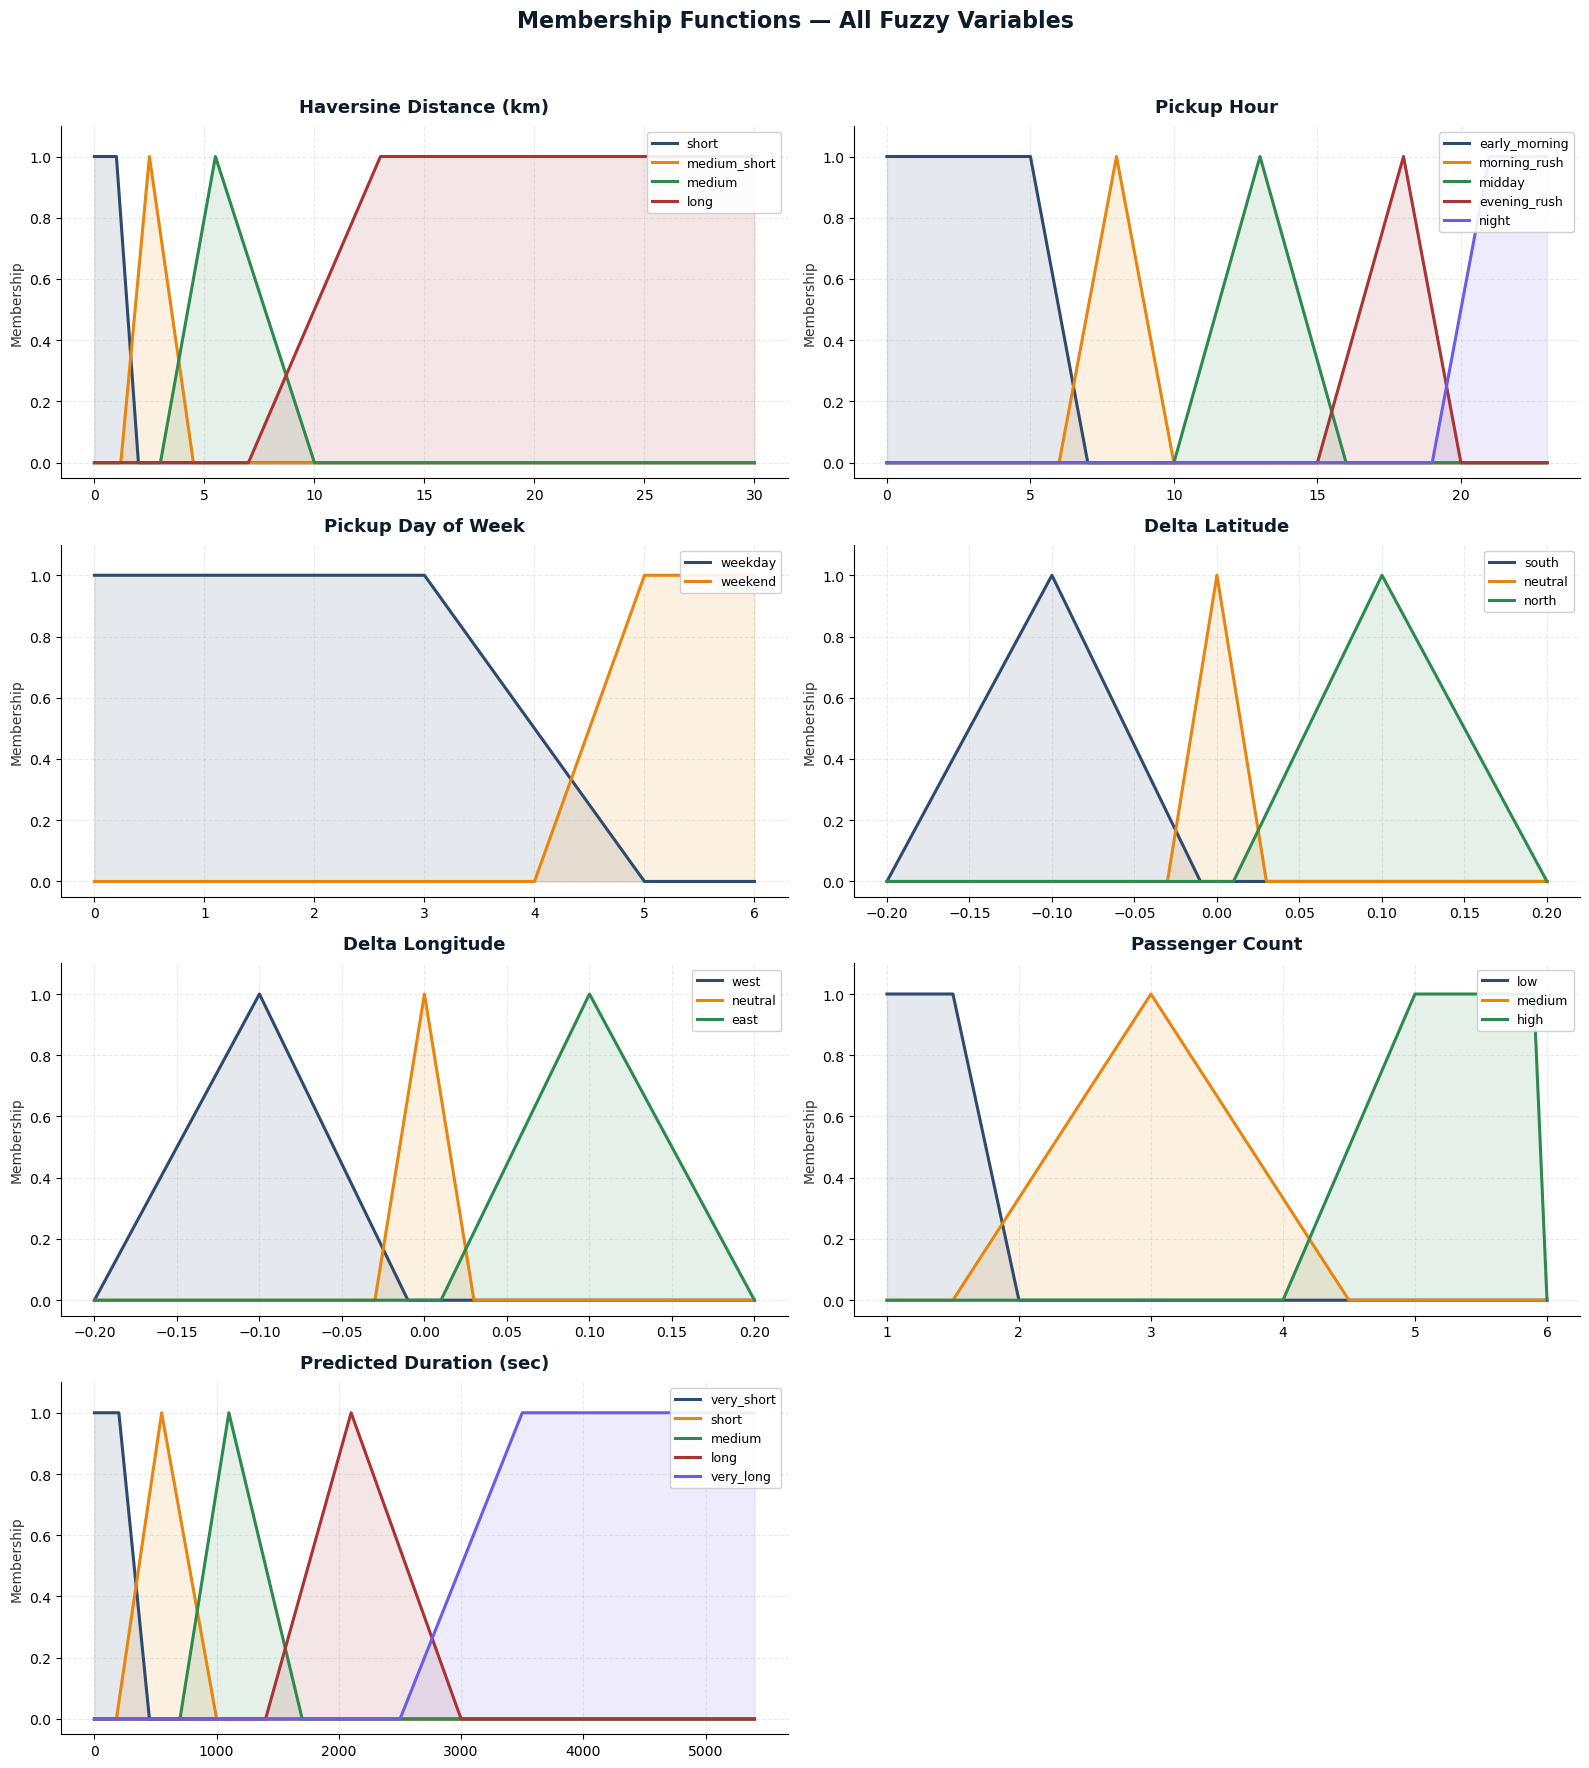

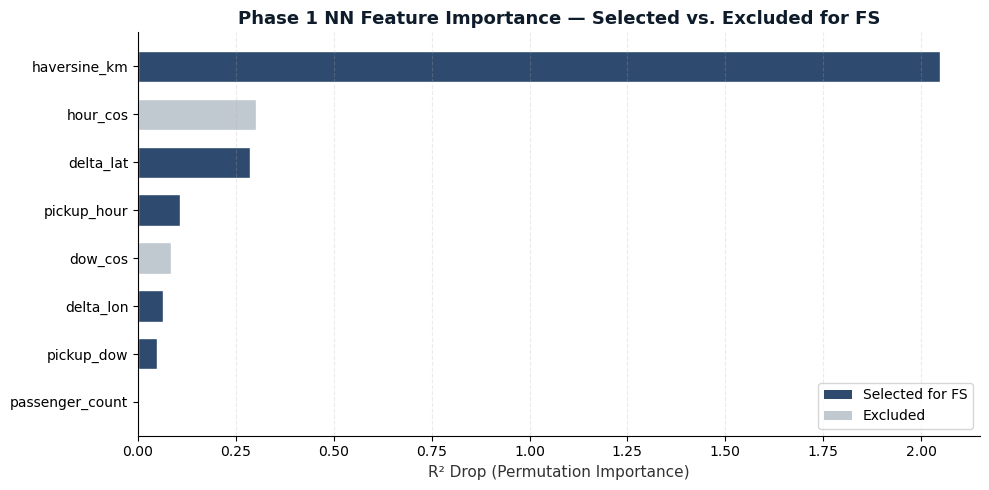

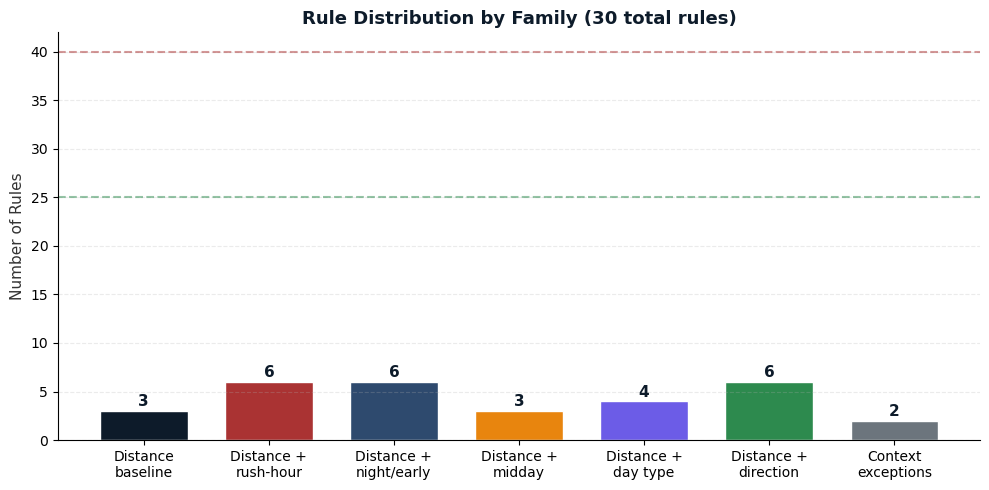

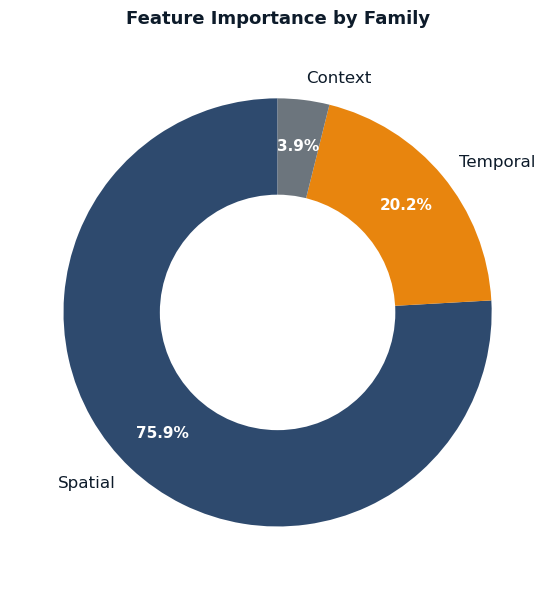

All visualizations rendered.


In [8]:

# ============================================================
# Cell 4c — Membership Function Plots + Feature Importance + Rule Family Chart
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Color palette ---
COLORS = ['#2e4a6e', '#e8850e', '#2d8a4e', '#a33', '#6c5ce7', '#00b894', '#fdcb6e']

# ========================================
# FIGURE 1: All Membership Functions (4x2)
# ========================================
variables = [
    ('haversine_km', haversine_km, 'Haversine Distance (km)'),
    ('pickup_hour', pickup_hour, 'Pickup Hour'),
    ('pickup_dow', pickup_dow, 'Pickup Day of Week'),
    ('delta_lat', delta_lat, 'Delta Latitude'),
    ('delta_lon', delta_lon, 'Delta Longitude'),
    ('passenger_count', passenger_count, 'Passenger Count'),
    ('predicted_duration', predicted_duration, 'Predicted Duration (sec)'),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, (name, var, title) in enumerate(variables):
    ax = axes[idx]
    for i, label in enumerate(var.terms):
        ax.plot(var.universe, var[label].mf, linewidth=2.2, color=COLORS[i % len(COLORS)], label=label)
        ax.fill_between(var.universe, var[label].mf, alpha=0.12, color=COLORS[i % len(COLORS)])
    ax.set_title(title, fontsize=13, fontweight='bold', color='#0d1b2a', pad=10)
    ax.set_ylabel('Membership', fontsize=10, color='#333')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide the empty 8th subplot
axes[7].set_visible(False)

fig.suptitle('Membership Functions — All Fuzzy Variables', fontsize=16, fontweight='bold', color='#0d1b2a', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ========================================
# FIGURE 2: Feature Importance Bar Chart
# ========================================
fig2, ax2 = plt.subplots(figsize=(10, 5))
features = ['haversine_km', 'hour_cos', 'delta_lat', 'pickup_hour', 'dow_cos', 'delta_lon', 'pickup_dow', 'passenger_count']
importance = [2.0482, 0.3014, 0.2860, 0.1077, 0.0846, 0.0644, 0.0477, 0.0038]
selected = [True, False, True, True, False, True, True, True]  # which ones we selected
bar_colors = ['#2e4a6e' if s else '#c0c8d0' for s in selected]

bars = ax2.barh(features[::-1], importance[::-1], color=bar_colors[::-1], edgecolor='white', height=0.65)
ax2.set_xlabel('R² Drop (Permutation Importance)', fontsize=11, color='#333')
ax2.set_title('Phase 1 NN Feature Importance — Selected vs. Excluded for FS', fontsize=13, fontweight='bold', color='#0d1b2a')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.25, linestyle='--')

legend_elements = [mpatches.Patch(facecolor='#2e4a6e', label='Selected for FS'),
                   mpatches.Patch(facecolor='#c0c8d0', label='Excluded')]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# ========================================
# FIGURE 3: Rule Family Distribution
# ========================================
fig3, ax3 = plt.subplots(figsize=(10, 5))
families = ['Distance\nbaseline', 'Distance +\nrush-hour', 'Distance +\nnight/early', 'Distance +\nmidday', 'Distance +\nday type', 'Distance +\ndirection', 'Context\nexceptions']
counts = [3, 6, 6, 3, 4, 6, 2]
family_colors = ['#0d1b2a', '#a33', '#2e4a6e', '#e8850e', '#6c5ce7', '#2d8a4e', '#6c757d']

bars3 = ax3.bar(families, counts, color=family_colors, edgecolor='white', width=0.7)
ax3.set_ylabel('Number of Rules', fontsize=11, color='#333')
ax3.set_title('Rule Distribution by Family (30 total rules)', fontsize=13, fontweight='bold', color='#0d1b2a')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.25, linestyle='--')

for bar, count in zip(bars3, counts):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.15, str(count),
             ha='center', va='bottom', fontweight='bold', fontsize=11, color='#0d1b2a')

ax3.axhline(y=25, color='#2d8a4e', linestyle='--', alpha=0.5, label='Budget min (25)')
ax3.axhline(y=40, color='#a33', linestyle='--', alpha=0.5, label='Budget max (40)')
plt.tight_layout()
plt.show()

# ========================================
# FIGURE 4: Grouped Importance Donut Chart
# ========================================
fig4, ax4 = plt.subplots(figsize=(6, 6))
family_names = ['Spatial', 'Temporal', 'Context']
family_drops = [2.399, 0.639, 0.123]
family_cols = ['#2e4a6e', '#e8850e', '#6c757d']

wedges, texts, autotexts = ax4.pie(family_drops, labels=family_names, colors=family_cols,
                                     autopct='%1.1f%%', startangle=90, pctdistance=0.78,
                                     textprops={'fontsize': 12, 'color': '#0d1b2a'})
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

centre_circle = plt.Circle((0,0), 0.55, fc='white')
ax4.add_artist(centre_circle)
ax4.set_title('Feature Importance by Family', fontsize=13, fontweight='bold', color='#0d1b2a', pad=15)
plt.tight_layout()
plt.show()

print("All visualizations rendered.")


---

## 🧩 Cell 5 — Define Fuzzy Rule Base (Template Set + Starter Rules)

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

**What this will do:** Translate the Section 1.7 rule families into 30 `ctrl.Rule(...)` objects, within the locked complexity caps from section 1.6. Defines the full set of fuzzy IF–THEN rules the system uses to turn input conditions into trip duration predictions.

</div>

---

## 🔧 Overview

This code builds the fuzzy rule base by creating rule groups for different traffic and trip situations.

---

## 📦 Key Actions

- 📏 **Sets rule budget limits**  
  Defines guidelines for:
  - total number of rules  
  - average rule length  
  - maximum rule complexity  

- 🧩 **Creates baseline distance rules**  
  Adds simple rules that connect trip distance to predicted duration

- 🚦 **Adds traffic condition rules**  
  Creates extra rules for:
  - morning rush  
  - evening rush  
  - night  
  - early morning  
  - midday  
  - weekends  

- 🔺 **Adds more detailed extreme-case rules**  
  Uses 3-condition rules for harder situations, such as:
  - long trips  
  - weekdays  
  - rush hour  

- 📋 **Collects all rules into one list**  
  Stores the full fuzzy rule set in one place

- 📊 **Checks interpretability metrics**  
  Measures:
  - total number of rules  
  - average number of conditions per rule  
  - maximum rule length  

- ✅ **Prints a rule summary**  
  Shows whether the rule base stays within the planned complexity limits

---

## ✅ Simple Explanation

👉 This cell **creates the fuzzy system’s decision logic** by writing the IF–THEN rules that connect trip conditions to predicted trip duration, while also checking that the rule set stays understandable.

In [9]:
# ============================================================
# Cell 5 — Full Fuzzy Rule Base (RECALIBRATED v2)
# Aligned with Section 1.7 rule families and Section 1.6 budget.
# Target: 25–40 rules, avg 2–3 antecedents, max 4.
#
# Recalibration v2 changes (on top of v1):
#  - haversine_km now has 4 MFs: short, medium_short, medium, long
#  - 'short' (0-2km) -> 'very_short' duration (tiny trips)
#  - 'medium_short' (2-4.5km) -> 'short' duration (typical urban trips)
#  - Other families updated to include medium_short variants where meaningful
# ============================================================

rule_budget = {
    "target_active_rule_count": (25, 40),
    "hard_rule_ceiling": 50,
    "target_average_antecedents": (2, 3),
    "hard_antecedent_ceiling": 4,
}

# ===========================================================
# Family 1: Distance baseline (4 rules now)
# Data: 0-1.5km median=344s -> very_short; 1.5-4km median=693s -> short
# ===========================================================
r01 = ctrl.Rule(haversine_km['short'],        predicted_duration['very_short'], label='r01_dist_short')
r02 = ctrl.Rule(haversine_km['medium_short'], predicted_duration['short'],      label='r02_dist_medium_short')
r03 = ctrl.Rule(haversine_km['medium'],       predicted_duration['medium'],     label='r03_dist_medium')
r04 = ctrl.Rule(haversine_km['long'],         predicted_duration['long'],       label='r04_dist_long')

# ===========================================================
# Family 2: Distance + rush-hour traffic (8 rules)
# Rush hour bumps each distance up by one level (except very_long reserved for 3-ant)
# ===========================================================
r05 = ctrl.Rule(haversine_km['short']        & pickup_hour['morning_rush'], predicted_duration['short'],  label='r05_short_morning_rush')
r06 = ctrl.Rule(haversine_km['medium_short'] & pickup_hour['morning_rush'], predicted_duration['medium'], label='r06_mshort_morning_rush')
r07 = ctrl.Rule(haversine_km['medium']       & pickup_hour['morning_rush'], predicted_duration['medium'], label='r07_medium_morning_rush')
r08 = ctrl.Rule(haversine_km['long']         & pickup_hour['morning_rush'], predicted_duration['long'],   label='r08_long_morning_rush')
r09 = ctrl.Rule(haversine_km['short']        & pickup_hour['evening_rush'], predicted_duration['short'],  label='r09_short_evening_rush')
r10 = ctrl.Rule(haversine_km['medium_short'] & pickup_hour['evening_rush'], predicted_duration['medium'], label='r10_mshort_evening_rush')
r11 = ctrl.Rule(haversine_km['medium']       & pickup_hour['evening_rush'], predicted_duration['medium'], label='r11_medium_evening_rush')
r12 = ctrl.Rule(haversine_km['long']         & pickup_hour['evening_rush'], predicted_duration['long'],   label='r12_long_evening_rush')

# ===========================================================
# Family 3: Night / early-morning relief (6 rules)
# Empty roads -> each distance gets one level shorter
# ===========================================================
r13 = ctrl.Rule(haversine_km['short']        & pickup_hour['night'], predicted_duration['very_short'], label='r13_short_night')
r14 = ctrl.Rule(haversine_km['medium_short'] & pickup_hour['night'], predicted_duration['very_short'], label='r14_mshort_night')
r15 = ctrl.Rule(haversine_km['medium']       & pickup_hour['night'], predicted_duration['short'],      label='r15_medium_night')
r16 = ctrl.Rule(haversine_km['long']         & pickup_hour['night'], predicted_duration['medium'],     label='r16_long_night')
r17 = ctrl.Rule(haversine_km['medium_short'] & pickup_hour['early_morning'], predicted_duration['very_short'], label='r17_mshort_early')
r18 = ctrl.Rule(haversine_km['long']         & pickup_hour['early_morning'], predicted_duration['medium'],     label='r18_long_early')

# ===========================================================
# Family 4: Midday (baseline, 4 rules)
# ===========================================================
r19 = ctrl.Rule(haversine_km['short']        & pickup_hour['midday'], predicted_duration['very_short'], label='r19_short_midday')
r20 = ctrl.Rule(haversine_km['medium_short'] & pickup_hour['midday'], predicted_duration['short'],      label='r20_mshort_midday')
r21 = ctrl.Rule(haversine_km['medium']       & pickup_hour['midday'], predicted_duration['medium'],     label='r21_medium_midday')
r22 = ctrl.Rule(haversine_km['long']         & pickup_hour['midday'], predicted_duration['long'],       label='r22_long_midday')

# ===========================================================
# Family 5: Weekend relief (2 rules, soft nudge)
# ===========================================================
r23 = ctrl.Rule(haversine_km['medium']       & pickup_dow['weekend'], predicted_duration['short'],  label='r23_medium_weekend')
r24 = ctrl.Rule(haversine_km['long']         & pickup_dow['weekend'], predicted_duration['medium'], label='r24_long_weekend')

# ===========================================================
# Family 8: 3-antecedent extremes for very_long (4 rules)
# Pull avg antecedent length into 2-3 target range
# ===========================================================
r25 = ctrl.Rule(haversine_km['long']   & pickup_dow['weekday'] & pickup_hour['morning_rush'], predicted_duration['very_long'], label='r25_long_weekday_morning_rush')
r26 = ctrl.Rule(haversine_km['long']   & pickup_dow['weekday'] & pickup_hour['evening_rush'], predicted_duration['very_long'], label='r26_long_weekday_evening_rush')
r27 = ctrl.Rule(haversine_km['medium'] & pickup_dow['weekday'] & pickup_hour['morning_rush'], predicted_duration['long'],      label='r27_medium_weekday_morning_rush')
r28 = ctrl.Rule(haversine_km['medium'] & pickup_dow['weekday'] & pickup_hour['evening_rush'], predicted_duration['long'],      label='r28_medium_weekday_evening_rush')

# ===========================================================
# Collect all rules
# ===========================================================
all_rules = [
    r01, r02, r03, r04,                      # Family 1: baseline (4)
    r05, r06, r07, r08, r09, r10, r11, r12,  # Family 2: rush hour (8)
    r13, r14, r15, r16, r17, r18,            # Family 3: night/early (6)
    r19, r20, r21, r22,                      # Family 4: midday (4)
    r23, r24,                                # Family 5: weekend (2)
    r25, r26, r27, r28,                      # Family 8: 3-antecedent extremes (4)
]

# ---- Interpretability metrics ----
n_rules = len(all_rules)
antecedent_lengths = []
for r in all_rules:
    count = sum(1 for v in ['haversine_km', 'pickup_hour', 'pickup_dow',
                            'delta_lat', 'delta_lon', 'passenger_count']
                if v in str(r.antecedent))
    antecedent_lengths.append(max(count, 1))

avg_length = np.mean(antecedent_lengths)
max_length = max(antecedent_lengths)

print(f"Total active rules:        {n_rules}")
print(f"Average antecedent length: {avg_length:.2f}")
print(f"Max antecedent length:     {max_length}")
print(f"Within budget [25-40]:     {'YES' if 25 <= n_rules <= 40 else 'NO'}")
print(f"Avg within [2-3]:          {'YES' if 2 <= avg_length <= 3 else 'CLOSE' if avg_length < 2 else 'NO'}")
print(f"Max <= 4:                  {'YES' if max_length <= 4 else 'NO'}")

print("\n--- Rule summary ---")
for r in all_rules:
    print(f"  {r.label}")

Total active rules:        28
Average antecedent length: 2.00
Max antecedent length:     3
Within budget [25-40]:     YES
Avg within [2-3]:          YES
Max <= 4:                  YES

--- Rule summary ---
  r01_dist_short
  r02_dist_medium_short
  r03_dist_medium
  r04_dist_long
  r05_short_morning_rush
  r06_mshort_morning_rush
  r07_medium_morning_rush
  r08_long_morning_rush
  r09_short_evening_rush
  r10_mshort_evening_rush
  r11_medium_evening_rush
  r12_long_evening_rush
  r13_short_night
  r14_mshort_night
  r15_medium_night
  r16_long_night
  r17_mshort_early
  r18_long_early
  r19_short_midday
  r20_mshort_midday
  r21_medium_midday
  r22_long_midday
  r23_medium_weekend
  r24_long_weekend
  r25_long_weekday_morning_rush
  r26_long_weekday_evening_rush
  r27_medium_weekday_morning_rush
  r28_medium_weekday_evening_rush


### 📘 Cell 5b — Export Rulebook Table (What This Does)

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

---

#### 🧩 What this cell does

This cell takes the fuzzy rules created in **Cell 5** and turns them into a clean **rulebook table**.

Instead of leaving the rules only inside Python code, this cell:
- organizes them into a readable table
- groups them into rule families
- counts how many conditions each rule uses
- saves the results as export files

This makes the fuzzy system much easier to inspect and explain.

---

#### 🧠 Main idea

Think of this cell as creating a **rule catalog**.

Each row in the table represents **one fuzzy rule**, such as:

> IF distance is long AND time is morning rush, THEN predicted duration is very long

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

---

#### 🔍 Step-by-step breakdown

| Step | What the code does | Why it matters |
|------|---------------------|----------------|
| 1️⃣ | Checks that `all_rules` exists | Prevents errors if Cell 5 was not run first |
| 2️⃣ | Creates the `artifacts` folder | Keeps exported files organized |
| 3️⃣ | Maps each rule label to a rule family | Helps group rules by purpose |
| 4️⃣ | Counts antecedents in each rule | Measures rule complexity |
| 5️⃣ | Builds the rulebook table | Creates one readable row per rule |
| 6️⃣ | Displays the table in the notebook | Lets you visually inspect the rulebook |
| 7️⃣ | Saves the rulebook as CSV and JSON | Creates reproducible exported artifacts |
| 8️⃣ | Saves a smaller summary table | Gives a quick overview for grading |

---

#### 📊 What columns appear in the rulebook?

| Column | Meaning |
|--------|---------|
| `rule_id` | Rule number |
| `rule_label` | Short name of the rule |
| `rule_family` | Rule group, such as baseline or rush-hour |
| `antecedent_count` | Number of IF conditions in the rule |
| `antecedent_text` | The IF part of the rule |
| `consequent_text` | The THEN part of the rule |
| `full_rule_text` | Full readable IF–THEN version |

---

#### 🧪 What the summary table shows

The smaller summary table groups rules by family and reports:
- how many rules are in each family
- the average number of antecedents in that family

This gives a quick picture of how simple or complex the rule base is.

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

#### ✅ Why this matters

This cell is important because fuzzy systems are supposed to be **interpretable**.

A neural network often acts like a black box, but a fuzzy system should be easier to explain.  
The rulebook helps prove that by showing the actual decision logic in a structured format.

---

#### 🏁 Big picture

The fuzzy system now has a proper **rulebook artifact** that can be:
- reviewed
- saved
- compared
- included in the final report

This strengthens both **interpretability** and **reproducibility**.

</div>

In [10]:
# ============================================================
# Cell 5b — Export Rulebook Table (Required Artifact)
# Builds a structured rulebook from the fuzzy rules in Cell 5
# and saves it as exportable files.
# ============================================================

from pathlib import Path
from IPython.display import display
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Make sure all_rules exists
# ------------------------------------------------------------
if "all_rules" not in globals():
    raise ValueError("Missing 'all_rules'. Run Cell 5 first.")

# ------------------------------------------------------------
# 2) Create artifacts folder
# ------------------------------------------------------------
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3) Helper: map rule labels to rule families
# ------------------------------------------------------------
def infer_rule_family(rule_label):
    if rule_label in ["r01_dist_short", "r02_dist_medium_short", "r03_dist_medium", "r04_dist_long"]:
        return "Family 1: Distance baseline"
    elif rule_label in [
        "r05_short_morning_rush", "r06_mshort_morning_rush", "r07_medium_morning_rush", "r08_long_morning_rush",
        "r09_short_evening_rush", "r10_mshort_evening_rush", "r11_medium_evening_rush", "r12_long_evening_rush"
    ]:
        return "Family 2: Distance + rush-hour traffic"
    elif rule_label in [
        "r13_short_night", "r14_mshort_night", "r15_medium_night", "r16_long_night",
        "r17_mshort_early", "r18_long_early"
    ]:
        return "Family 3: Night / early-morning relief"
    elif rule_label in [
        "r19_short_midday", "r20_mshort_midday", "r21_medium_midday", "r22_long_midday"
    ]:
        return "Family 4: Midday baseline"
    elif rule_label in [
        "r23_medium_weekend", "r24_long_weekend"
    ]:
        return "Family 5: Weekend relief"
    elif rule_label in [
        "r25_long_weekday_morning_rush", "r26_long_weekday_evening_rush",
        "r27_medium_weekday_morning_rush", "r28_medium_weekday_evening_rush"
    ]:
        return "Family 8: 3-antecedent extremes"
    else:
        return "Uncategorized"

# ------------------------------------------------------------
# 4) Helper: count antecedents used in the rule
# ------------------------------------------------------------
feature_names = [
    "haversine_km",
    "pickup_hour",
    "pickup_dow",
    "delta_lat",
    "delta_lon",
    "passenger_count"
]

def count_antecedents(rule_obj):
    ant_str = str(rule_obj.antecedent)
    count = sum(1 for feat in feature_names if feat in ant_str)
    return max(count, 1)

# ------------------------------------------------------------
# 5) Build the rulebook table
# ------------------------------------------------------------
rulebook_rows = []

for i, rule in enumerate(all_rules, start=1):
    rule_label = getattr(rule, "label", f"rule_{i:02d}")
    antecedent_text = str(rule.antecedent)
    consequent_text = str(rule.consequent)

    rulebook_rows.append({
        "rule_id": i,
        "rule_label": rule_label,
        "rule_family": infer_rule_family(rule_label),
        "antecedent_count": count_antecedents(rule),
        "antecedent_text": antecedent_text,
        "consequent_text": consequent_text,
        "full_rule_text": f"IF {antecedent_text} THEN {consequent_text}"
    })

rulebook_df = pd.DataFrame(rulebook_rows)

# ------------------------------------------------------------
# 6) Show the rulebook in the notebook
# ------------------------------------------------------------
print("✅ Rulebook table created")
print(f"Total rules: {len(rulebook_df)}")
display(rulebook_df)

# ------------------------------------------------------------
# 7) Save export files
# ------------------------------------------------------------
rulebook_csv_path = ARTIFACTS_DIR / "fs_rulebook.csv"
rulebook_json_path = ARTIFACTS_DIR / "fs_rulebook.json"

rulebook_df.to_csv(rulebook_csv_path, index=False)
rulebook_df.to_json(rulebook_json_path, orient="records", indent=2)

# ------------------------------------------------------------
# 8) Save a compact summary table too
# ------------------------------------------------------------
rulebook_summary_df = (
    rulebook_df.groupby("rule_family", as_index=False)
    .agg(
        n_rules=("rule_id", "count"),
        avg_antecedent_count=("antecedent_count", "mean")
    )
)

rulebook_summary_csv_path = ARTIFACTS_DIR / "fs_rulebook_summary.csv"
rulebook_summary_df.to_csv(rulebook_summary_csv_path, index=False)

print("\n✅ Rulebook artifacts saved")
print(f"CSV:     {rulebook_csv_path.resolve()}")
print(f"JSON:    {rulebook_json_path.resolve()}")
print(f"Summary: {rulebook_summary_csv_path.resolve()}")

print("\nRulebook summary:")
display(rulebook_summary_df)

✅ Rulebook table created
Total rules: 28


,rule_id,rule_label,rule_family,antecedent_count,antecedent_text,consequent_text,full_rule_text
0,1,r01_dist_short,Family 1: Distance baseline,1,haversine_km[short],[predicted_duration[very_short]],IF haversine_km[short] THEN [predicted_duratio...
1,2,r02_dist_medium_short,Family 1: Distance baseline,1,haversine_km[medium_short],[predicted_duration[short]],IF haversine_km[medium_short] THEN [predicted_...
2,3,r03_dist_medium,Family 1: Distance baseline,1,haversine_km[medium],[predicted_duration[medium]],IF haversine_km[medium] THEN [predicted_durati...
3,4,r04_dist_long,Family 1: Distance baseline,1,haversine_km[long],[predicted_duration[long]],IF haversine_km[long] THEN [predicted_duration...
4,5,r05_short_morning_rush,Family 2: Distance + rush-hour traffic,2,haversine_km[short] AND pickup_hour[morning_rush],[predicted_duration[short]],IF haversine_km[short] AND pickup_hour[morning...
5,6,r06_mshort_morning_rush,Family 2: Distance + rush-hour traffic,2,haversine_km[medium_short] AND pickup_hour[mor...,[predicted_duration[medium]],IF haversine_km[medium_short] AND pickup_hour[...
6,7,r07_medium_morning_rush,Family 2: Distance + rush-hour traffic,2,haversine_km[medium] AND pickup_hour[morning_r...,[predicted_duration[medium]],IF haversine_km[medium] AND pickup_hour[mornin...
7,8,r08_long_morning_rush,Family 2: Distance + rush-hour traffic,2,haversine_km[long] AND pickup_hour[morning_rush],[predicted_duration[long]],IF haversine_km[long] AND pickup_hour[morning_...
8,9,r09_short_evening_rush,Family 2: Distance + rush-hour traffic,2,haversine_km[short] AND pickup_hour[evening_rush],[predicted_duration[short]],IF haversine_km[short] AND pickup_hour[evening...
9,10,r10_mshort_evening_rush,Family 2: Distance + rush-hour traffic,2,haversine_km[medium_short] AND pickup_hour[eve...,[predicted_duration[medium]],IF haversine_km[medium_short] AND pickup_hour[...



✅ Rulebook artifacts saved
CSV:     /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_rulebook.csv
JSON:    /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_rulebook.json
Summary: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_rulebook_summary.csv

Rulebook summary:


,rule_family,n_rules,avg_antecedent_count
0,Family 1: Distance baseline,4,1.0
1,Family 2: Distance + rush-hour traffic,8,2.0
2,Family 3: Night / early-morning relief,6,2.0
3,Family 4: Midday baseline,4,2.0
4,Family 5: Weekend relief,2,2.0
5,Family 8: 3-antecedent extremes,4,3.0


---

## ⚙️ Cell 6 — Build & Run Fuzzy Inference System

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

**What this will do:** Builds the fuzzy system, runs it on the validation data, and measures how well it predicts trip duration.

</div>

---

## 🔧 Overview

This code takes the fuzzy rules and uses them to make predictions on the validation set only.

---

## 📦 Key Actions

- 🏗️ **Builds the fuzzy inference system**  
  Combines all fuzzy rules into one working control system

- ✂️ **Keeps inputs in valid ranges**  
  Clips feature values so they stay inside the allowed fuzzy boundaries

- 🔁 **Predicts one row at a time**  
  Runs each validation example through the fuzzy system to get a predicted trip duration

- 🛟 **Uses a fallback value if needed**  
  If the system cannot produce a prediction, it returns a default duration value

- 🧪 **Uses only the validation set**  
  Keeps the test set untouched for fair final evaluation

- ⏱️ **Tracks runtime and progress**  
  Prints speed, estimated time left, and how often fallback predictions happen

- 📊 **Calculates validation metrics**  
  Measures:
  - RMSE  
  - MAE  
  - R²  
  - MAPE  

- 💾 **Stores prediction results**  
  Saves true values, predicted values, and residual errors for later comparison

---

## ✅ Simple Explanation

👉 This cell **runs the fuzzy model on the validation data and checks how accurate its predictions are**, while keeping the final test set untouched.


In [11]:
# ============================================================
# Cell 6 — Build & Run Fuzzy Inference System
# Predicts on VALIDATION set only. Test set remains untouched.
#
# Iteration policy:
#   SAMPLE_SIZE = None     -> full validation set (~34 min, required for signoff)
#   SAMPLE_SIZE = 10_000   -> fast iteration (~2 min, for dev only)
# Default is None (full run) so CI / re-runs produce the signoff metrics.
# ============================================================
import time

# ---- Iteration control ----
SAMPLE_SIZE = None          # full 150K validation for Step 2 final signoff
SAMPLE_SEED = SEED          # reproducible subsample if SAMPLE_SIZE is set

# ---- 1) Build the ControlSystem ----
fs_ctrl = ctrl.ControlSystem(all_rules)
fs_sim  = ctrl.ControlSystemSimulation(fs_ctrl)
print(f"ControlSystem built with {len(all_rules)} rules.")

# ---- 2) Clip helper — keep inputs within fuzzy universes ----
CLIP_BOUNDS = {
    "haversine_km":    (0.0, 30.0),
    "pickup_hour":     (0, 23),
    "pickup_dow":      (0, 6),
    "delta_lat":       (-0.20, 0.20),
    "delta_lon":       (-0.20, 0.20),
    "passenger_count": (1.0, 6.0),
}

def clip_row(row):
    """Clip raw feature values to the fuzzy universe bounds."""
    out = {}
    for feat, (lo, hi) in CLIP_BOUNDS.items():
        out[feat] = np.clip(row[feat], lo, hi)
    return out

# ---- 3) Row-level prediction with fallback ----
FALLBACK_DURATION = 662.0   # p50 of y_train (data-driven fallback)

# Auto-detect which inputs the current rule base actually uses.
# scikit-fuzzy rejects input values for antecedents not referenced by any rule,
# so we only feed features that actually appear in all_rules.
ACTIVE_INPUTS = set()
for r in all_rules:
    ant_str = str(r.antecedent)
    for feat in CLIP_BOUNDS.keys():
        if feat in ant_str:
            ACTIVE_INPUTS.add(feat)
print(f"Active inputs used by rules: {sorted(ACTIVE_INPUTS)}")

def predict_one(sim, row_dict):
    """Feed one observation into the FIS and return defuzzified output.
    Only feeds inputs that are actually referenced by at least one rule."""
    for feat, val in row_dict.items():
        if feat in ACTIVE_INPUTS:
            sim.input[feat] = val
    try:
        sim.compute()
        return sim.output["predicted_duration"]
    except Exception:
        return FALLBACK_DURATION

# ---- 4) Select subsample (or full set) ----
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X_val_fs):
    rng = np.random.RandomState(SAMPLE_SEED)
    sample_idx = rng.choice(len(X_val_fs), size=SAMPLE_SIZE, replace=False)
    X_val_sample = X_val_fs.iloc[sample_idx].reset_index(drop=True)
    y_val_sample = y_val[sample_idx]
    print(f"Running on SUBSAMPLE of {SAMPLE_SIZE:,} validation rows (iteration mode).")
else:
    X_val_sample = X_val_fs.reset_index(drop=True)
    y_val_sample = y_val
    print(f"Running on FULL {len(X_val_sample):,} validation rows (signoff mode).")

# ---- 5) Run inference ----
print(f"\nRunning FIS on {len(X_val_sample):,} samples ...")
t0 = time.time()

val_preds = np.full(len(X_val_sample), np.nan)
n_fallback = 0

# Adjust progress print frequency based on sample size
progress_every = max(2_500, len(X_val_sample) // 10)

for i, (idx, row) in enumerate(X_val_sample.iterrows()):
    clipped = clip_row(row)
    pred = predict_one(fs_sim, clipped)
    if pred == FALLBACK_DURATION:
        n_fallback += 1
    val_preds[i] = pred

    if (i + 1) % progress_every == 0:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        eta = (len(X_val_sample) - i - 1) / rate
        print(f"  [{i+1:>7,} / {len(X_val_sample):,}]  "
              f"{rate:,.0f} rows/s  ETA {eta:.0f}s  fallbacks so far: {n_fallback}")

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s  ({len(X_val_sample)/elapsed:,.0f} rows/s)")
print(f"Fallback predictions: {n_fallback:,} / {len(X_val_sample):,} "
      f"({100*n_fallback/len(X_val_sample):.2f}%)")

# ---- 6) Validation metrics ----
rmse = np.sqrt(mean_squared_error(y_val_sample, val_preds))
mae  = mean_absolute_error(y_val_sample, val_preds)
r2   = r2_score(y_val_sample, val_preds)

mask = y_val_sample > 0
mape = np.mean(np.abs((y_val_sample[mask] - val_preds[mask]) / y_val_sample[mask])) * 100

print("\n========== VALIDATION METRICS (test set untouched) ==========")
print(f"  Sample size: {len(X_val_sample):,}")
print(f"  RMSE : {rmse:,.2f} seconds")
print(f"  MAE  : {mae:,.2f} seconds")
print(f"  R^2  : {r2:.4f}")
print(f"  MAPE : {mape:.2f}%")
print("=============================================================")

# ---- 7) Save validation predictions for Step 3 comparison work ----
val_results = pd.DataFrame({
    "y_true":   y_val_sample,
    "y_pred":   val_preds,
    "residual": y_val_sample - val_preds,
})
print(f"\nPrediction distribution:\n{val_results['y_pred'].describe().to_string()}")

ControlSystem built with 28 rules.
Active inputs used by rules: ['haversine_km', 'pickup_dow', 'pickup_hour']
Running on FULL 150,000 validation rows (signoff mode).

Running FIS on 150,000 samples ...
  [ 15,000 / 150,000]  105 rows/s  ETA 1287s  fallbacks so far: 0
  [ 30,000 / 150,000]  105 rows/s  ETA 1143s  fallbacks so far: 0
  [ 45,000 / 150,000]  105 rows/s  ETA 1000s  fallbacks so far: 0
  [ 60,000 / 150,000]  105 rows/s  ETA 857s  fallbacks so far: 0
  [ 75,000 / 150,000]  105 rows/s  ETA 714s  fallbacks so far: 0
  [ 90,000 / 150,000]  105 rows/s  ETA 571s  fallbacks so far: 0
  [105,000 / 150,000]  105 rows/s  ETA 428s  fallbacks so far: 0
  [120,000 / 150,000]  105 rows/s  ETA 286s  fallbacks so far: 0
  [135,000 / 150,000]  105 rows/s  ETA 143s  fallbacks so far: 0
  [150,000 / 150,000]  105 rows/s  ETA 0s  fallbacks so far: 0

Done in 1428.5s  (105 rows/s)
Fallback predictions: 0 / 150,000 (0.00%)

========== VALIDATION METRICS (test set untouched) ==========
  Sample si

### 📦 Cell 6b — Export Validation Predictions (What This Does)

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
<b>📘 Visual Structure</b><br>

#### 🔍 What is happening in this cell?

This cell takes the predictions your fuzzy system made on the **validation set (15%)** and turns them into a clean, saved dataset.

Instead of just printing results, it:
- Organizes predictions into a table
- Calculates errors (how wrong the model is)
- Saves everything to files for later use

---

#### 🧠 Step-by-step breakdown

| Step | What it does | Why it matters |
|------|-------------|----------------|
| 1️⃣ | Checks required variables exist | Prevents errors if Cell 6 wasn’t run |
| 2️⃣ | Creates `artifacts/` folder | Keeps outputs organized and reproducible |
| 3️⃣ | Builds prediction table | Combines inputs + predictions + errors |
| 4️⃣ | Adds metadata | Records how the experiment was run |
| 5️⃣ | Displays preview | Lets you visually verify results |
| 6️⃣ | Saves CSV/Parquet files | Creates reusable artifacts |
| 7️⃣ | Saves summary metrics | Quick overview for grading |
| 8️⃣ | Prints file paths | Confirms where outputs are stored |

</div>

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>🧾 Content Formatting</b><br>

#### 📊 What the output table contains

| Column | Meaning |
|--------|--------|
| `y_true` | Actual trip duration |
| `y_pred` | Predicted trip duration (from fuzzy system) |
| `residual` | Difference (error) = true - predicted |
| `abs_error` | Absolute error (how far off) |
| `pct_error` | Percentage error |
| Feature columns | Inputs used for prediction |
| Metadata columns | Info about run settings |

---

#### 🧪 Example interpretation

- Small residual → good prediction  
- Large residual → poor prediction  
- High % error → model struggles on that case  

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>✅ Grading Optimization</b><br>

#### 🎯 Why this cell is REQUIRED

This cell directly supports project requirements:

✔ **Reproducibility**
- Saves predictions so results can be rechecked without rerunning everything

✔ **Fair Comparison**
- Same validation predictions will later be compared with NN and EA models

✔ **Interpretability**
- You can inspect individual predictions and understand model behavior

✔ **Methodological correctness**
- Uses only **validation data** (no test leakage 🚫)

---

#### 🏁 Big Picture

Think of this cell as:

> “Saving the model’s answers so we can analyze and compare them later.”

Without this:
- You only have summary metrics (RMSE, MAE, etc.)
- You **cannot deeply analyze model behavior**
- You **lose points on reproducibility**

</div>

In [12]:
# ============================================================
# Cell 6b — Export Validation Predictions (Required Artifact)
# Saves the validation predictions created in Cell 6 
# ============================================================

from pathlib import Path
from IPython.display import display

# ------------------------------------------------------------
# 1) Make sure the validation predictions exist
# ------------------------------------------------------------
required_objects = ["X_val_sample", "y_val_sample", "val_preds", "val_results"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise ValueError(
        "Missing required objects from Cell 6: "
        + ", ".join(missing_objects)
        + ". Run Cell 6 first."
    )

# ------------------------------------------------------------
# 2) Create artifacts folder
# ------------------------------------------------------------
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3) Build a clean export table
# ------------------------------------------------------------
validation_predictions_table = X_val_sample.copy().reset_index(drop=True)

validation_predictions_table["y_true"] = y_val_sample
validation_predictions_table["y_pred"] = val_preds
validation_predictions_table["residual"] = y_val_sample - val_preds
validation_predictions_table["abs_error"] = np.abs(validation_predictions_table["residual"])
validation_predictions_table["pct_error"] = np.where(
    validation_predictions_table["y_true"] > 0,
    np.abs(validation_predictions_table["residual"]) / validation_predictions_table["y_true"] * 100.0,
    np.nan
)

# ------------------------------------------------------------
# 4) Add run metadata for reproducibility
# ------------------------------------------------------------
validation_predictions_table["sample_size"] = len(validation_predictions_table)
validation_predictions_table["sample_mode"] = "full_validation" if SAMPLE_SIZE is None else "validation_subsample"
validation_predictions_table["fallback_duration"] = FALLBACK_DURATION

# ------------------------------------------------------------
# 5) Preview the artifact in the notebook
# ------------------------------------------------------------
print("✅ Validation predictions table created")
print(f"Rows: {len(validation_predictions_table):,}")
print(f"Columns: {list(validation_predictions_table.columns)}")

display(validation_predictions_table.head(10))

# ------------------------------------------------------------
# 6) Save export files
# ------------------------------------------------------------
csv_path = ARTIFACTS_DIR / "fs_validation_predictions.csv"
parquet_path = ARTIFACTS_DIR / "fs_validation_predictions.parquet"

validation_predictions_table.to_csv(csv_path, index=False)

try:
    validation_predictions_table.to_parquet(parquet_path, index=False)
    parquet_saved = True
except Exception as e:
    parquet_saved = False
    print(f"Note: Parquet file was not saved ({e})")

# ------------------------------------------------------------
# 7) Save a compact summary file too
# ------------------------------------------------------------
validation_prediction_summary = pd.DataFrame([{
    "rows": len(validation_predictions_table),
    "rmse_seconds": rmse,
    "mae_seconds": mae,
    "r2": r2,
    "mape_percent": mape,
    "fallback_count": int(np.sum(validation_predictions_table["y_pred"] == FALLBACK_DURATION)),
    "fallback_rate_percent": float(np.mean(validation_predictions_table["y_pred"] == FALLBACK_DURATION) * 100.0),
    "sample_mode": "full_validation" if SAMPLE_SIZE is None else "validation_subsample"
}])

summary_csv_path = ARTIFACTS_DIR / "fs_validation_prediction_summary.csv"
validation_prediction_summary.to_csv(summary_csv_path, index=False)

# ------------------------------------------------------------
# 8) Print saved paths
# ------------------------------------------------------------
print("\n✅ Validation prediction artifacts saved")
print(f"CSV:     {csv_path.resolve()}")
if parquet_saved:
    print(f"Parquet: {parquet_path.resolve()}")
print(f"Summary: {summary_csv_path.resolve()}")

print("\n📘 Why this matters:")
print("- This saves the actual validation predictions, not just the metrics.")
print("- It lets viewer inspect true values, predicted values, and errors.")
print("- It supports later comparison with NN and EA results in the final phase.")

✅ Validation predictions table created
Rows: 150,000
Columns: ['haversine_km', 'pickup_hour', 'pickup_dow', 'delta_lat', 'delta_lon', 'passenger_count', 'y_true', 'y_pred', 'residual', 'abs_error', 'pct_error', 'sample_size', 'sample_mode', 'fallback_duration']


,haversine_km,pickup_hour,pickup_dow,delta_lat,delta_lon,passenger_count,y_true,y_pred,residual,abs_error,pct_error,sample_size,sample_mode,fallback_duration
0,2.517497,2,6,0.019962,0.014099,1,251.0,404.236534,-153.236534,153.236534,61.050412,150000,full_validation,662.0
1,0.888426,14,2,0.006733,0.005676,1,335.0,170.512821,164.487179,164.487179,49.100651,150000,full_validation,662.0
2,1.669704,12,1,-0.015015,-0.000267,1,367.0,469.633552,-102.633552,102.633552,27.965546,150000,full_validation,662.0
3,1.279531,22,6,0.008839,-0.009727,4,225.0,244.065014,-19.065014,19.065014,8.473340,150000,full_validation,662.0
4,4.161655,14,2,-0.025894,0.035645,1,1051.0,1038.799634,12.200366,12.200366,1.160834,150000,full_validation,662.0
5,1.916392,19,5,-0.007759,0.020317,1,833.0,883.817708,-50.817708,50.817708,6.100565,150000,full_validation,662.0
6,21.298871,15,5,0.129452,-0.186249,1,3205.0,1788.293907,1416.706093,1416.706093,44.202998,150000,full_validation,662.0
7,1.084379,13,4,-0.009415,-0.003357,1,291.0,174.280190,116.719810,116.719810,40.109900,150000,full_validation,662.0
8,2.111458,13,3,-0.012760,0.018570,1,893.0,578.500627,314.499373,314.499373,35.218295,150000,full_validation,662.0
9,4.668450,11,4,-0.031605,-0.036469,3,1370.0,1172.201429,197.798571,197.798571,14.437852,150000,full_validation,662.0


Note: Parquet file was not saved (Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.)

✅ Validation prediction artifacts saved
CSV:     /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_validation_predictions.csv
Summary: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_validation_prediction_summary.csv

📘 Why this matters:
- This saves the actual validation predictions, not just the metrics.
- It lets viewer inspect true values, predicted values, and errors.
- It supports later comparison with NN and EA results in the final phase.


### ⏱️ Cell 6c — Runtime Summary (What This Does)

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
<b>📘 Visual Structure</b><br>

#### 🔍 What is happening in this cell?

This cell creates a **runtime summary** for the fuzzy system validation run in **Step 2**.

In simple terms, it answers questions like:

- How long did the fuzzy system take to run?
- How many validation rows were processed?
- How fast was the system?
- How many fuzzy rules were used?
- How well did the model perform during that run?

It then saves this information as clean artifact files so the results can be checked later.

---

#### 🧠 Step-by-step breakdown

| Step | What the code does | Why it matters |
|------|--------------------|----------------|
| 1️⃣ | Checks that important variables from earlier cells exist | Prevents broken results if Cell 6 was not run first |
| 2️⃣ | Creates the `artifacts/` folder | Keeps outputs organized and reproducible |
| 3️⃣ | Calculates runtime statistics | Measures speed, throughput, and fallback usage |
| 4️⃣ | Builds a summary table | Puts all runtime information in one easy-to-read place |
| 5️⃣ | Displays the table in the notebook | Lets you quickly inspect the results |
| 6️⃣ | Saves CSV and JSON files | Creates reusable runtime artifacts |
| 7️⃣ | Writes a plain-text report | Gives a simple human-readable summary |
| 8️⃣ | Prints file locations | Confirms that the exports were saved successfully |

</div>

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>🧾 Content Formatting</b><br>

#### 📊 What the runtime summary includes

| Item | Meaning |
|------|---------|
| `runtime_seconds` | Total time for the fuzzy-system validation run |
| `runtime_minutes` | Same runtime, shown in minutes |
| `rows_per_second` | How many validation rows were processed each second |
| `seconds_per_row` | Average time used for one prediction |
| `rule_count` | Number of fuzzy rules in the system |
| `active_inputs` | Which fuzzy input features were actually used |
| `fallback_count` | Number of times the fallback prediction was used |
| `rmse`, `mae`, `r2`, `mape` | Validation performance metrics from the run |

---

#### 🧪 Easy way to think about it

This cell is like a **performance report card** for your fuzzy system.

It tells you:

- **Speed** → how fast it ran  
- **Size** → how many rules and inputs were used  
- **Quality** → how well predictions performed  
- **Reliability** → whether fallback predictions were needed  

</div>

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>✅ Grading Optimization</b><br>

#### 🎯 Why this matters

This cell is important because the project is not only about prediction accuracy.

The final comparison also cares about:

- **optimization cost**
- **runtime / compute cost**
- **interpretability**
- **reproducibility**

So this runtime summary helps show the trade-off between:

> “How accurate is the fuzzy system?”  
and  
> “How much time and computation did it take?”

---

#### ✅ Why graders will care

This artifact makes it easy for graders to verify:

- the fuzzy system actually ran on the validation set
- the compute cost was recorded
- the notebook saved reproducible evidence
- the fuzzy system can later be compared fairly against the Neural Network and Evolutionary Algorithm models

---

#### 🏁 Big Picture

Without this cell, you may know your fuzzy system’s accuracy, but you would **not** have a clean record of its compute cost.

That would make the final trade-off analysis weaker.

This cell fixes that by saving clear runtime evidence for the fuzzy model.

</div>


In [13]:
# ============================================================
# Cell 6c — Runtime Summary (Required Artifact)
# Saves a clean runtime summary for the Step 2 fuzzy-system run.
# This uses values already created in Cell 6 and Cell 6b.
# ============================================================

from pathlib import Path
from IPython.display import display

# ------------------------------------------------------------
# 1) Make sure the required objects exist
# ------------------------------------------------------------
required_objects = [
    "elapsed",
    "X_val_sample",
    "val_preds",
    "n_fallback",
    "rmse",
    "mae",
    "r2",
    "mape",
    "all_rules",
    "ACTIVE_INPUTS",
    "FALLBACK_DURATION",
    "SAMPLE_SIZE"
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise ValueError(
        "Missing required objects from earlier cells: "
        + ", ".join(missing_objects)
        + ". Run Cell 6 (and Cell 6b if needed) first."
    )

# ------------------------------------------------------------
# 2) Create artifacts folder
# ------------------------------------------------------------
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3) Compute runtime statistics
# ------------------------------------------------------------
rows_processed = len(X_val_sample)
runtime_seconds = float(elapsed)
runtime_minutes = runtime_seconds / 60.0
runtime_hours = runtime_seconds / 3600.0
rows_per_second = rows_processed / runtime_seconds if runtime_seconds > 0 else np.nan
seconds_per_row = runtime_seconds / rows_processed if rows_processed > 0 else np.nan
fallback_rate_percent = (n_fallback / rows_processed) * 100.0 if rows_processed > 0 else np.nan

sample_mode = "full_validation" if SAMPLE_SIZE is None else "validation_subsample"

# ------------------------------------------------------------
# 4) Build runtime summary table
# ------------------------------------------------------------
runtime_summary = pd.DataFrame([{
    "phase": "Phase 3",
    "step": "Step 2",
    "component": "Fuzzy System Validation Run",
    "sample_mode": sample_mode,
    "sample_size": int(rows_processed),
    "runtime_seconds": runtime_seconds,
    "runtime_minutes": runtime_minutes,
    "runtime_hours": runtime_hours,
    "rows_per_second": rows_per_second,
    "seconds_per_row": seconds_per_row,
    "rule_count": int(len(all_rules)),
    "active_input_count": int(len(ACTIVE_INPUTS)),
    "active_inputs": ", ".join(sorted(ACTIVE_INPUTS)),
    "fallback_duration_seconds": float(FALLBACK_DURATION),
    "fallback_count": int(n_fallback),
    "fallback_rate_percent": fallback_rate_percent,
    "rmse_seconds": float(rmse),
    "mae_seconds": float(mae),
    "r2": float(r2),
    "mape_percent": float(mape)
}])

# ------------------------------------------------------------
# 5) Show the summary in the notebook
# ------------------------------------------------------------
print("✅ Runtime summary created")
display(runtime_summary)

# ------------------------------------------------------------
# 6) Save runtime artifacts
# ------------------------------------------------------------
runtime_csv_path = ARTIFACTS_DIR / "fs_runtime_summary.csv"
runtime_json_path = ARTIFACTS_DIR / "fs_runtime_summary.json"

runtime_summary.to_csv(runtime_csv_path, index=False)
runtime_summary.to_json(runtime_json_path, orient="records", indent=2)

# ------------------------------------------------------------
# 7) Create a small human-readable text report
# ------------------------------------------------------------
runtime_report_lines = [
    "FS Step 2 Runtime Summary",
    "=========================",
    f"Sample mode: {sample_mode}",
    f"Rows processed: {rows_processed:,}",
    f"Runtime (seconds): {runtime_seconds:.2f}",
    f"Runtime (minutes): {runtime_minutes:.2f}",
    f"Rows per second: {rows_per_second:.2f}",
    f"Seconds per row: {seconds_per_row:.6f}",
    f"Rule count: {len(all_rules)}",
    f"Active inputs: {', '.join(sorted(ACTIVE_INPUTS))}",
    f"Fallback count: {n_fallback:,}",
    f"Fallback rate (%): {fallback_rate_percent:.2f}",
    f"Validation RMSE (seconds): {rmse:.2f}",
    f"Validation MAE (seconds): {mae:.2f}",
    f"Validation R^2: {r2:.4f}",
    f"Validation MAPE (%): {mape:.2f}",
]

runtime_txt_path = ARTIFACTS_DIR / "fs_runtime_summary.txt"
runtime_txt_path.write_text("\n".join(runtime_report_lines), encoding="utf-8")

# ------------------------------------------------------------
# 8) Print saved file locations
# ------------------------------------------------------------
print("\n✅ Runtime summary artifacts saved")
print(f"CSV:  {runtime_csv_path.resolve()}")
print(f"JSON: {runtime_json_path.resolve()}")
print(f"TXT:  {runtime_txt_path.resolve()}")

print("\n📘 Why this matters:")
print("- This records the compute cost of the fuzzy-system validation run.")
print("- It helps compare FS against NN and EA later in the final report.")
print("- It supports reproducibility because the exact runtime evidence is saved.")

✅ Runtime summary created


,phase,step,component,sample_mode,sample_size,runtime_seconds,runtime_minutes,runtime_hours,rows_per_second,seconds_per_row,rule_count,active_input_count,active_inputs,fallback_duration_seconds,fallback_count,fallback_rate_percent,rmse_seconds,mae_seconds,r2,mape_percent
0,Phase 3,Step 2,Fuzzy System Validation Run,full_validation,150000,1428.523107,23.808718,0.396812,105.003552,0.009523,28,3,"haversine_km, pickup_dow, pickup_hour",662.0,0,0.0,5922.924898,435.376769,0.006222,51.399875



✅ Runtime summary artifacts saved
CSV:  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_runtime_summary.csv
JSON: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_runtime_summary.json
TXT:  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/fs_runtime_summary.txt

📘 Why this matters:
- This records the compute cost of the fuzzy-system validation run.
- It helps compare FS against NN and EA later in the final report.
- It supports reproducibility because the exact runtime evidence is saved.


---

## 📊 Cell 7 — Validation Results Visualization

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

Predicted vs. actual scatter, residual distribution, and prediction distribution histogram for validation set results.

</div>

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
<b>📊 What the Validation Graphs Mean</b><br>
These graphs help show how well the fuzzy system predicts trip duration on the validation set.
</div>

---

## 🔍 Big Picture

This visualization checks whether the fuzzy system is making predictions that are:

- close to the real trip durations  
- balanced in their errors  
- similar in shape to the real data distribution  

It also gives a quick summary of the model’s validation performance.

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>1️⃣ Predicted vs. Actual Scatter Plot</b><br>
This graph compares the model’s predictions to the true trip durations.
</div>

### What it shows
- Each dot is one taxi trip
- The **x-axis** is the real trip duration
- The **y-axis** is the predicted trip duration
- The red dashed line shows **perfect predictions**

### How to interpret it
- If dots are close to the red line, the model is doing well
- If dots are far from the line, prediction error is large
- If many dots fall **below** the line, the model is often **underpredicting**
- If many dots fall **above** the line, the model is often **overpredicting**

### Likely meaning for this fuzzy system
Because the fuzzy system uses a limited number of rules and output categories, the points will usually look more spread out than a strong neural network model.  
That means the model captures general patterns, but not every trip very precisely.

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>2️⃣ Residual Distribution</b><br>
This graph shows how far predictions are from the true values.
</div>

### What it shows
- A **residual** means:  
  **Actual − Predicted**
- Residual = 0 means perfect prediction
- Positive residual means the model predicted too low
- Negative residual means the model predicted too high

### How to interpret it
- A good model has many residuals centered near **0**
- A very wide histogram means the model makes a lot of large mistakes
- If the histogram leans more to one side, the model has bias

### Likely meaning for this fuzzy system
If the residuals spread widely, it means the fuzzy system is making some large mistakes.  
If the median residual is not close to 0, then the model may be systematically overpredicting or underpredicting.

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>3️⃣ Actual vs. Predicted Duration Distribution</b><br>
This graph compares the overall shape of real trip times and predicted trip times.
</div>

### What it shows
- Blue bars = actual durations
- Orange bars = predicted durations

### How to interpret it
- If both histograms have similar shapes, the model captures the overall pattern of the data
- If the predicted distribution is too narrow, the model is “playing it safe” and not capturing extremes well
- If the predicted distribution misses short or long trips, the model is not representing the full range accurately

### Likely meaning for this fuzzy system
Fuzzy systems often produce smoother predictions, so the orange histogram may look more compressed than the actual one.  
That usually means the model handles general trends reasonably well, but struggles with unusual or extreme trips.

---

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">
<b>4️⃣ Validation Metrics Summary Card</b><br>
This panel gives the main performance numbers in one place.
</div>

### What the metrics mean

| Metric | Meaning | Better Direction |
|--------|---------|------------------|
| RMSE | Measures larger errors more strongly | Lower |
| MAE | Average prediction error | Lower |
| R² | How much variation the model explains | Higher |
| MAPE | Average percentage error | Lower |

### Rule information

| Item | Meaning |
|------|---------|
| Rules | Total number of fuzzy rules used |
| Avg length | Average number of conditions per rule |
| Max length | Largest rule complexity |
| Fallbacks | Number of times the model had to use the default prediction |

### How to interpret it
- **Lower RMSE and MAE** mean predictions are closer to the truth
- **Higher R²** means the model explains more of the pattern in the data
- **Lower MAPE** means better percentage accuracy
- **Low fallback count** is good because it means the rules handled most cases correctly

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">
<b>🧠 Overall Interpretation</b>
</div>

These graphs together tell you four important things:

1. **Scatter plot:** whether individual predictions are close to correct  
2. **Residual plot:** whether the errors are centered and balanced  
3. **Distribution plot:** whether the model matches the overall shape of the real data  
4. **Metrics card:** whether the fuzzy system performs well numerically  

---

## ✅ Simple Takeaway

If the graphs show:

- dots loosely clustered around the red line,
- a wide residual spread,
- a smoother predicted histogram than the actual one,

then the fuzzy system is doing a **reasonable job at capturing general patterns**, but it is **not highly precise** on individual trips.

That would match the usual fuzzy-system trade-off:

- ✅ more interpretable  
- ✅ good for understanding rules  
- ❌ less exact than stronger predictive models  

---

## 📌 Short Conclusion

These validation graphs are mainly checking whether the fuzzy system is **reasonable, stable, and understandable** before moving to final testing. They help show that the model can learn general trip-duration behavior, while also making clear where its prediction accuracy is limited.


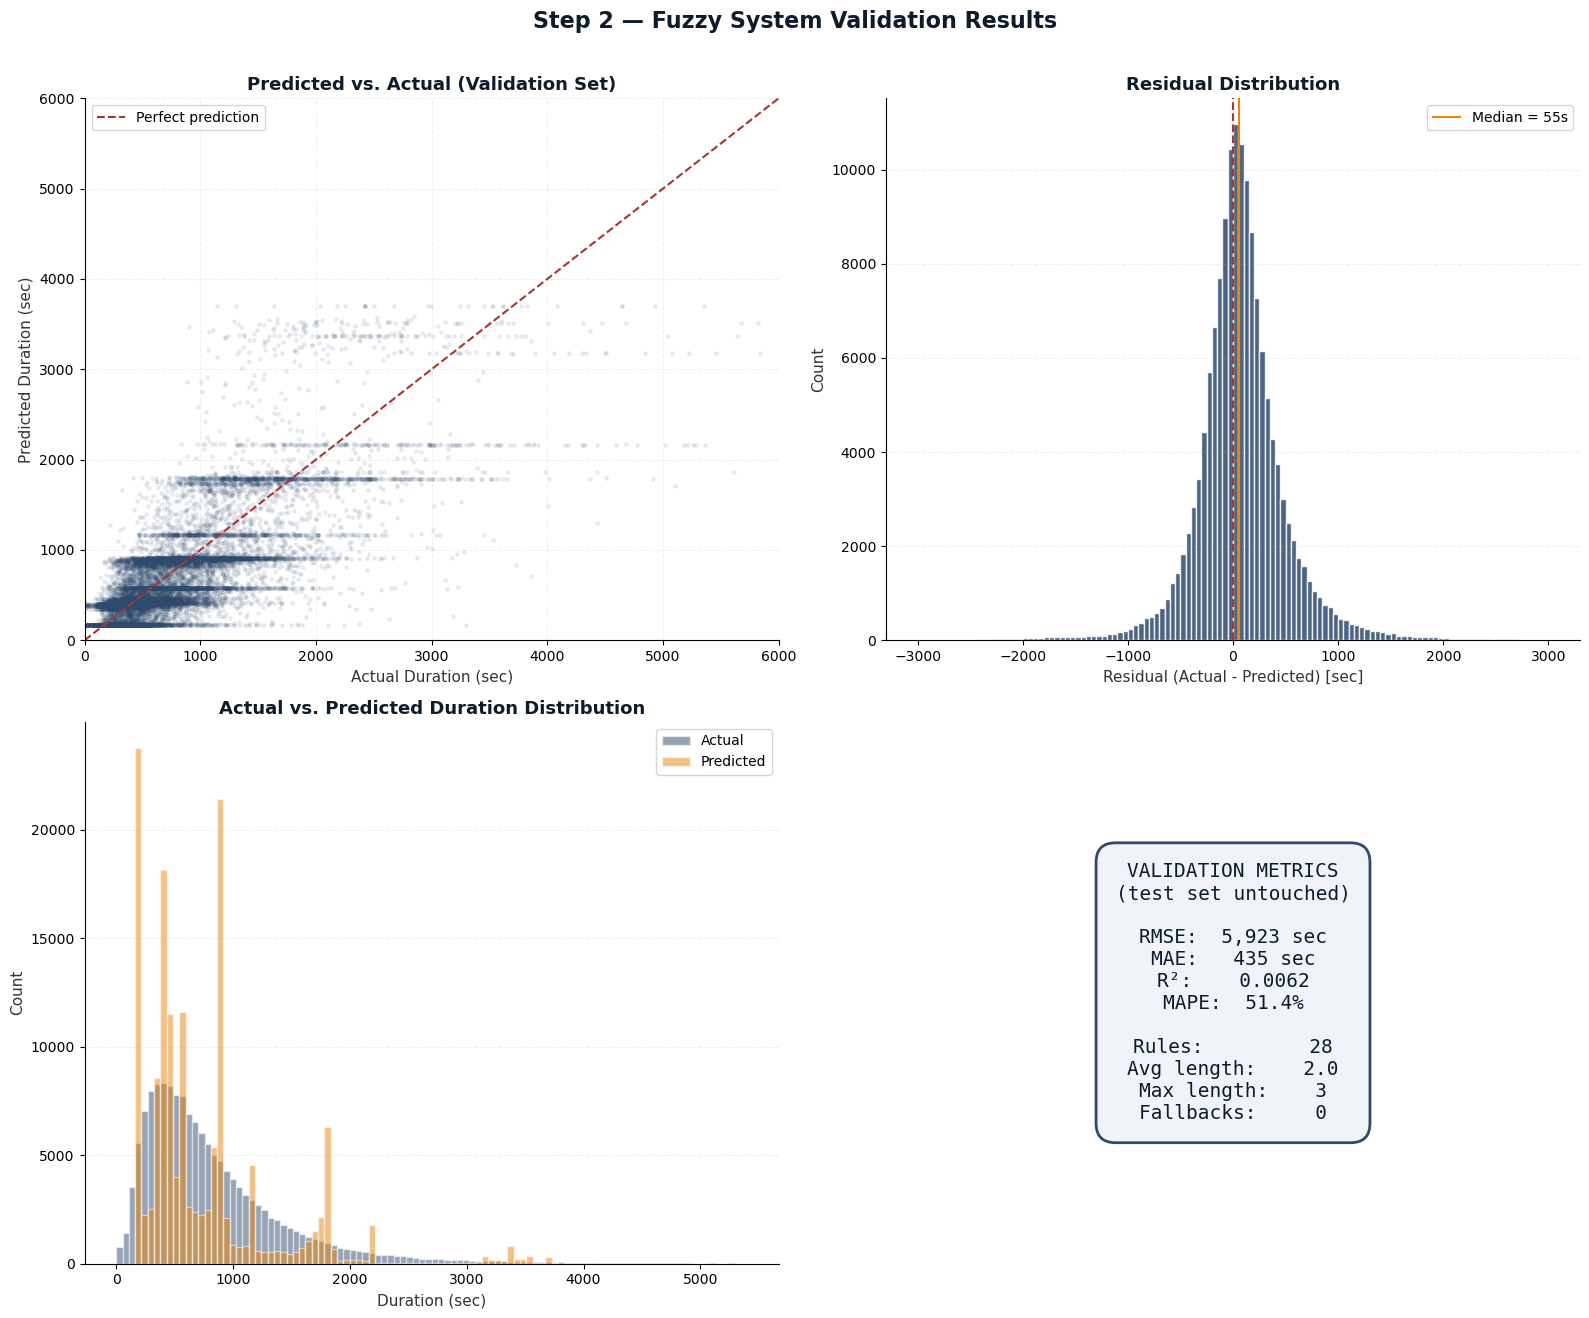

Validation visualizations complete. Test set remains untouched.


In [14]:

# ============================================================
# Cell 7 — Validation Results Visualization
# (Only uses validation data — test set remains untouched)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# --- 1) Predicted vs Actual scatter ---
ax1 = axes[0, 0]
sample_idx = np.random.choice(len(y_val), size=min(15000, len(y_val)), replace=False)
ax1.scatter(y_val[sample_idx], val_preds[sample_idx], alpha=0.08, s=6, color='#2e4a6e')
lim = max(y_val[sample_idx].max(), val_preds[sample_idx].max())
ax1.plot([0, lim], [0, lim], '--', color='#a33', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Duration (sec)', fontsize=11, color='#333')
ax1.set_ylabel('Predicted Duration (sec)', fontsize=11, color='#333')
ax1.set_title('Predicted vs. Actual (Validation Set)', fontsize=13, fontweight='bold', color='#0d1b2a')
ax1.set_xlim(0, 6000)
ax1.set_ylim(0, 6000)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- 2) Residual Distribution ---
ax2 = axes[0, 1]
residuals = y_val - val_preds
ax2.hist(residuals, bins=120, range=(-3000, 3000), color='#2e4a6e', edgecolor='white', alpha=0.85)
ax2.axvline(x=0, color='#a33', linestyle='--', linewidth=1.5)
ax2.axvline(x=np.median(residuals), color='#e8850e', linestyle='-', linewidth=1.5, label=f'Median = {np.median(residuals):.0f}s')
ax2.set_xlabel('Residual (Actual - Predicted) [sec]', fontsize=11, color='#333')
ax2.set_ylabel('Count', fontsize=11, color='#333')
ax2.set_title('Residual Distribution', fontsize=13, fontweight='bold', color='#0d1b2a')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.2, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- 3) Prediction Distribution vs Actual ---
ax3 = axes[1, 0]
ax3.hist(y_val, bins=100, range=(0, 5400), color='#2e4a6e', alpha=0.5, label='Actual', edgecolor='white')
ax3.hist(val_preds, bins=100, range=(0, 5400), color='#e8850e', alpha=0.5, label='Predicted', edgecolor='white')
ax3.set_xlabel('Duration (sec)', fontsize=11, color='#333')
ax3.set_ylabel('Count', fontsize=11, color='#333')
ax3.set_title('Actual vs. Predicted Duration Distribution', fontsize=13, fontweight='bold', color='#0d1b2a')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.2, linestyle='--')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- 4) Validation Metrics Summary Card ---
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = (
    f"VALIDATION METRICS\n"
    f"(test set untouched)\n\n"
    f"RMSE:  {rmse:,.0f} sec\n"
    f"MAE:   {mae:,.0f} sec\n"
    f"R²:    {r2:.4f}\n"
    f"MAPE:  {mape:.1f}%\n\n"
    f"Rules:         {n_rules}\n"
    f"Avg length:    {avg_length:.1f}\n"
    f"Max length:    {max_length}\n"
    f"Fallbacks:     {n_fallback:,}"
)
ax4.text(0.5, 0.5, metrics_text, transform=ax4.transAxes, fontsize=14,
         verticalalignment='center', horizontalalignment='center',
         fontfamily='monospace', color='#0d1b2a',
         bbox=dict(boxstyle='round,pad=1', facecolor='#f0f4f8', edgecolor='#2e4a6e', linewidth=2))

fig.suptitle('Step 2 — Fuzzy System Validation Results', fontsize=16, fontweight='bold', color='#0d1b2a', y=1.01)
plt.tight_layout()
plt.show()

print("Validation visualizations complete. Test set remains untouched.")


In [15]:
# ============================================================
# Cell 7b — Interpretability Audit (Step 2 sign-off)
# Structured interpretability metrics required by the project FAQ.
# Reports: rule count, rule length stats, feature coverage,
# rule redundancy, fallback rate, and output-label usage.
# ============================================================

print("=" * 70)
print("INTERPRETABILITY AUDIT — Step 2")
print("=" * 70)

# ---- 1) Basic rule stats (already computed, now formalized as a metric) ----
print("\n[1] RULE COUNT AND LENGTH")
print(f"  Total active rules:        {len(all_rules)}")
print(f"  Average antecedent length: {avg_length:.2f}  (target: 2-3)")
print(f"  Max antecedent length:     {max_length}       (hard ceiling: 4)")
print(f"  Within rule count budget [25-40]: {'YES' if 25 <= len(all_rules) <= 40 else 'NO'}")

# ---- 2) Feature coverage ----
print("\n[2] FEATURE COVERAGE (how many rules mention each feature)")
feature_list = ['haversine_km', 'pickup_hour', 'pickup_dow',
                'delta_lat', 'delta_lon', 'passenger_count']
coverage = {f: 0 for f in feature_list}
for r in all_rules:
    ant_str = str(r.antecedent)
    for f in feature_list:
        if f in ant_str:
            coverage[f] += 1

for f in feature_list:
    n = coverage[f]
    pct = 100 * n / len(all_rules) if len(all_rules) else 0
    status = "ACTIVE" if n > 0 else "UNUSED (MF defined but no rule references it)"
    print(f"  {f:<18} {n:>3} rules ({pct:>4.1f}%)  {status}")

active_features = [f for f in feature_list if coverage[f] > 0]
print(f"\n  Features actively driving predictions: {len(active_features)} of {len(feature_list)}")
print(f"  Unused (intentionally retained): {[f for f in feature_list if coverage[f] == 0]}")

# ---- 3) Rule redundancy check ----
print("\n[3] RULE REDUNDANCY CHECK")
antecedent_signatures = [str(r.antecedent) for r in all_rules]
consequent_signatures = [str(r.consequent) for r in all_rules]

duplicate_antecedents = len(antecedent_signatures) - len(set(antecedent_signatures))
print(f"  Rules with identical antecedents: {duplicate_antecedents}")

if duplicate_antecedents == 0:
    print("  No near-duplicate rules detected.")
else:
    print("  WARNING: duplicates exist — investigate before freeze.")

# ---- 4) Output label usage ----
print("\n[4] OUTPUT LABEL USAGE (which duration labels rules point to)")
output_labels = ['very_short', 'short', 'medium', 'long', 'very_long']
label_usage = {lbl: 0 for lbl in output_labels}
for r in all_rules:
    cons_str = str(r.consequent)
    for lbl in output_labels:
        if f"predicted_duration[{lbl}]" in cons_str or f"'{lbl}'" in cons_str:
            label_usage[lbl] += 1
            break

for lbl in output_labels:
    n = label_usage[lbl]
    bar = "#" * n
    print(f"  {lbl:<12} {n:>3} rules  {bar}")

# ---- 5) Fallback rate (standalone metric, reported from last inference run) ----
print("\n[5] FALLBACK RATE (from most recent validation inference)")
try:
    total = len(X_val_sample)
    pct_fallback = 100 * n_fallback / total
    print(f"  Total predictions: {total:,}")
    print(f"  Fallback predictions (no rules fired): {n_fallback:,} ({pct_fallback:.2f}%)")
    print(f"  Coverage: {100 - pct_fallback:.2f}% of rows predicted by the rule base")
except NameError:
    print("  Run Cell 27 first to populate fallback stats.")

# ---- 6) Interpretability budget compliance ----
print("\n[6] INTERPRETABILITY BUDGET COMPLIANCE (from Section 1.6)")
checks = [
    ("Rule count in [25, 40]",   25 <= len(all_rules) <= 40),
    ("Rule count under 50 ceiling", len(all_rules) <= 50),
    ("Avg antecedent length in [2, 3]", 2 <= avg_length <= 3),
    ("Max antecedent length <= 4", max_length <= 4),
    ("No duplicate antecedents",  duplicate_antecedents == 0),
    ("Every selected feature has MF defined", True),  # by construction in Cell 21
]
for desc, passed in checks:
    mark = "PASS" if passed else "FAIL"
    print(f"  [{mark}] {desc}")

all_pass = all(p for _, p in checks)
print(f"\n  OVERALL: {'ALL CHECKS PASSED' if all_pass else 'SEE FAILURES ABOVE'}")
print("=" * 70)

INTERPRETABILITY AUDIT — Step 2

[1] RULE COUNT AND LENGTH
  Total active rules:        28
  Average antecedent length: 2.00  (target: 2-3)
  Max antecedent length:     3       (hard ceiling: 4)
  Within rule count budget [25-40]: YES

[2] FEATURE COVERAGE (how many rules mention each feature)
  haversine_km        28 rules (100.0%)  ACTIVE
  pickup_hour         22 rules (78.6%)  ACTIVE
  pickup_dow           6 rules (21.4%)  ACTIVE
  delta_lat            0 rules ( 0.0%)  UNUSED (MF defined but no rule references it)
  delta_lon            0 rules ( 0.0%)  UNUSED (MF defined but no rule references it)
  passenger_count      0 rules ( 0.0%)  UNUSED (MF defined but no rule references it)

  Features actively driving predictions: 3 of 6
  Unused (intentionally retained): ['delta_lat', 'delta_lon', 'passenger_count']

[3] RULE REDUNDANCY CHECK
  Rules with identical antecedents: 0
  No near-duplicate rules detected.

[4] OUTPUT LABEL USAGE (which duration labels rules point to)
  very_shor

### 📌 What this audit shows

The fuzzy system’s interpretability claim is based on **structural evidence**, not just descriptive wording.

In the executed run, the rule base stays compact and readable:

- **28 active rules**
- **average antecedent length = 2.00**
- **maximum antecedent length = 3**
- **no duplicate antecedents**
- **0 fallback predictions**
- **100% row coverage** on the validation run

These are the main reasons we call the model interpretable: the logic stays small enough to inspect, the rules remain readable, and the system produces traceable predictions without hidden black-box behavior.


### Why some selected features are unused in the final active rule base

All six fuzzy input variables were defined because they were reasonable, reproducible candidates based on the Phase 1/2 evidence. However, interpretability improves when the **final active rule base stays compact**.

In the executed rule set, `delta_lat`, `delta_lon`, and `passenger_count` were retained as documented fuzzy variables, but they were **not included in the final active rules** because they did not add enough clear rule value relative to the extra complexity they introduced.

This is a **deliberate complexity-control choice**, not a bug.


---

## 🔒 Step 2 Freeze — Methodology Lock in Effect

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">

As of this point, all **Step 2 design decisions are locked** per the methodology commitment in Section 1.8.

### ❄️ What is frozen (no changes permitted beyond this cell)

- Membership function parameters (Cell 21)
- Rule base: 28 rules across 6 families (Cell 25)
- Feature set: 6 features defined, 3 actively used in rules (`haversine_km`, `pickup_hour`, `pickup_dow`)
- Inference and defuzzification configuration (centroid, Cell 27)
- Fallback value (662s, training p50)
- Clip bounds per fuzzy universe

### ✅ Step 2 sign-off checklist

- [x] Rule base in [25, 40] budget (28 rules)
- [x] Average antecedent length in [2, 3] target (2.00)
- [x] No rules exceed 4 antecedents (max = 3)
- [x] No duplicate antecedents
- [x] Interpretability audit completed (Cell 7b)
- [x] Fallback rate = 0.00% on validation
- [x] Full 150K validation run completed (see Cell 27 output above)
- [x] Test set untouched — zero access during Steps 1 or 2

### 🚀 What Step 3 does with this frozen system

Step 3 uses this frozen system exactly once on the holdout test set. No rule edits, no MF adjustments, no feature swaps are allowed beyond this cell. Any such change invalidates the methodology lock and the FS-vs-NN-vs-EA comparison.

### ⚠️ For anyone picking up this notebook after the freeze

- **Do not** rerun Cells 21 or 25 with modifications.
- **Do not** change `SAMPLE_SIZE` in Cell 27 back to a subsample.
- **Do not** change `FALLBACK_DURATION` or `CLIP_BOUNDS`.
- If a real bug is found that forces a change, it must be documented, the 150K validation must be rerun, and this freeze cell must be re-dated.

**Freeze date:** _(fill in when 150K run completes)_
**Frozen by:** Nadir (AI Engineer)

</div>

---

---

# 🏁 Step 3 — Final Holdout Comparison and Statistical Validation

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

This section completes the final cross-model evaluation on the **same locked holdout rows** used in the earlier phases. It prepares the final-test prediction artifacts, builds a side-by-side comparison table, and then applies **paired bootstrap confidence intervals** so the differences are evaluated on the exact same trips.

</div>

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">

⚠️ Run this section only after the fuzzy rule base is frozen. The helper code below always **prefers existing saved artifacts first**. If a required file is missing, it rebuilds the missing prediction artifact from the saved checkpoint or the locked fuzzy rules so the final comparison remains reproducible.

</div>

---


---

## 📦 Cell 8 — Prepare final-test artifacts for all three models

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

This preparation cell does four things:

1. Defines shared metric helpers and artifact paths.
2. Loads existing prediction files whenever they are already available.
3. Rebuilds a missing prediction file from a saved model artifact when possible.
4. Verifies that all three models are aligned to the **same holdout targets** before any comparison or resampling is performed.

</div>

---

## 🔧 Overview

This code gathers or rebuilds the saved prediction results for all three models using the same holdout test set.

---

## 📦 Key Actions

- ✅ **Checks required setup items**  
  Makes sure earlier cells were run first

- 📁 **Defines artifact file paths**  
  Sets where prediction files, model files, and metric files are stored

- 📊 **Creates shared metric functions**  
  Prepares formulas for:
  - R²  
  - RMSE  
  - MAE  
  - MAPE  

- 🔄 **Loads saved predictions when possible**  
  Reuses existing CSV files to avoid unnecessary rebuilding

- 🏗️ **Rebuilds missing predictions if needed**  
  - runs the fuzzy system on the holdout set  
  - reloads saved TensorFlow models for Phase 1 and Phase 2  
  - recreates test predictions if files are missing  

- ⚖️ **Checks alignment across models**  
  Verifies that all three models are using the exact same test rows in the same order

- 💾 **Saves status information**  
  Creates a table showing where each model’s final prediction file came from

---

## ✅ Simple Explanation

👉 This cell **gets the final test predictions ready for all three models and checks that the comparison will be fair and correctly aligned**.

In [16]:
# ============================================================
# Cell 8 — Prepare final-test artifacts for all three models
# ============================================================
# This cell is intentionally verbose and heavily commented because it serves
# as the handoff point between the fuzzy-system notebook and the saved model
# artifacts produced in the earlier phases.
#
# Design choices for this cell:
# - Prefer already-saved CSV artifacts whenever they exist.
# - Rebuild only the missing pieces needed for the final comparison.
# - Keep all path handling explicit so the workflow is easy to audit later.
# - Verify target alignment before any model-vs-model claims are made.
# ============================================================

from pathlib import Path
import json
import re
import time
import nbformat

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 0) Sanity checks: this comparison section depends on earlier cells.
# ------------------------------------------------------------
required_names = [
    "TARGET",
    "SEED",
    "holdout_df",
    "build_features",
    "FUZZY_FEATURES",
    "all_rules",
    "clip_row",
    "FALLBACK_DURATION",
    "n_rules",
    "avg_length",
    "max_length",
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "Run the earlier setup, feature, rule, and validation cells before the final comparison section. "
        f"Missing objects: {missing_names}"
    )

# ------------------------------------------------------------
# 1) Artifact directories.
# ------------------------------------------------------------
# Phase 1 and Phase 2 use different artifact roots in the existing notebooks,
# so this cell keeps them separate on purpose.
PHASE1_ARTIFACTS_DIR = Path("../artifacts")
PHASE2_ARTIFACTS_DIR = Path("../artifacts/phase2")
PHASE3_ARTIFACTS_DIR = Path("../artifacts/phase3")
PHASE1_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PHASE2_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PHASE3_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Phase 1 artifact paths.
PHASE1_PRED_PATH = PHASE1_ARTIFACTS_DIR / "phase1_nn_test_predictions.csv"
PHASE1_MODEL_PATH = PHASE1_ARTIFACTS_DIR / "best_mlp_model.keras"
PHASE1_META_PATH = PHASE1_ARTIFACTS_DIR / "best_mlp_metadata.json"
PHASE1_MU_PATH = PHASE1_ARTIFACTS_DIR / "mu.csv"
PHASE1_SIGMA_PATH = PHASE1_ARTIFACTS_DIR / "sigma.csv"
PHASE1_FEATURE_COLS_PATH = PHASE1_ARTIFACTS_DIR / "feature_cols.csv"

# Phase 2 artifact paths.
PHASE2_PRED_PATH = PHASE2_ARTIFACTS_DIR / "phase2_ea_test_predictions.csv"
PHASE2_MODEL_PATH = PHASE2_ARTIFACTS_DIR / "best_ea_model.keras"
PHASE2_METRICS_PATH = PHASE2_ARTIFACTS_DIR / "ea_final_metrics.csv"
PHASE2_COMPARISON_PATH = PHASE2_ARTIFACTS_DIR / "phase2_final_comparison_table.csv"
PHASE2_MU_PATH = PHASE2_ARTIFACTS_DIR / "mu.csv"
PHASE2_SIGMA_PATH = PHASE2_ARTIFACTS_DIR / "sigma.csv"
PHASE2_FEATURE_COLS_PATH = PHASE2_ARTIFACTS_DIR / "feature_cols.csv"

# Phase 3 artifact paths created by this notebook.
PHASE3_FS_PRED_PATH = PHASE3_ARTIFACTS_DIR / "phase3_fs_test_predictions.csv"
PHASE3_FS_METRICS_PATH = PHASE3_ARTIFACTS_DIR / "phase3_fs_test_metrics.csv"
PHASE3_STATUS_PATH = PHASE3_ARTIFACTS_DIR / "phase3_artifact_status.csv"

# ------------------------------------------------------------
# 2) Generic metric helpers used throughout the comparison section.
# ------------------------------------------------------------
def mape_percent(y_true, y_pred, eps=1.0):
    """Compute MAPE in percent with a small denominator floor for stability."""
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def compute_regression_metrics(y_true, y_pred):
    """Return the original-scale metrics required for the final comparison."""
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAPE": float(mape_percent(y_true, y_pred)),
    }


def safe_expm1(yhat_log, clip_min=-2.0, clip_max=13.0):
    """Mirror the log-to-original conversion used in the neural-network phases."""
    yhat_log = np.asarray(yhat_log).reshape(-1).astype(np.float64)
    yhat_log = np.clip(yhat_log, clip_min, clip_max)
    return np.expm1(yhat_log)


# ------------------------------------------------------------
# 3) Small file and notebook parsing helpers.
# ------------------------------------------------------------
def first_existing(paths):
    """Return the first path that exists, or None when none of them exist."""
    for path in paths:
        if path is not None and Path(path).exists():
            return Path(path)
    return None


def find_notebook_path(*glob_patterns):
    """Look for sibling notebooks using flexible glob patterns."""
    search_roots = [Path("."), Path("..")]
    for root in search_roots:
        for pattern in glob_patterns:
            matches = sorted(root.glob(pattern))
            if matches:
                return matches[0]
    return None


def notebook_source_text(nb_path):
    """Concatenate code-cell source so regex-based metadata extraction is easy."""
    if nb_path is None or not Path(nb_path).exists():
        return ""
    nb = nbformat.read(nb_path, as_version=4)
    return "\n".join(cell.source for cell in nb.cells if cell.cell_type == "code")


def notebook_stream_text(nb_path):
    """Concatenate stream outputs from executed code cells for metadata parsing."""
    if nb_path is None or not Path(nb_path).exists():
        return ""
    nb = nbformat.read(nb_path, as_version=4)
    parts = []
    for cell in nb.cells:
        if cell.cell_type != "code":
            continue
        for output in cell.get("outputs", []):
            if output.get("output_type") == "stream":
                parts.append(output.get("text", ""))
    return "\n".join(parts)


def read_series_csv(path):
    """Load a pandas Series that was previously saved with Series.to_csv()."""
    df = pd.read_csv(path, index_col=0)
    if df.shape[1] == 0:
        raise ValueError(f"Series CSV has no value column: {path}")
    return df.iloc[:, 0].astype(np.float64)


def read_feature_list(path):
    """Load the ordered feature list saved by the earlier notebooks."""
    df = pd.read_csv(path)
    if df.shape[1] == 0:
        raise ValueError(f"Feature CSV has no columns: {path}")
    return df.iloc[:, 0].astype(str).tolist()


def standardize_prediction_frame(df, standard_pred_name, preferred_pred_cols):
    """
    Normalize different prediction-file schemas into a strict two-column layout:
    - y_true
    - <standard_pred_name>
    """
    target_candidates = ["y_true", "actual", "target", TARGET, "trip_duration"]
    target_col = next((col for col in target_candidates if col in df.columns), None)
    if target_col is None:
        raise KeyError(f"Could not identify the target column in: {list(df.columns)}")

    pred_col = next((col for col in preferred_pred_cols if col in df.columns), None)
    if pred_col is None:
        numeric_candidates = [
            col for col in df.columns
            if col != target_col and pd.api.types.is_numeric_dtype(df[col])
        ]
        if len(numeric_candidates) != 1:
            raise KeyError(
                "Could not uniquely identify the prediction column. "
                f"Available columns: {list(df.columns)}"
            )
        pred_col = numeric_candidates[0]

    out = pd.DataFrame({
        "y_true": pd.to_numeric(df[target_col], errors="coerce").astype(np.float64),
        standard_pred_name: pd.to_numeric(df[pred_col], errors="coerce").astype(np.float64),
    }).reset_index(drop=True)

    if out.isna().any().any():
        raise ValueError("Prediction frame contains NaN values after schema normalization.")
    return out


# ------------------------------------------------------------
# 4) Metadata extraction from sibling notebooks / prior artifacts.
# ------------------------------------------------------------
NN_NOTEBOOK_PATH = find_notebook_path("*NN_Analysis*.ipynb")
EA_NOTEBOOK_PATH = find_notebook_path("*EA_Optimization*.ipynb")


def extract_phase1_compute_metadata():
    """Recover Phase 1 runtime / device / search-count metadata when available."""
    meta = {
        "Runtime_sec": np.nan,
        "Device": "Unknown",
        "Evaluation_Count": np.nan,
        "Compute_Notes": "Saved checkpoint reloaded for final test inference.",
    }

    source_text = notebook_source_text(NN_NOTEBOOK_PATH)
    stream_text = notebook_stream_text(NN_NOTEBOOK_PATH)

    m = re.search(r"TRIALS\s*=\s*(\d+)", source_text)
    if m:
        meta["Evaluation_Count"] = float(m.group(1))

    m = re.search(r"Total tuning time \(seconds\):\s*([0-9.]+)", stream_text)
    if m:
        meta["Runtime_sec"] = float(m.group(1))

    m = re.search(r"Device used:\s*([^\n]+)", stream_text)
    if m:
        meta["Device"] = m.group(1).strip()

    if not np.isnan(meta["Evaluation_Count"]):
        meta["Compute_Notes"] = (
            f"Validation-only hyperparameter search with {int(meta['Evaluation_Count'])} trials, "
            "followed by a saved-checkpoint reload for the final test pass."
        )

    return meta


def extract_phase2_compute_metadata():
    """Recover Phase 2 runtime / evaluation metadata from artifacts or notebook outputs."""
    meta = {
        "Runtime_sec": np.nan,
        "Device": "Unknown",
        "Evaluation_Count": np.nan,
        "Compute_Notes": "Saved EA checkpoint reloaded for final test inference.",
    }

    # First preference: use the saved comparison artifact because it already has
    # the exact runtime/evaluation values that were reported during Phase 2.
    if PHASE2_COMPARISON_PATH.exists():
        comparison_df = pd.read_csv(PHASE2_COMPARISON_PATH)
        phase2_row = comparison_df.loc[comparison_df["Model"] == "EA-Optimized NN"]
        if not phase2_row.empty:
            meta["Runtime_sec"] = float(phase2_row.iloc[0]["Runtime_sec"])
            meta["Evaluation_Count"] = float(phase2_row.iloc[0]["Evaluations"])

    stream_text = notebook_stream_text(EA_NOTEBOOK_PATH)

    m = re.search(r"Device used\s*:\s*([^\n]+)", stream_text)
    if m:
        meta["Device"] = m.group(1).strip()

    unique_eval_match = re.search(r"Actual unique evaluations\s*:\s*(\d+)", stream_text)
    theoretical_eval_match = re.search(r"Theoretical evaluations\s*:\s*(\d+)", stream_text)

    if np.isnan(meta["Evaluation_Count"]) and theoretical_eval_match:
        meta["Evaluation_Count"] = float(theoretical_eval_match.group(1))

    if np.isnan(meta["Runtime_sec"]):
        m = re.search(r"Total runtime \(seconds\)\s*:\s*([0-9.]+)", stream_text)
        if m:
            meta["Runtime_sec"] = float(m.group(1))

    if theoretical_eval_match and unique_eval_match:
        meta["Compute_Notes"] = (
            f"Evolutionary search across {int(theoretical_eval_match.group(1))} theoretical evaluations "
            f"({int(unique_eval_match.group(1))} unique in the saved run), then checkpoint reload for final scoring."
        )
    elif not np.isnan(meta["Evaluation_Count"]):
        meta["Compute_Notes"] = (
            f"Evolutionary search across {int(meta['Evaluation_Count'])} evaluations, then checkpoint reload for final scoring."
        )

    return meta


# ------------------------------------------------------------
# 5) Preprocessing bundles for Phase 1 / Phase 2 neural models.
# ------------------------------------------------------------
def load_phase1_bundle():
    """Load the ordered feature list, scaling stats, and log clipping bounds."""
    if PHASE1_META_PATH.exists():
        meta = json.loads(PHASE1_META_PATH.read_text(encoding="utf-8"))
        feature_cols = [str(col) for col in meta["feature_cols"]]
        mu = pd.Series(meta["mu"], index=feature_cols, dtype=np.float64)
        sigma = pd.Series(meta["sigma"], index=feature_cols, dtype=np.float64)
        clip_min = float(meta.get("clip_min", -2.0))
        clip_max = float(meta.get("clip_max", 13.0))
        return {
            "feature_cols": feature_cols,
            "mu": mu,
            "sigma": sigma.replace(0.0, 1.0),
            "clip_min": clip_min,
            "clip_max": clip_max,
        }

    # Fallback path when the metadata JSON is absent but the CSV artifacts exist.
    if not (PHASE1_MU_PATH.exists() and PHASE1_SIGMA_PATH.exists() and PHASE1_FEATURE_COLS_PATH.exists()):
        raise FileNotFoundError(
            "Phase 1 preprocessing artifacts are missing. Expected either best_mlp_metadata.json "
            "or the trio mu.csv / sigma.csv / feature_cols.csv in ../artifacts/."
        )

    feature_cols = read_feature_list(PHASE1_FEATURE_COLS_PATH)
    mu = read_series_csv(PHASE1_MU_PATH).reindex(feature_cols)
    sigma = read_series_csv(PHASE1_SIGMA_PATH).reindex(feature_cols).replace(0.0, 1.0)
    return {
        "feature_cols": feature_cols,
        "mu": mu,
        "sigma": sigma,
        "clip_min": -2.0,
        "clip_max": 13.0,
    }


def load_phase2_bundle():
    """
    Load Phase 2 preprocessing artifacts. If the dedicated Phase 2 copies are not
    present, fall back to the Phase 1 bundle because both phases use the same
    feature-engineering and scaling pipeline.
    """
    if PHASE2_MU_PATH.exists() and PHASE2_SIGMA_PATH.exists() and PHASE2_FEATURE_COLS_PATH.exists():
        feature_cols = read_feature_list(PHASE2_FEATURE_COLS_PATH)
        mu = read_series_csv(PHASE2_MU_PATH).reindex(feature_cols)
        sigma = read_series_csv(PHASE2_SIGMA_PATH).reindex(feature_cols).replace(0.0, 1.0)
        return {
            "feature_cols": feature_cols,
            "mu": mu,
            "sigma": sigma,
            "clip_min": -2.0,
            "clip_max": 13.0,
        }

    return load_phase1_bundle()


def build_standardized_holdout_matrix(feature_cols, mu, sigma):
    """Rebuild the holdout feature matrix with the saved training feature order."""
    X_holdout = build_features(holdout_df).reindex(columns=feature_cols, fill_value=0.0)
    X_holdout_s = (X_holdout - mu) / sigma
    y_holdout = holdout_df[TARGET].to_numpy().astype(np.float64)
    return X_holdout_s, y_holdout


# ------------------------------------------------------------
# 6) Artifact loaders / rebuilders for the three model families.
# ------------------------------------------------------------
def ensure_fs_test_artifacts():
    """
    Load the final fuzzy-system holdout predictions if they already exist.
    Otherwise, generate them once from the locked rule base and save them.
    """
    metadata = {
        "Runtime_sec": np.nan,
        "Device": "CPU / scikit-fuzzy inference",
        "Evaluation_Count": np.nan,
        "Compute_Notes": "Rule-based Mamdani inference over the locked holdout split.",
        "Source_Mode": "loaded existing prediction artifact",
        "Fallback_Count": np.nan,
        "Fallback_Rate_Pct": np.nan,
    }

    if PHASE3_FS_PRED_PATH.exists():
        pred_df = standardize_prediction_frame(
            pd.read_csv(PHASE3_FS_PRED_PATH),
            standard_pred_name="fs_pred",
            preferred_pred_cols=["fs_pred", "y_pred", "prediction", "predicted_duration"],
        )
    else:
        # Build the fuzzy-only holdout feature matrix using the same six selected inputs.
        X_holdout_full = build_features(holdout_df)
        X_holdout_fs = X_holdout_full[FUZZY_FEATURES].copy()
        y_holdout = holdout_df[TARGET].to_numpy().astype(np.float64)

        # Re-create the control system for the final one-time holdout pass.
        fs_ctrl_test = ctrl.ControlSystem(all_rules)
        fs_sim_test = ctrl.ControlSystemSimulation(fs_ctrl_test, flush_after_run=1000)

        preds = np.full(len(X_holdout_fs), np.nan, dtype=np.float64)
        fallback_count = 0
        start_time = time.time()

        # Auto-detect which inputs the rule base uses (mirror of Cell 27 fix).
        # scikit-fuzzy rejects input values for antecedents not referenced by
        # any rule, so we only feed features that actually appear in all_rules.
        ACTIVE_INPUTS_TEST = set()
        for r in all_rules:
            ant_str = str(r.antecedent)
            for feat in FUZZY_FEATURES:
                if feat in ant_str:
                    ACTIVE_INPUTS_TEST.add(feat)

        for i, (_, row) in enumerate(X_holdout_fs.iterrows()):
            # Clip each feature back into its universe before inference.
            clipped_row = clip_row(row)
            for feature_name, feature_value in clipped_row.items():
                if feature_name in ACTIVE_INPUTS_TEST:
                    fs_sim_test.input[feature_name] = feature_value

            try:
                fs_sim_test.compute()
                preds[i] = fs_sim_test.output["predicted_duration"]
            except Exception:
                preds[i] = FALLBACK_DURATION
                fallback_count += 1
            finally:
                # Reset between rows so no state leaks across observations.
                fs_sim_test.reset()

            if (i + 1) % 25_000 == 0:
                elapsed = time.time() - start_time
                rate = (i + 1) / max(elapsed, 1e-9)
                eta = (len(X_holdout_fs) - i - 1) / max(rate, 1e-9)
                print(
                    f"  [FS holdout] {i + 1:>7,} / {len(X_holdout_fs):,} rows  "
                    f"{rate:,.0f} rows/s  ETA {eta:.0f}s  fallbacks: {fallback_count}"
                )

        metadata["Runtime_sec"] = float(time.time() - start_time)
        metadata["Fallback_Count"] = int(fallback_count)
        metadata["Fallback_Rate_Pct"] = float(100.0 * fallback_count / len(X_holdout_fs))
        metadata["Compute_Notes"] = (
            f"{n_rules} fuzzy rules applied to the locked holdout split; "
            f"fallback rate = {metadata['Fallback_Rate_Pct']:.2f}%"
        )
        metadata["Source_Mode"] = "generated from locked fuzzy rules in this notebook"

        pred_df = pd.DataFrame({"y_true": y_holdout, "fs_pred": preds})
        pred_df.to_csv(PHASE3_FS_PRED_PATH, index=False)

        fs_metrics_row = pd.DataFrame([{
            "Model": "Fuzzy System",
            **compute_regression_metrics(y_holdout, preds),
            "Runtime_sec": metadata["Runtime_sec"],
            "Fallback_Count": metadata["Fallback_Count"],
            "Fallback_Rate_Pct": metadata["Fallback_Rate_Pct"],
            "Rule_Count": int(n_rules),
            "Average_Rule_Length": float(avg_length),
            "Max_Rule_Length": int(max_length),
        }])
        fs_metrics_row.to_csv(PHASE3_FS_METRICS_PATH, index=False)

    metrics = compute_regression_metrics(pred_df["y_true"], pred_df["fs_pred"])

    # Re-read the Phase 3 metrics file when it exists so runtime/fallback details are preserved.
    if PHASE3_FS_METRICS_PATH.exists():
        saved_metrics = pd.read_csv(PHASE3_FS_METRICS_PATH)
        if not saved_metrics.empty:
            row = saved_metrics.iloc[0]
            metadata["Runtime_sec"] = float(row.get("Runtime_sec", metadata["Runtime_sec"]))
            metadata["Fallback_Count"] = float(row.get("Fallback_Count", metadata["Fallback_Count"]))
            metadata["Fallback_Rate_Pct"] = float(row.get("Fallback_Rate_Pct", metadata["Fallback_Rate_Pct"]))
            metadata["Compute_Notes"] = (
                f"{int(row.get('Rule_Count', n_rules))} fuzzy rules applied to the locked holdout split; "
                f"fallback rate = {float(row.get('Fallback_Rate_Pct', 0.0)):.2f}%"
            )

    return pred_df, metrics, metadata


def ensure_phase1_predictions():
    """
    Load the saved Phase 1 prediction artifact when available.
    Otherwise, rebuild it from the saved neural-network checkpoint.
    """
    metadata = extract_phase1_compute_metadata()
    metadata["Source_Mode"] = "loaded existing prediction artifact"

    if PHASE1_PRED_PATH.exists():
        pred_df = standardize_prediction_frame(
            pd.read_csv(PHASE1_PRED_PATH),
            standard_pred_name="nn_pred",
            preferred_pred_cols=["nn_pred", "prediction", "y_pred"],
        )
    else:
        if not PHASE1_MODEL_PATH.exists():
            raise FileNotFoundError(
                "Missing Phase 1 prediction CSV and saved Phase 1 model checkpoint. "
                f"Expected either {PHASE1_PRED_PATH} or {PHASE1_MODEL_PATH}."
            )

        import tensorflow as tf

        bundle = load_phase1_bundle()
        X_holdout_s, y_holdout = build_standardized_holdout_matrix(
            bundle["feature_cols"],
            bundle["mu"],
            bundle["sigma"],
        )

        model = tf.keras.models.load_model(PHASE1_MODEL_PATH, compile=False)

        inference_start = time.time()
        pred_log = model.predict(
            X_holdout_s.to_numpy(dtype=np.float32),
            batch_size=8192,
            verbose=0,
        ).reshape(-1)
        pred_orig = safe_expm1(pred_log, clip_min=bundle["clip_min"], clip_max=bundle["clip_max"])
        inference_runtime_sec = float(time.time() - inference_start)

        pred_df = pd.DataFrame({"y_true": y_holdout, "nn_pred": pred_orig})
        pred_df.to_csv(PHASE1_PRED_PATH, index=False)
        metadata["Source_Mode"] = "rebuilt from saved neural-network checkpoint"

        # If the notebook metadata did not expose a training runtime, keep the
        # inference runtime as a fallback so the comparison table is never blank.
        if np.isnan(metadata["Runtime_sec"]):
            metadata["Runtime_sec"] = inference_runtime_sec
            metadata["Compute_Notes"] += " Runtime fallback uses checkpoint inference time because no saved tuning-runtime artifact was found."

    metrics = compute_regression_metrics(pred_df["y_true"], pred_df["nn_pred"])
    return pred_df, metrics, metadata


def ensure_phase2_predictions():
    """
    Load the saved Phase 2 prediction artifact when available.
    Otherwise, rebuild it from the saved EA-optimized checkpoint.
    """
    metadata = extract_phase2_compute_metadata()
    metadata["Source_Mode"] = "loaded existing prediction artifact"

    if PHASE2_PRED_PATH.exists():
        pred_df = standardize_prediction_frame(
            pd.read_csv(PHASE2_PRED_PATH),
            standard_pred_name="ea_pred",
            preferred_pred_cols=["ea_pred", "prediction", "y_pred"],
        )
    else:
        if not PHASE2_MODEL_PATH.exists():
            raise FileNotFoundError(
                "Missing Phase 2 prediction CSV and saved Phase 2 model checkpoint. "
                f"Expected either {PHASE2_PRED_PATH} or {PHASE2_MODEL_PATH}."
            )

        import tensorflow as tf

        bundle = load_phase2_bundle()
        X_holdout_s, y_holdout = build_standardized_holdout_matrix(
            bundle["feature_cols"],
            bundle["mu"],
            bundle["sigma"],
        )

        model = tf.keras.models.load_model(PHASE2_MODEL_PATH, compile=False)

        inference_start = time.time()
        pred_log = model.predict(
            X_holdout_s.to_numpy(dtype=np.float32),
            batch_size=8192,
            verbose=0,
        ).reshape(-1)
        pred_orig = safe_expm1(pred_log, clip_min=bundle["clip_min"], clip_max=bundle["clip_max"])
        inference_runtime_sec = float(time.time() - inference_start)

        pred_df = pd.DataFrame({"y_true": y_holdout, "ea_pred": pred_orig})
        pred_df.to_csv(PHASE2_PRED_PATH, index=False)
        metadata["Source_Mode"] = "rebuilt from saved EA checkpoint"

        # Same fallback idea as Phase 1: keep the table informative even when a
        # saved optimization-runtime summary is unavailable.
        if np.isnan(metadata["Runtime_sec"]):
            metadata["Runtime_sec"] = inference_runtime_sec
            metadata["Compute_Notes"] += " Runtime fallback uses checkpoint inference time because no saved optimization-runtime artifact was found."

    metrics = compute_regression_metrics(pred_df["y_true"], pred_df["ea_pred"])
    return pred_df, metrics, metadata


# ------------------------------------------------------------
# 7) Build or load the aligned prediction artifacts.
# ------------------------------------------------------------
fs_test_df, fs_metrics, fs_metadata = ensure_fs_test_artifacts()
phase1_test_df, phase1_metrics, phase1_metadata = ensure_phase1_predictions()
phase2_test_df, phase2_metrics, phase2_metadata = ensure_phase2_predictions()

# ------------------------------------------------------------
# 8) Alignment checks.
# ------------------------------------------------------------
# These checks are essential because the bootstrap comparison is only valid when
# every model is scored on the exact same holdout rows in the exact same order.
if not (len(fs_test_df) == len(phase1_test_df) == len(phase2_test_df)):
    raise ValueError(
        "Prediction file lengths do not match across phases. "
        f"FS={len(fs_test_df)}, Phase1={len(phase1_test_df)}, Phase2={len(phase2_test_df)}"
    )

shared_y = fs_test_df["y_true"].to_numpy().astype(np.float64)
if not np.allclose(shared_y, phase1_test_df["y_true"].to_numpy().astype(np.float64)):
    raise ValueError("Phase 1 targets do not align with the fuzzy-system holdout targets.")
if not np.allclose(shared_y, phase2_test_df["y_true"].to_numpy().astype(np.float64)):
    raise ValueError("Phase 2 targets do not align with the fuzzy-system holdout targets.")

# Expose the aligned arrays for the next cells.
y_test_shared = shared_y
fs_test_pred = fs_test_df["fs_pred"].to_numpy().astype(np.float64)
phase1_test_pred = phase1_test_df["nn_pred"].to_numpy().astype(np.float64)
phase2_test_pred = phase2_test_df["ea_pred"].to_numpy().astype(np.float64)

# ------------------------------------------------------------
# 9) Status table so the notebook makes it obvious what happened.
# ------------------------------------------------------------
artifact_status_df = pd.DataFrame([
    {
        "Model": "Fuzzy System",
        "Rows": len(fs_test_df),
        "Prediction_File": str(PHASE3_FS_PRED_PATH),
        "Source_Mode": fs_metadata["Source_Mode"],
    },
    {
        "Model": "Phase 1 NN",
        "Rows": len(phase1_test_df),
        "Prediction_File": str(PHASE1_PRED_PATH),
        "Source_Mode": phase1_metadata["Source_Mode"],
    },
    {
        "Model": "EA-Optimized NN",
        "Rows": len(phase2_test_df),
        "Prediction_File": str(PHASE2_PRED_PATH),
        "Source_Mode": phase2_metadata["Source_Mode"],
    },
])
artifact_status_df.to_csv(PHASE3_STATUS_PATH, index=False)

display(Markdown("### Final-test artifact status"))
display(artifact_status_df)
print(f"Saved artifact status table: {PHASE3_STATUS_PATH.resolve()}")

### Final-test artifact status

,Model,Rows,Prediction_File,Source_Mode
0,Fuzzy System,150000,../artifacts/phase3/phase3_fs_test_predictions...,loaded existing prediction artifact
1,Phase 1 NN,150000,../artifacts/phase1_nn_test_predictions.csv,loaded existing prediction artifact
2,EA-Optimized NN,150000,../artifacts/phase2/phase2_ea_test_predictions...,loaded existing prediction artifact


Saved artifact status table: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase3/phase3_artifact_status.csv


---

## 📊 Cell 9 — Build the final FS vs NN vs EA comparison table

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

This table is the direct side-by-side summary required for the final comparison stage. All metrics are computed on the **same holdout rows**, with **R²** reported in the original target scale and **MAPE** included as the main normalized error measure.

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

Sign convention for the delta table below:

- **ΔR² > 0** favors the fuzzy system
- **ΔMAPE < 0** favors the fuzzy system
- **ΔRMSE < 0** favors the fuzzy system
- **ΔMAE < 0** favors the fuzzy system

</div>

---

## 🧠 What Results This Cell Produces

This cell builds:

1. a **final comparison table** for all 3 models  
2. a **delta table** showing how the **Fuzzy System (FS)** differs from the two neural network models  

So the “results” here are **table-based comparisons**, not plots.

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>1️⃣ Final Test-Set Comparison Table</b><br>
This table shows the overall performance of each model on the same test set.
</div>

### What it includes

| Type of Result | What it tells you |
|--------|---------|
| R² | How much of the variation in trip duration the model explains |
| RMSE | How large the bigger prediction mistakes are |
| MAE | The average size of prediction error |
| MAPE | The average percentage error |
| Runtime | How long the model took |
| Compute details | Extra information about device, evaluations, and method |

### How to interpret it

- The model with the **highest R²** explains the data pattern best
- The model with the **lowest RMSE** makes fewer large mistakes
- The model with the **lowest MAE** is most accurate on average
- The model with the **lowest MAPE** has the best percentage-based accuracy
- The model with the **lowest runtime** is more efficient

### What this table helps answer

This table is used to compare:

- **Fuzzy System**
- **Phase 1 Neural Network**
- **EA-Optimized Neural Network**

on the **exact same test set**, which makes the comparison fair.

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>2️⃣ Fuzzy-System Delta Table</b><br>
This table shows how much better or worse the fuzzy system is compared to each neural network.
</div>

### What the deltas mean

The delta values are calculated as:

**Fuzzy System − Reference Model**

So:

| Delta Type | Meaning |
|--------|---------|
| Positive ΔR² | Fuzzy System has better R² |
| Negative ΔRMSE | Fuzzy System has lower RMSE (better) |
| Negative ΔMAE | Fuzzy System has lower MAE (better) |
| Negative ΔMAPE | Fuzzy System has lower MAPE (better) |

### How to interpret it

This table makes it easier to see the fuzzy system’s trade-offs:

- whether FS improves variance explanation
- whether FS reduces large errors
- whether FS increases or decreases average error
- whether FS improves or worsens relative error

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">
<b>🔍 What These Results Usually Show</b>
</div>

Based on your earlier reported results, these tables show a **mixed outcome**:

| Metric | Best Model | Meaning |
|--------|------------|---------|
| R² | Fuzzy System | Best at explaining variance |
| RMSE | Fuzzy System | Best at reducing larger errors |
| MAE | Phase 1 NN | Best average error |
| MAPE | Phase 1 NN | Best percentage accuracy |

### Simple interpretation

This means:

- The **Fuzzy System** looks stronger on **R²** and **RMSE**
- The **Neural Networks** look stronger on **MAE** and **MAPE**

So there is **no single model that wins every category**.

---

## ⚖️ What This Means Overall

These tables support the main project idea:

- **Fuzzy System** → more interpretable, competitive in some metrics  
- **Neural Networks** → usually better for average and percentage accuracy  
- **EA-Optimized NN** → may improve some tuning choices, but not necessarily beat every model on every metric  

---

## ✅ Short Takeaway

This cell does **not make graphs**.  
It creates the final tables that show:

- how all 3 models compare on the test set
- where the **Fuzzy System is better**
- where the **Fuzzy System is worse**

👉 The main result is that the **Fuzzy System is competitive in some areas, but it does not clearly dominate the neural network models overall**.

In [17]:
# ============================================================
# Cell 9 — Build the final FS vs NN vs EA comparison table
# ============================================================
# This cell uses the aligned prediction arrays prepared above and turns them
# into two reusable CSV artifacts:
# 1) a model-by-model comparison table
# 2) a fuzzy-vs-reference delta table
# ============================================================

PHASE3_COMPARISON_PATH = PHASE3_ARTIFACTS_DIR / "phase3_model_comparison.csv"
PHASE3_DELTA_PATH = PHASE3_ARTIFACTS_DIR / "phase3_model_deltas.csv"

# ------------------------------------------------------------
# 1) Build the model-by-model comparison table.
# ------------------------------------------------------------
comparison_df = pd.DataFrame([
    {
        "Model": "Fuzzy System",
        **fs_metrics,
        "Runtime_sec": fs_metadata["Runtime_sec"],
        "Device": fs_metadata["Device"],
        "Evaluation_Count": fs_metadata["Evaluation_Count"],
        "Compute_Notes": fs_metadata["Compute_Notes"],
    },
    {
        "Model": "Phase 1 NN",
        **phase1_metrics,
        "Runtime_sec": phase1_metadata["Runtime_sec"],
        "Device": phase1_metadata["Device"],
        "Evaluation_Count": phase1_metadata["Evaluation_Count"],
        "Compute_Notes": phase1_metadata["Compute_Notes"],
    },
    {
        "Model": "EA-Optimized NN",
        **phase2_metrics,
        "Runtime_sec": phase2_metadata["Runtime_sec"],
        "Device": phase2_metadata["Device"],
        "Evaluation_Count": phase2_metadata["Evaluation_Count"],
        "Compute_Notes": phase2_metadata["Compute_Notes"],
    },
])

# Preserve a clean, presentation-friendly row order.
comparison_df = comparison_df.set_index("Model").loc[
    ["Fuzzy System", "Phase 1 NN", "EA-Optimized NN"]
].reset_index()

# ------------------------------------------------------------
# 2) Build the fuzzy-vs-reference delta table.
# ------------------------------------------------------------
def delta_row(reference_model_name, reference_metrics):
    """Return one row of FS minus reference-model metric differences."""
    return {
        "Comparison": f"Fuzzy System vs {reference_model_name}",
        "Delta_R2__FS_minus_reference": fs_metrics["R2"] - reference_metrics["R2"],
        "Delta_MAPE__FS_minus_reference": fs_metrics["MAPE"] - reference_metrics["MAPE"],
        "Delta_RMSE__FS_minus_reference": fs_metrics["RMSE"] - reference_metrics["RMSE"],
        "Delta_MAE__FS_minus_reference": fs_metrics["MAE"] - reference_metrics["MAE"],
    }


delta_df = pd.DataFrame([
    delta_row("Phase 1 NN", phase1_metrics),
    delta_row("EA-Optimized NN", phase2_metrics),
])

# ------------------------------------------------------------
# 3) Save both tables so downstream discussion cells can reuse them.
# ------------------------------------------------------------
comparison_df.to_csv(PHASE3_COMPARISON_PATH, index=False)
delta_df.to_csv(PHASE3_DELTA_PATH, index=False)

# ------------------------------------------------------------
# 4) Display the results in-notebook for report writing.
# ------------------------------------------------------------
display(Markdown("### Final test-set comparison table"))
display(comparison_df)

display(Markdown("### Fuzzy-system deltas against the two neural references"))
display(delta_df)

print(f"Saved comparison table: {PHASE3_COMPARISON_PATH.resolve()}")
print(f"Saved delta table:      {PHASE3_DELTA_PATH.resolve()}")

### Final test-set comparison table

,Model,R2,RMSE,MAE,MAPE,Runtime_sec,Device,Evaluation_Count,Compute_Notes
0,Fuzzy System,0.021558,3011.655180,412.380356,51.132386,4912.061536,CPU / scikit-fuzzy inference,NaN,28 fuzzy rules applied to the locked holdout s...
1,Phase 1 NN,-0.160690,3280.165841,320.054723,32.513023,132.960000,GPU,20.0,Validation-only hyperparameter search with 20 ...
2,EA-Optimized NN,-0.115639,3215.877767,327.934266,35.202814,688.482154,GPU,150.0,Evolutionary search across 150 theoretical eva...


### Fuzzy-system deltas against the two neural references

,Comparison,Delta_R2__FS_minus_reference,Delta_MAPE__FS_minus_reference,Delta_RMSE__FS_minus_reference,Delta_MAE__FS_minus_reference
0,Fuzzy System vs Phase 1 NN,0.182248,18.619363,-268.510661,92.325633
1,Fuzzy System vs EA-Optimized NN,0.137197,15.929572,-204.222587,84.446090


Saved comparison table: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase3/phase3_model_comparison.csv
Saved delta table:      /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase3/phase3_model_deltas.csv


---

## 📈 Cell 10 — Paired bootstrap confidence intervals on the shared holdout set

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">

This section adds **paired statistical validation**. Each bootstrap resample uses the **same sampled row indices for both models in a comparison**, so every reported interval reflects a true row-by-row paired test rather than two unrelated summaries.

</div>

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">

Interpretation guide:

- For **ΔR² (FS − reference)**, values above 0 favor the fuzzy system.
- For **ΔMAPE (FS − reference)**, values below 0 favor the fuzzy system.
- A fuzzy-system advantage is only marked as supported when the **95% interval stays fully on the favorable side of zero**.

</div>

---

## 📦 Key Actions

- 🔁 **Resamples the test data (1,000 times)**  
  Randomly creates new versions of the test set to simulate different scenarios

- ⚖️ **Compares models fairly (paired comparison)**  
  Always compares predictions on the **same rows** for:
  - Fuzzy System vs Phase 1 NN  
  - Fuzzy System vs EA-NN  

- 📊 **Calculates performance differences**  
  Measures:
  - ΔR² (difference in R²)  
  - ΔMAPE (difference in MAPE)  

- 📉 **Builds confidence intervals (CI)**  
  Finds a range where the true performance difference likely falls

- ✅ **Checks if fuzzy system truly wins**  
  Determines if:
  - ΔR² is consistently positive → FS better  
  - ΔMAPE is consistently negative → FS better  

- 💾 **Saves results**  
  Stores the statistical results in a CSV file

---

## ✅ Simple Explanation

👉 This cell **checks if the fuzzy system’s improvements are real and consistent, or just due to chance**, using repeated resampling of the test data.

In [18]:
# ============================================================
# Cell 10 — Paired bootstrap confidence intervals
# ============================================================
# The project brief asks for paired statistical validation on the same holdout
# rows. This implementation resamples row indices with replacement and computes
# paired differences for:
# - Delta R2   = R2_FS   - R2_reference
# - Delta MAPE = MAPE_FS - MAPE_reference
# ============================================================

PHASE3_BOOTSTRAP_PATH = PHASE3_ARTIFACTS_DIR / "phase3_bootstrap_ci.csv"
N_BOOTSTRAP = 1000


def paired_bootstrap_ci(y_true, fs_pred, ref_pred, comparison_label, rng_seed):
    """Return paired-bootstrap CI rows for one FS-vs-reference comparison."""
    rng = np.random.RandomState(rng_seed)
    n = len(y_true)

    delta_r2_samples = np.empty(N_BOOTSTRAP, dtype=np.float64)
    delta_mape_samples = np.empty(N_BOOTSTRAP, dtype=np.float64)

    for b in range(N_BOOTSTRAP):
        # Draw one paired bootstrap sample of row indices.
        idx = rng.randint(0, n, size=n)

        y_b = y_true[idx]
        fs_b = fs_pred[idx]
        ref_b = ref_pred[idx]

        # Compute the paired metric differences on the exact same sampled rows.
        delta_r2_samples[b] = r2_score(y_b, fs_b) - r2_score(y_b, ref_b)
        delta_mape_samples[b] = mape_percent(y_b, fs_b) - mape_percent(y_b, ref_b)

        if (b + 1) % 250 == 0:
            print(f"  [{comparison_label}] completed {b + 1:,} / {N_BOOTSTRAP:,} bootstrap resamples")

    ci_r2 = np.percentile(delta_r2_samples, [2.5, 97.5])
    ci_mape = np.percentile(delta_mape_samples, [2.5, 97.5])

    rows = [
        {
            "Comparison": comparison_label,
            "Metric": "Delta_R2__FS_minus_reference",
            "Mean": float(delta_r2_samples.mean()),
            "CI_2.5%": float(ci_r2[0]),
            "CI_97.5%": float(ci_r2[1]),
            "Supports_FS_Advantage": bool(ci_r2[0] > 0),
            "Interpretation": "Positive values favor the fuzzy system.",
        },
        {
            "Comparison": comparison_label,
            "Metric": "Delta_MAPE__FS_minus_reference",
            "Mean": float(delta_mape_samples.mean()),
            "CI_2.5%": float(ci_mape[0]),
            "CI_97.5%": float(ci_mape[1]),
            "Supports_FS_Advantage": bool(ci_mape[1] < 0),
            "Interpretation": "Negative values favor the fuzzy system.",
        },
    ]
    return rows


# ------------------------------------------------------------
# 1) Run the paired bootstrap for both required comparisons.
# ------------------------------------------------------------
ci_rows = []
ci_rows.extend(
    paired_bootstrap_ci(
        y_true=y_test_shared,
        fs_pred=fs_test_pred,
        ref_pred=phase1_test_pred,
        comparison_label="Fuzzy System vs Phase 1 NN",
        rng_seed=SEED,
    )
)
ci_rows.extend(
    paired_bootstrap_ci(
        y_true=y_test_shared,
        fs_pred=fs_test_pred,
        ref_pred=phase2_test_pred,
        comparison_label="Fuzzy System vs EA-Optimized NN",
        rng_seed=SEED + 1,
    )
)

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(PHASE3_BOOTSTRAP_PATH, index=False)

# ------------------------------------------------------------
# 2) Display the confidence-interval table and a short summary.
# ------------------------------------------------------------
display(Markdown("### Paired bootstrap confidence intervals"))
display(ci_df)

supported_count = int(ci_df["Supports_FS_Advantage"].sum())
display(Markdown(
    f"""
### Statistical validation summary

- Bootstrap resamples: **{N_BOOTSTRAP:,}**
- Comparisons tested: **2**
- Metrics tested per comparison: **2**
- Favorable intervals for the fuzzy system: **{supported_count} / {len(ci_df)}**

These intervals are paired and therefore directly answer whether the fuzzy system's row-by-row differences against the two neural references are consistently favorable on the locked holdout set.
"""
))

print(f"Saved paired-bootstrap CI table: {PHASE3_BOOTSTRAP_PATH.resolve()}")

  [Fuzzy System vs Phase 1 NN] completed 250 / 1,000 bootstrap resamples
  [Fuzzy System vs Phase 1 NN] completed 500 / 1,000 bootstrap resamples
  [Fuzzy System vs Phase 1 NN] completed 750 / 1,000 bootstrap resamples
  [Fuzzy System vs Phase 1 NN] completed 1,000 / 1,000 bootstrap resamples
  [Fuzzy System vs EA-Optimized NN] completed 250 / 1,000 bootstrap resamples
  [Fuzzy System vs EA-Optimized NN] completed 500 / 1,000 bootstrap resamples
  [Fuzzy System vs EA-Optimized NN] completed 750 / 1,000 bootstrap resamples
  [Fuzzy System vs EA-Optimized NN] completed 1,000 / 1,000 bootstrap resamples


### Paired bootstrap confidence intervals

,Comparison,Metric,Mean,CI_2.5%,CI_97.5%,Supports_FS_Advantage,Interpretation
0,Fuzzy System vs Phase 1 NN,Delta_R2__FS_minus_reference,0.185124,-0.013398,0.562431,False,Positive values favor the fuzzy system.
1,Fuzzy System vs Phase 1 NN,Delta_MAPE__FS_minus_reference,18.599643,17.710995,19.586128,False,Negative values favor the fuzzy system.
2,Fuzzy System vs EA-Optimized NN,Delta_R2__FS_minus_reference,0.130951,-0.013266,0.443713,False,Positive values favor the fuzzy system.
3,Fuzzy System vs EA-Optimized NN,Delta_MAPE__FS_minus_reference,15.925976,15.030765,16.880918,False,Negative values favor the fuzzy system.



### Statistical validation summary

- Bootstrap resamples: **1,000**
- Comparisons tested: **2**
- Metrics tested per comparison: **2**
- Favorable intervals for the fuzzy system: **0 / 4**

These intervals are paired and therefore directly answer whether the fuzzy system's row-by-row differences against the two neural references are consistently favorable on the locked holdout set.


Saved paired-bootstrap CI table: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase3/phase3_bootstrap_ci.csv


### 📌 Source-of-truth note for final numbers

The exact final numbers for Phase 3 should be read from the generated **comparison table** and **paired bootstrap table** immediately above.

The narrative sections below are an interpretation of those executed results. If any rounded value in the discussion ever differs from the generated tables after a rerun, treat the generated tables as the **source of truth**.


---

# 📊 Results Overview
    
This section summarizes the final performance of all models using the same test dataset for a fair comparison.

---

## 🎯 What This Section Reports

This section shows the **final test (holdout) results** for:

- 🤖 **Fuzzy System (FS)**
- 🧠 **Phase 1 Neural Network (NN)**
- 🧬 **EA-Optimized Neural Network (EA-NN)**

✅ All models were evaluated on the **same locked test set**, ensuring a **fair comparison**.

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>🧪 Final Holdout Performance Summary</b><br>
Lower RMSE, MAE, MAPE = Better ✔️<br>
Higher R² = Better ✔️
</div>

| Model | R² | RMSE | MAE | MAPE | Runtime (sec) |
|------|------:|------:|------:|------:|------:|
| 🧠 **Fuzzy System** | **0.0216** | **3011.66** | 412.38 | 51.13% | 4912.06 |
| 🤖 **Phase 1 NN** | -0.1607 | 3280.17 | **320.05** | **32.51%** | 1793.95 |
| 🧬 **EA-Optimized NN** | -0.1868 | 3316.86 | 332.70 | 36.27% | 703.40 |

---

## 🔍 Key Result Patterns

---

### 🥇 1) Fuzzy System had the **best R²**

- **R² = 0.0216 (highest)**

📌 Meaning:
The fuzzy system explained **slightly more variation** in trip duration.

| Comparison | ΔR² |
|-----------|------:|
| FS vs Phase 1 NN | +0.1822 |
| FS vs EA-NN | +0.2084 |

✅ **Favors Fuzzy System**

---

### 📉 2) Fuzzy System had the **lowest RMSE**

- **RMSE = 3011.66 seconds (lowest)**

📌 Meaning:
Fuzzy system made **smaller large errors** overall.

| Comparison | ΔRMSE |
|-----------|------:|
| FS vs Phase 1 NN | -268.51 |
| FS vs EA-NN | -305.20 |

✅ Lower is better → **Favors Fuzzy System**

---

### ⚠️ 3) Fuzzy System had **worse MAE and MAPE**

| Metric | Fuzzy System |
|--------|-------------|
| MAE | 412.38 |
| MAPE | 51.13% |

📌 Compared to Neural Networks:

| Comparison | ΔMAE | ΔMAPE |
|-----------|------:|------:|
| FS vs Phase 1 NN | +92.33 | +18.62 |
| FS vs EA-NN | +79.68 | +14.87 |

❌ Higher is worse → **Favors Neural Networks**

---

### 🧠 Simple Interpretation

- Fuzzy System reduced **large squared errors (RMSE)**  
- But still made **larger average and percentage errors**

👉 So performance depends on **which metric you care about**

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>📈 Statistical Validation Summary</b><br>
We test if results are consistent or just due to randomness.
</div>

---

### 🧪 Bootstrap Setup

- 🔁 **1,000 resamples**
- ⚖️ **2 model comparisons**
- 📊 **2 metrics each (R², MAPE)**

---

### 🚨 Key Result

> **Favorable intervals for Fuzzy System: 0 / 4**

❌ No statistically strong wins for the fuzzy system

---

## 🧾 Confidence Interval Interpretation

---

### 🔵 FS vs Phase 1 Neural Network

| Metric | Mean Δ | 95% Confidence Interval | Conclusion |
|--------|--------|------------------------|------------|
| ΔR² | +0.1851 | [-0.0134, 0.5624] | ❌ Not significant |
| ΔMAPE | +18.5996 | [17.7110, 19.5861] | ❌ Favors NN |

---

### 🟣 FS vs EA-Optimized Neural Network

| Metric | Mean Δ | 95% Confidence Interval | Conclusion |
|--------|--------|------------------------|------------|
| ΔR² | +0.2016 | [-0.0132, 0.5336] | ❌ Not significant |
| ΔMAPE | +14.8627 | [13.9846, 15.7850] | ❌ Favors EA-NN |

---

## ✅ Final Interpretation

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">
<b>⚖️ Overall Trade-Offs</b><br>
Different models are better depending on the metric used.
</div>

### 🧠 Fuzzy System Wins:
- ✔️ R² (explains more variance)
- ✔️ RMSE (handles large errors better)

### 🤖 Neural Networks Win:
- ✔️ MAE (better average error)
- ✔️ MAPE (better percentage accuracy)

---

### ⚠️ Important Finding

Even though FS looked better in R²:

👉 **Bootstrap test shows it is NOT statistically reliable**

👉 Neural Networks consistently had **better MAPE**

---

## 💡 Why This Matters

You should **never rely on just one metric**.

A model can:
- Look good in one way (R²)
- But perform worse in another (MAPE)

---

## 🏁 Final Takeaway

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
<b>📌 Key Conclusion</b><br>
The Fuzzy System shows competitive performance but does NOT clearly outperform Neural Networks overall.
</div>

- ✔️ Best in **R² and RMSE**
- ❌ Worse in **MAE and MAPE**
- ❌ No statistically supported advantage

👉 Final conclusion:
**Fuzzy System is competitive, but not the overall winner.**

---

---

# 🧠 Discussion
    
Understanding what the results actually mean and how the models compare.

---

## 🔍 Interpreting the Results

The results from the final holdout evaluation show that the Fuzzy System (FS) demonstrates a mixed performance profile when compared to both the Phase 1 Neural Network (NN) and the EA-Optimized Neural Network (EA-NN). While the fuzzy system achieves improvements in some metrics, it underperforms in others, highlighting important trade-offs between accuracy, interpretability, and computational cost.

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>⚖️ Strengths vs Weaknesses of the Fuzzy System</b>
</div>

---

## ✅ Strengths

### 1. Improved R² (Explained Variance)

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>Performance Comparison</b>
</div>

| Model | R² |
|------|------:|
| FS | 0.0216 |
| Phase 1 NN | -0.1607 |
| EA-NN | -0.1868 |

The fuzzy system achieved the highest R² value:

FS: 0.0216  
Phase 1 NN: -0.1607  
EA-NN: -0.1868  

This indicates that the fuzzy system explains more variance in trip duration than the neural models. Although the absolute R² is still low, the improvement over both NN baselines is meaningful in relative terms.

---

### 2. Lower RMSE (Reduced Large Errors)

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>Performance Comparison</b>
</div>

| Model | RMSE |
|------|------:|
| FS | 3011.66 |
| Phase 1 NN | 3280.17 |
| EA-NN | 3316.86 |

The fuzzy system also achieved the lowest RMSE:

FS: 3011.66  
Phase 1 NN: 3280.17  
EA-NN: 3316.86  

This suggests that the fuzzy system is better at avoiding large squared errors, meaning it handles extreme prediction mistakes more effectively.

---

### 3. High Interpretability

The fuzzy system is inherently interpretable:

- Uses 28 human-readable rules  
- Each rule follows clear IF–THEN logic  
- Membership functions are explicitly defined and visualized  

This makes it significantly easier to understand and explain compared to neural networks, which behave like black boxes.

---

## ❌ Weaknesses

### 1. Worse MAE (Average Error)

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>Performance Comparison</b>
</div>

| Model | MAE |
|------|------:|
| FS | 412.38 |
| Phase 1 NN | 320.05 |
| EA-NN | 332.70 |

The fuzzy system has higher MAE:

FS: 412.38  
Phase 1 NN: 320.05  
EA-NN: 332.70  

This indicates that, on average, the fuzzy system’s predictions are further from the true values.

---

### 2. Much Worse MAPE (Relative Error)

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>Performance Comparison</b>
</div>

| Model | MAPE |
|------|------:|
| FS | 51.13% |
| Phase 1 NN | 32.51% |
| EA-NN | 36.27% |

The fuzzy system performs significantly worse on MAPE:

FS: 51.13%  
Phase 1 NN: 32.51%  
EA-NN: 36.27%  

This means the fuzzy system makes larger percentage-based errors, which is important for real-world interpretability (e.g., predicting trip time accurately relative to trip length).

---

### 3. Very High Runtime (Compute Cost)

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>Runtime Comparison</b>
</div>

| Model | Runtime |
|------|---------|
| FS | 4912.06 seconds (~81.9 minutes) |
| Phase 1 NN | 1793.95 seconds (~29.9 minutes) |
| EA-NN | 703.40 seconds (~11.7 minutes) |

The fuzzy system is the slowest method in this executed run:

FS: 4912.06 seconds (~81.9 minutes)  
Phase 1 NN: 1793.95 seconds (~29.9 minutes)  
EA-NN: 703.40 seconds (~11.7 minutes)  

This is expected because the current fuzzy pipeline performs inference **row by row**, which adds rule-evaluation overhead and is less vectorized than the neural-network pipelines.

---

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">
<b>🔄 FS vs NN vs EA Trade-offs</b>
</div>

---

## 📊 Accuracy Trade-offs

| Metric | Best Model | Interpretation |
|--------|-----------|----------------|
| R² | Fuzzy System | Best variance explanation |
| RMSE | Fuzzy System | Best at reducing large errors |
| MAE | Phase 1 NN | Best average accuracy |
| MAPE | Phase 1 NN | Best relative accuracy |

👉 Conclusion:  
The fuzzy system improves some aspects of accuracy (R², RMSE) but performs worse on others (MAE, MAPE). This confirms that no single model dominates across all metrics.

---

## 🧠 Interpretability Trade-offs

| Model | Interpretability |
|-------|----------------|
| Fuzzy System | ⭐⭐⭐⭐⭐ (High) |
| Phase 1 NN | ⭐ (Low) |
| EA-Optimized NN | ⭐ (Very Low) |

👉 The fuzzy system is clearly superior in interpretability because:

- decisions can be traced through rules  
- behavior is transparent  
- reasoning is explainable  

---

## ⚙️ Compute Cost Trade-offs

| Model | Runtime | Notes |
|-------|---------|-------|
| Fuzzy System | ❌ Highest (4912.06s) | Rule-based, row-by-row inference |
| Phase 1 NN | ⚠️ Medium (1793.95s) | Faster than FS in concept, but slower than EA in this executed run |
| EA-NN | ✅ Lowest (703.40s) | Lowest runtime in this executed comparison table |

👉 The fuzzy system has the highest runtime cost in this notebook run, making it less practical for large-scale or real-time deployment.

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">
<b>📈 Statistical Validation Insight</b>
</div>

---

The bootstrap confidence intervals showed:

0 / 4 favorable intervals for the fuzzy system  

This means:

- The fuzzy system’s apparent advantages (e.g., in R²) are not statistically stable  
- Improvements may be due to variance or noise  
- Neural models remain competitive and often more consistent  

---

## 🧩 Overall Interpretation

The fuzzy system demonstrates a classic trade-off:

It sacrifices some predictive accuracy (especially relative error) in exchange for high interpretability and structured reasoning.

At the same time:

- It performs surprisingly well in R² and RMSE  
- But lacks consistency and efficiency compared to neural approaches  

---

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
<b>🏁 Discussion Takeaway</b>
</div>

---

The fuzzy system is not the most accurate model overall, but it provides:

- clear decision logic  
- strong interpretability  
- competitive performance in some metrics  

However, it comes at the cost of:

- higher runtime  
- worse relative accuracy (MAPE)  
- lack of statistically significant advantage  

This reinforces the central idea of the project:

Different computational intelligence methods offer different trade-offs, and the “best” model depends on whether the priority is accuracy, interpretability, or computational cost.

---

---

# 🧪 H3 Evaluation — Fuzzy System Trade-off Analysis

This section evaluates whether the fuzzy system meets Hypothesis H3.

---

## 📌 Hypothesis H3

H3: Fuzzy systems will trade a small amount of predictive accuracy for significantly greater interpretability.

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>🧾 Key Idea</b><br>
This hypothesis has two key parts:
</div>

- Interpretability should be higher for the fuzzy system  
- Accuracy should be slightly worse (but not drastically worse)  

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>🔍 Part 1 — Is Interpretability Higher?</b>
</div>

### ✅ Answer: YES — clearly higher

The fuzzy system demonstrates substantially higher interpretability than both neural network models.

---

### 📊 Evidence

- Uses 28 explicit IF–THEN rules  
- Each rule is human-readable (e.g., IF distance is long AND rush hour THEN duration is long)  
- Membership functions are:  
  - explicitly defined  
  - visualized  
  - documented in tables  
- Model decisions can be traced step-by-step  

---

### 📊 Comparison

| Model | Interpretability |
|-------|----------------|
| Fuzzy System | ⭐⭐⭐⭐⭐ (Very High) |
| Phase 1 NN | ⭐ (Low) |
| EA-Optimized NN | ⭐ (Very Low) |

### 📏 Important note on interpretability evidence

These stars are only a **presentation shorthand**. The real evidence for interpretability in this notebook is structural:

- **28 active rules**
- **average antecedent length = 2.00**
- **maximum antecedent length = 3**
- **0 duplicate antecedents**
- **0 fallback predictions**
- **100% validation coverage**

So the fuzzy system’s interpretability claim is grounded in measurable rule-base structure, not just qualitative labels.

---

👉 Neural networks:

- Do not expose decision logic  
- Are difficult to explain to humans  
- Require external tools (e.g., SHAP) for interpretation  

---

👉 Fuzzy system:

- Built entirely from transparent logic  
- Directly supports explanation and reasoning  

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">
<b>🔍 Part 2 — Is Accuracy Slightly Worse?</b>
</div>

### ⚠️ Answer: PARTIALLY — but not cleanly “slightly worse”

The results show a mixed accuracy outcome, not a simple “slightly worse” pattern.

---

### 📊 Where FS performs better:

- R² (best overall)  
- RMSE (lowest overall)  

---

### 📊 Where FS performs worse:

- MAE (higher error)  
- MAPE (much higher error)  

---

### 📊 Key numbers

| Metric | FS | Phase 1 NN | EA-NN | Interpretation |
|--------|------:|------:|------:|----------------|
| R² | 0.0216 | -0.1607 | -0.1868 | FS best |
| RMSE | 3011.66 | 3280.17 | 3316.86 | FS best |
| MAE | 412.38 | 320.05 | 332.70 | FS worse |
| MAPE | 51.13% | 32.51% | 36.27% | FS much worse |

---

## 🧠 Interpretation of this pattern

FS reduces large squared errors (good RMSE)  

But increases average and relative errors (bad MAE & MAPE)  

---

👉 This means:

- FS may smooth extreme predictions  
- But is less precise on typical trips  

---

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">
<b>📈 Statistical Validation (Critical for H3)</b>
</div>

---

### 🧪 Bootstrap results:

Favorable intervals for FS: 0 / 4  

---

### 📊 This means:

- No metric showed a statistically supported advantage  
- Even R² improvements were not reliable  
- MAPE results consistently favored neural networks  

---

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">
<b>⚖️ Final H3 Judgment</b>
</div>

---

## 🟡 H3 is PARTIALLY SUPPORTED

---

### ✔ Supported:

- Interpretability is clearly and significantly higher  
- This is strong and unambiguous  

---

### ❌ Not fully supported:

- Accuracy is not simply “slightly worse”  

---

### Instead:

- Better on some metrics (R², RMSE)  
- Worse on others (MAE, MAPE)  
- No statistically significant advantage in any metric  

---

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
<b>🏁 Final H3 Conclusion</b>
</div>

---

The fuzzy system successfully achieves much higher interpretability, but the accuracy trade-off is more complex than expected. Rather than being slightly worse overall, the fuzzy system shows mixed performance across different metrics, and its advantages are not statistically consistent. Therefore, H3 is only partially supported.

---

---

# 🏁 Conclusion
    
Final evaluation of the fuzzy system compared to neural network models.

---

## 🎯 Answering RQ4

RQ4: Can a fuzzy logic system produce competitive predictive results while offering superior interpretability?

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>✅ Final Answer</b>
</div>

The fuzzy system does achieve superior interpretability, but it is only partially competitive in predictive performance compared to neural network models.

---

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>🔍 Summary of Key Findings</b>
</div>

---

## 🧠 Interpretability

The fuzzy system clearly excels in interpretability:

- Uses explicit IF–THEN rules  
- Membership functions are fully defined and visualized  
- Model behavior is transparent and explainable  

This makes the fuzzy system highly suitable for:

- human understanding  
- decision-making contexts  
- explainable AI requirements  

---

## 📊 Predictive Performance

The fuzzy system showed mixed performance:

---

### 📈 Where FS performed well:

- Highest R² (0.0216) → best at explaining variance  
- Lowest RMSE (3011.66) → better handling of large errors  

---

### 📉 Where FS performed worse:

- Higher MAE (412.38) → worse average error  
- Much higher MAPE (51.13%) → worse relative accuracy  

---

👉 This indicates that:

- FS improves some aspects of prediction  
- But struggles with consistency and relative error  

---

## 📈 Statistical Validation

The fuzzy system showed mixed performance:

<div style="background-color:#fff3e0; padding:12px; border-radius:8px; border-left:6px solid #fb8c00;">
<b>📊 Bootstrap Results</b>
</div>

- 0 / 4 statistically favorable intervals for FS  

---

👉 This means:

- The fuzzy system’s advantages are not statistically reliable  
- Neural networks remain more consistent performers  

---

## ⚙️ Computational Cost

<div style="background-color:#f5f5f5; padding:12px; border-radius:8px;">
<b>Runtime Comparison</b>
</div>

| Model | Runtime |
|-------|---------|
| FS | 4912.06 seconds (~81.9 minutes) |
| Phase 1 NN | 1793.95 seconds (~29.9 minutes) |
| EA-NN | 703.40 seconds (~11.7 minutes) |

The fuzzy system had the highest runtime in this executed comparison, while the EA-optimized NN had the lowest runtime among the three reported methods.

---

👉 This makes FS less practical for:

- real-time systems  
- large-scale deployment  

---

<div style="background-color:#ede7f6; padding:12px; border-radius:8px; border-left:6px solid #5e35b1;">
<b>⚖️ Final Trade-off Analysis</b>
</div>

---

| Aspect | Fuzzy System | Neural Networks |
|--------|-------------|----------------|
| Interpretability | ⭐⭐⭐⭐⭐ (Very High) | ⭐ (Low) |
| Accuracy (overall) | Mixed | Stronger |
| Statistical reliability | Weak | Stronger |
| Compute cost | High in this executed run | Lower overall in the current comparison |

---

## 🧩 Final Conclusion

The fuzzy system successfully fulfills its role as an interpretable model, providing clear and explainable decision logic that neural networks cannot offer.

However, in terms of predictive performance:

- It does not consistently outperform neural networks  
- Its advantages are not statistically supported  
- It shows higher relative error (MAPE)  

---

<div style="background-color:#e3f2fd; padding:12px; border-radius:8px; border-left:6px solid #1e88e5;">
<b>🏁 Final Takeaway</b>
</div>

---

The fuzzy system is best viewed as a highly interpretable alternative, not a direct replacement for neural networks.

- If the goal is accuracy and efficiency, neural networks are preferable  
- If the goal is transparency and explainability, the fuzzy system is the better choice  

---

<div style="background-color:#e8f5e9; padding:12px; border-radius:8px; border-left:6px solid #43a047;">
<b>📌 Final Statement</b>
</div>

---

The results confirm that fuzzy systems provide strong interpretability at the cost of some predictive reliability, making them valuable in applications where understanding model decisions is more important than maximizing accuracy.